# Lección 17.2 · Deep learning para ADN: redes convolucionales que aprenden motivos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-17-machine-learning/17.2_deep_learning_adn.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 17 — Machine Learning e IA en bioinformática** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lección 17.1 (aprendizaje supervisado, regresión logística, ROC), lección 4.2 (PWM y logos), lección 13.3 (motivo de CTCF), NumPy; PyTorch se introduce aquí |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Escribir** una red neuronal multicapa como una composición de capas $\mathbf{a}^{(l)}=\varphi(W^{(l)}\mathbf{a}^{(l-1)}+\mathbf{b}^{(l)})$
   y **explicar** por qué la no linealidad $\varphi$ es imprescindible.
2. **Derivar** la **retropropagación** con la regla de la cadena, **comprobarla** a mano, con PyTorch y con diferencias
   finitas, y **justificar** por qué cuesta lo mismo que evaluar la red una vez.
3. **Demostrar** que un filtro convolucional aplicado a ADN en *one-hot* es una **matriz de pesos posicionales (PWM)**,
   y **calcular a mano** la activación de un filtro (ejemplo «Un filtro a mano» del libro).
4. **Entrenar en CPU** la CNN de 369 parámetros del libro sobre 6 000 secuencias simuladas y **reproducir** sus cifras
   (AUROC 0,896; exactitud 0,822), y **ver** cómo un filtro se convierte en el motivo AP-1 durante el entrenamiento.
5. **Interpretar** una predicción con **mapas de saliencia** (gradiente × entrada) y **mutagénesis *in silico***, y
   **puntuar** variantes con $\Delta_t(v)=f_t(x^{\text{alt}})-f_t(x^{\text{ref}})$.
6. **Aplicar** todo a un problema **real**: picos de ChIP-seq de **CTCF** (ENCODE, GM12878) frente a fondo, con
   partición **por cromosomas**, **detectar el atajo del GC** y **comparar** los filtros aprendidos con **JASPAR MA0139**.
7. **Situar** DeepBind, DeepSEA, Basset, Basenji y Enformer en la carrera por el contexto (campo receptivo).

## 🗺️ Mapa de la clase

1. La idea: una plantilla que se desliza
2. Del perceptrón a las redes profundas (un pase hacia adelante a mano)
3. Retropropagación: la regla de la cadena con buen orden — comprobación triple
4. Convolución sobre ADN: un filtro es una PWM — ejemplo «Un filtro a mano» — 🎬 la plantilla se desliza
5. Un experimento: una CNN de 369 parámetros aprende un motivo — 🎛️ curvas de aprendizaje
6. Qué aprendió: logo aprendido frente a verdadero — 🎬 un filtro se convierte en motivo
7. De DeepBind a Enformer: variantes, dilatación y campo receptivo
8. Abrir la caja negra: saliencia, mutagénesis *in silico*, DeepLIFT — 🎛️ pista de saliencia
9. 🧪 Datos reales: CTCF en GM12878, el atajo del GC y la comparación con JASPAR MA0139
10. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Deep learning para ADN» del capítulo 17 del libro
> *Bioinformática Práctica*. Usamos exactamente sus símbolos ($\mathbf{a}^{(l)}$, $\mathbf{z}^{(l)}$, $W^{(l)}$,
> $\mathbf{b}^{(l)}$, $\varphi$, $D$, $\boldsymbol\delta^{(l)}$, $W_{k,c,j}$, $b_k$, $h_{k,i}$, $F$, $w$, $m_k$, $s_i$,
> $\Delta_t(v)$, $R$, $d_l$), reproducimos su ejemplo «Un filtro a mano» y volvemos a correr su experimento con
> **el mismo estado del generador aleatorio**, de modo que obtendrá las mismas cifras que el libro. El notebook se puede
> seguir sin el libro.

> ⚙️ **Sobre la reproducibilidad.** Fijamos todas las semillas y activamos `torch.use_deterministic_algorithms(True)`.
> Aun así, la inicialización de los pesos y el orden de las sumas en coma flotante pueden cambiar **ligeramente** entre
> versiones de PyTorch, sistemas operativos o número de hilos: si su AUROC difiere en la tercera cifra decimal, no es un
> error. Todo corre en **CPU** (no hace falta GPU) en unos 2–3 minutos.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, json, math, time, copy
import plotly.graph_objects as go
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.font_manager import FontProperties
from matplotlib.transforms import Affine2D
from sklearn.metrics import roc_auc_score, roc_curve

try:
    import torch
except ImportError:            # Colab ya trae PyTorch; en otro entorno se instala la versión CPU
    %pip install -q torch
    import torch
import torch.nn as nn

torch.use_deterministic_algorithms(True)   # mismas operaciones → mismos resultados (en CPU)
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
print("PyTorch", torch.__version__, "| hilos:", torch.get_num_threads())

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def data_file(name):
    """Archivo del curso: primero ../data; si no está, se descarga del repositorio del curso."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        os.makedirs(os.path.dirname(name) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
    return name

def cached_json(name, url):
    """Respuesta de una API: copia local (../data/api_cache) → red → copia en GitHub."""
    local = os.path.join("..", "data", "api_cache", name)
    if os.path.exists(local):
        with open(local) as fh:
            return json.load(fh)
    try:
        with urllib.request.urlopen(url, timeout=20) as r:
            return json.load(r)
    except Exception:
        with urllib.request.urlopen(f"{RAW}/data/api_cache/{name}", timeout=30) as r:
            return json.load(r)

BASES = "ACGT"

def onehot(s):
    """Secuencia ACGT → matriz one-hot 4 x L (filas A, C, G, T), como en el libro."""
    return np.array([[c == b for c in s] for b in BASES], np.float32)

def revcomp(seq):
    return seq[::-1].translate(str.maketrans("ACGT", "TGCA"))

def kmer(theta):
    """Consenso de una matriz W x 4."""
    return "".join(BASES[b] for b in np.asarray(theta).argmax(1))

def ic_col(p):
    """Contenido de información de una columna (bits): 2 + Σ p log2 p."""
    return 2 + np.sum(p * np.log2(np.clip(p, 1e-9, 1)))

# --- sequence logo desde cero (receta de las lecciones 4.2 y 13.3) ---
_FONT = FontProperties(family="DejaVu Sans", weight="bold")
_GLYPHS = {}

def draw_letter(ax, letter, x, y, width, height, color, alpha=1.0):
    """Dibuja una letra que llena exactamente el rectángulo [x, x+width] x [y, y+height] (height<0: invertida)."""
    if abs(height) <= 1e-3:
        return
    if letter not in _GLYPHS:
        path = TextPath((0, 0), letter, size=1, prop=_FONT)
        _GLYPHS[letter] = (path, path.get_extents())
    path, ext = _GLYPHS[letter]
    tr = Affine2D().translate(-ext.x0, -ext.y0).scale(width / ext.width, height / ext.height).translate(x, y)
    ax.add_patch(PathPatch(tr.transform_path(path), facecolor=color, edgecolor="none", alpha=alpha))

def draw_logo(ax, theta, title=None, xlabel="posición en el filtro", ylim=2.05, first=1, shade=None):
    """Logo de una matriz W x 4: altura de columna = contenido de información; letra ∝ probabilidad."""
    theta = np.clip(np.asarray(theta, float), 1e-12, 1)
    W = theta.shape[0]
    if shade is not None:
        ax.axvspan(shade[0] - 0.5, shade[1] + 0.5, color=ec.YELLOW, alpha=0.15, lw=0)
    for k in range(W):
        f = theta[k] / theta[k].sum()
        R = ic_col(f)
        y = 0.0
        for b in np.argsort(f):
            h = f[b] * R
            draw_letter(ax, BASES[b], k + 1 - 0.44, y, 0.88, h, ec.NUC_COLORS[BASES[b]])
            y += h
    ax.set_xlim(0.4, W + 0.6); ax.set_ylim(0, ylim)
    ax.set_xticks(range(1, W + 1)); ax.set_xticklabels(range(first, W + first))
    ax.tick_params(axis="x", labelsize=8 if W > 14 else 10)
    ax.set_ylabel("bits"); ax.set_xlabel(xlabel); ax.grid(axis="x", visible=False)
    if title:
        ax.set_title(title, fontsize=11, loc="left")

print("Herramientas listas: onehot, revcomp, kmer, ic_col, draw_logo, data_file, cached_json.")

Entorno listo ✔  |  Colab: False


PyTorch 2.14.1 | hilos: 4
Herramientas listas: onehot, revcomp, kmer, ic_col, draw_logo, data_file, cached_json.


## 1. La idea: una plantilla que se desliza

Un corrector de imprenta busca una palabra prohibida en un libro. No lee cada página de principio a fin: desliza una
pequeña **plantilla transparente** con la palabra impresa sobre cada renglón y se detiene donde las letras coinciden. No
importa en qué renglón esté la palabra; la plantilla la encuentra igual. Si le damos varias plantillas, una por palabra,
y anotamos para cada una "¿apareció en algún lugar de la página?", habremos resumido la página en unas pocas respuestas.
Una **red convolucional** hace eso con el ADN, con una diferencia decisiva: **nadie le da las plantillas; las aprende.**

¿Por qué nos importa? En la lección 17.1 nosotros **elegíamos** los atributos: conteos de $k$-mers, contenido de GC,
presencia de un motivo conocido. Esa elección funciona cuando sabemos qué buscar. Pero muchas preguntas reales no son
así:

* un laboratorio clínico encuentra una **variante no codificante** en un paciente con una cardiopatía congénita y
  quiere saber si **rompe** un sitio de unión de un factor en el corazón, aunque nadie haya medido nunca esa variante;
* un consorcio como ENCODE ha perfilado cientos de factores y marcas en decenas de tipos celulares y quiere un modelo
  que **prediga todos los perfiles a la vez** a partir de la secuencia;
* un grupo de biología sintética diseña **promotores** o **potenciadores** a medida y necesita un "oráculo" que diga
  cuánto se expresará cada diseño antes de sintetizarlo.

El **aprendizaje profundo** (*deep learning*) propone aprender **también la representación**: apilar capas de
transformaciones simples que se ajustan todas a la vez a partir de los datos (LeCun et al., 2015). En genómica, esta
idea transformó la predicción de la actividad regulatoria a partir de la secuencia (Eraslan et al., 2019). En esta
clase construiremos esa maquinaria **pieza a pieza**, empezando por una sola neurona y terminando con una red que
redescubre por sí sola el motivo de CTCF en datos reales de ChIP-seq.

## 2. Del perceptrón a las redes profundas

### 2.1 Una neurona es una regresión logística

La unidad básica es la **neurona artificial** de Rosenblatt (1958). Recibe unos números $x_1,\dots,x_p$, los multiplica
por unos **pesos**, suma un **sesgo** y pasa el resultado por una función de activación. Si esa función es la sigmoide,
$\sigma(z)=1/(1+e^{-z})$, la neurona es **exactamente la regresión logística** de la lección 17.1. Una neurona sola
traza una frontera **recta** (un hiperplano). Para fronteras curvas, o para expresar "motivo 1 **y** motivo 3", hace
falta **componer** muchas neuronas en capas.

### 2.2 Una red multicapa

Una red **multicapa** aplica una capa tras otra (la primera ecuación de la sección del libro):

$$
\mathbf{a}^{(0)}=\mathbf{x},\qquad
\mathbf{z}^{(l)} = W^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)},\qquad
\mathbf{a}^{(l)} = \varphi\big(\mathbf{z}^{(l)}\big),\qquad l=1,\dots,D,
$$

| Símbolo | Significado |
|---|---|
| $\mathbf{a}^{(l)}$ | activaciones (salidas) de la capa $l$; $\mathbf{a}^{(0)}=\mathbf{x}$ es la entrada |
| $W^{(l)},\ \mathbf{b}^{(l)}$ | matriz de pesos y vector de sesgos de la capa $l$ |
| $\mathbf{z}^{(l)}$ | preactivaciones: combinaciones lineales antes de la no linealidad |
| $\varphi$ | función de activación no lineal, elemento a elemento; hoy casi siempre $\mathrm{ReLU}(z)=\max(0,z)$ |
| $D$ | profundidad: número de capas |

En la última capa se usa una **sigmoide** (clasificación binaria, "¿se une o no?") o una **softmax** (varias clases).

### 2.3 Un pase hacia adelante, cifra por cifra

Tomemos la red de la figura del libro: **3 entradas, 4 neuronas ocultas con ReLU y 1 salida sigmoide**. Imagine que las
tres entradas indican si una secuencia contiene tres palabras cortas ($x_1$: `TGA`, $x_2$: `CCG`, $x_3$: `TCA`), y que
nuestra secuencia contiene la primera y la tercera: $\mathbf{x}=(1,0,1)$. Con pesos elegidos a mano,

$$
W^{(1)}=\begin{pmatrix} 1 & -1 & 0{,}5\\ 0{,}5 & 1 & -1\\ -1 & 0{,}5 & 1\\ 1 & 1 & -0{,}5\end{pmatrix},\quad
\mathbf{b}^{(1)}=\begin{pmatrix}0\\0\\0{,}5\\0\end{pmatrix},\quad
\mathbf{w}^{(2)}=(1,\,-1,\,-1,\,0{,}5),\quad b^{(2)}=-0{,}5 .
$$

* **Capa oculta.** $\mathbf{z}^{(1)}=W^{(1)}\mathbf{x}+\mathbf{b}^{(1)}$: la primera neurona suma $1+0{,}5=1{,}5$; la
  segunda $0{,}5-1=-0{,}5$; la tercera $-1+1+0{,}5=0{,}5$; la cuarta $1-0{,}5=0{,}5$. La ReLU apaga la negativa:
  $\mathbf{a}^{(1)}=(1{,}5;\ 0;\ 0{,}5;\ 0{,}5)$.
* **Salida.** $z^{(2)}=1{,}5-0-0{,}5+0{,}25-0{,}5=0{,}75$ y $\hat y=\sigma(0{,}75)=0{,}6792$.
* **Pérdida.** Si la secuencia es un sitio de unión real ($y=1$), la entropía cruzada es
  $\ell=-\log 0{,}6792=0{,}3869$.

> 🤔 **Antes de ejecutar, prediga.** Si quitáramos la ReLU (es decir, $\varphi(z)=z$), ¿podría la red de dos capas
> representar algo que una regresión logística no pueda? *(Piense en qué es $W^{(2)}(W^{(1)}\mathbf{x}+\mathbf{b}^{(1)})+b^{(2)}$.)*

In [2]:
# Pase hacia adelante de la red 3-4-1 del ejemplo, con NumPy
W1 = np.array([[1, -1, 0.5], [0.5, 1, -1], [-1, 0.5, 1], [1, 1, -0.5]])
b1 = np.array([0, 0, 0.5, 0])
w2 = np.array([1, -1, -1, 0.5]); b2 = -0.5
x = np.array([1.0, 0.0, 1.0]); y = 1.0

relu = lambda z: np.maximum(0, z)
sigmoid = lambda z: 1 / (1 + np.exp(-z))

z1 = W1 @ x + b1; a1 = relu(z1)
z2 = w2 @ a1 + b2; y_hat = sigmoid(z2)
loss = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
print("z(1) =", z1, " a(1) =", a1)
print(f"z(2) = {z2:.2f}   ŷ = σ(z(2)) = {y_hat:.4f}   pérdida ℓ = {loss:.4f}")

# Sin no linealidad, dos capas colapsan en una: W2(W1 x + b1) + b2 = (W2 W1) x + (W2 b1 + b2)
w_eq, b_eq = w2 @ W1, w2 @ b1 + b2
print("\nRed SIN ReLU  →  z(2) =", w2 @ (W1 @ x + b1) + b2, " = una sola capa lineal con w =", w_eq, "y b =", b_eq,
      "→", w_eq @ x + b_eq)

z(1) = [ 1.5 -0.5  0.5  0.5]  a(1) = [1.5 0.  0.5 0.5]
z(2) = 0.75   ŷ = σ(z(2)) = 0.6792   pérdida ℓ = 0.3869

Red SIN ReLU  →  z(2) = 1.25  = una sola capa lineal con w = [ 2.   -2.    0.25] y b = -1.0 → 1.25


> 🔎 **Qué observamos.** Las cifras coinciden con el cálculo a mano ($\hat y=0{,}6792$). Y sin la ReLU, la red de dos
> capas es idéntica a **una** capa lineal con $\mathbf{w}=\mathbf{w}^{(2)}W^{(1)}$: apilar capas lineales no añade
> expresividad. Con la no linealidad, una red con una capa oculta suficientemente ancha puede aproximar cualquier
> función continua; las redes **profundas** consiguen lo mismo con muchas menos neuronas porque **reutilizan** en las
> capas altas los rasgos que detectan las bajas ("motivo A" y "motivo B" se combinan en "A cerca de B").

Veamos esa diferencia en una figura: la misma red pequeña, entrenada para separar dos clases dispuestas en anillo
(piense en "secuencias con GC intermedio frente a GC extremo"), con y sin ReLU.

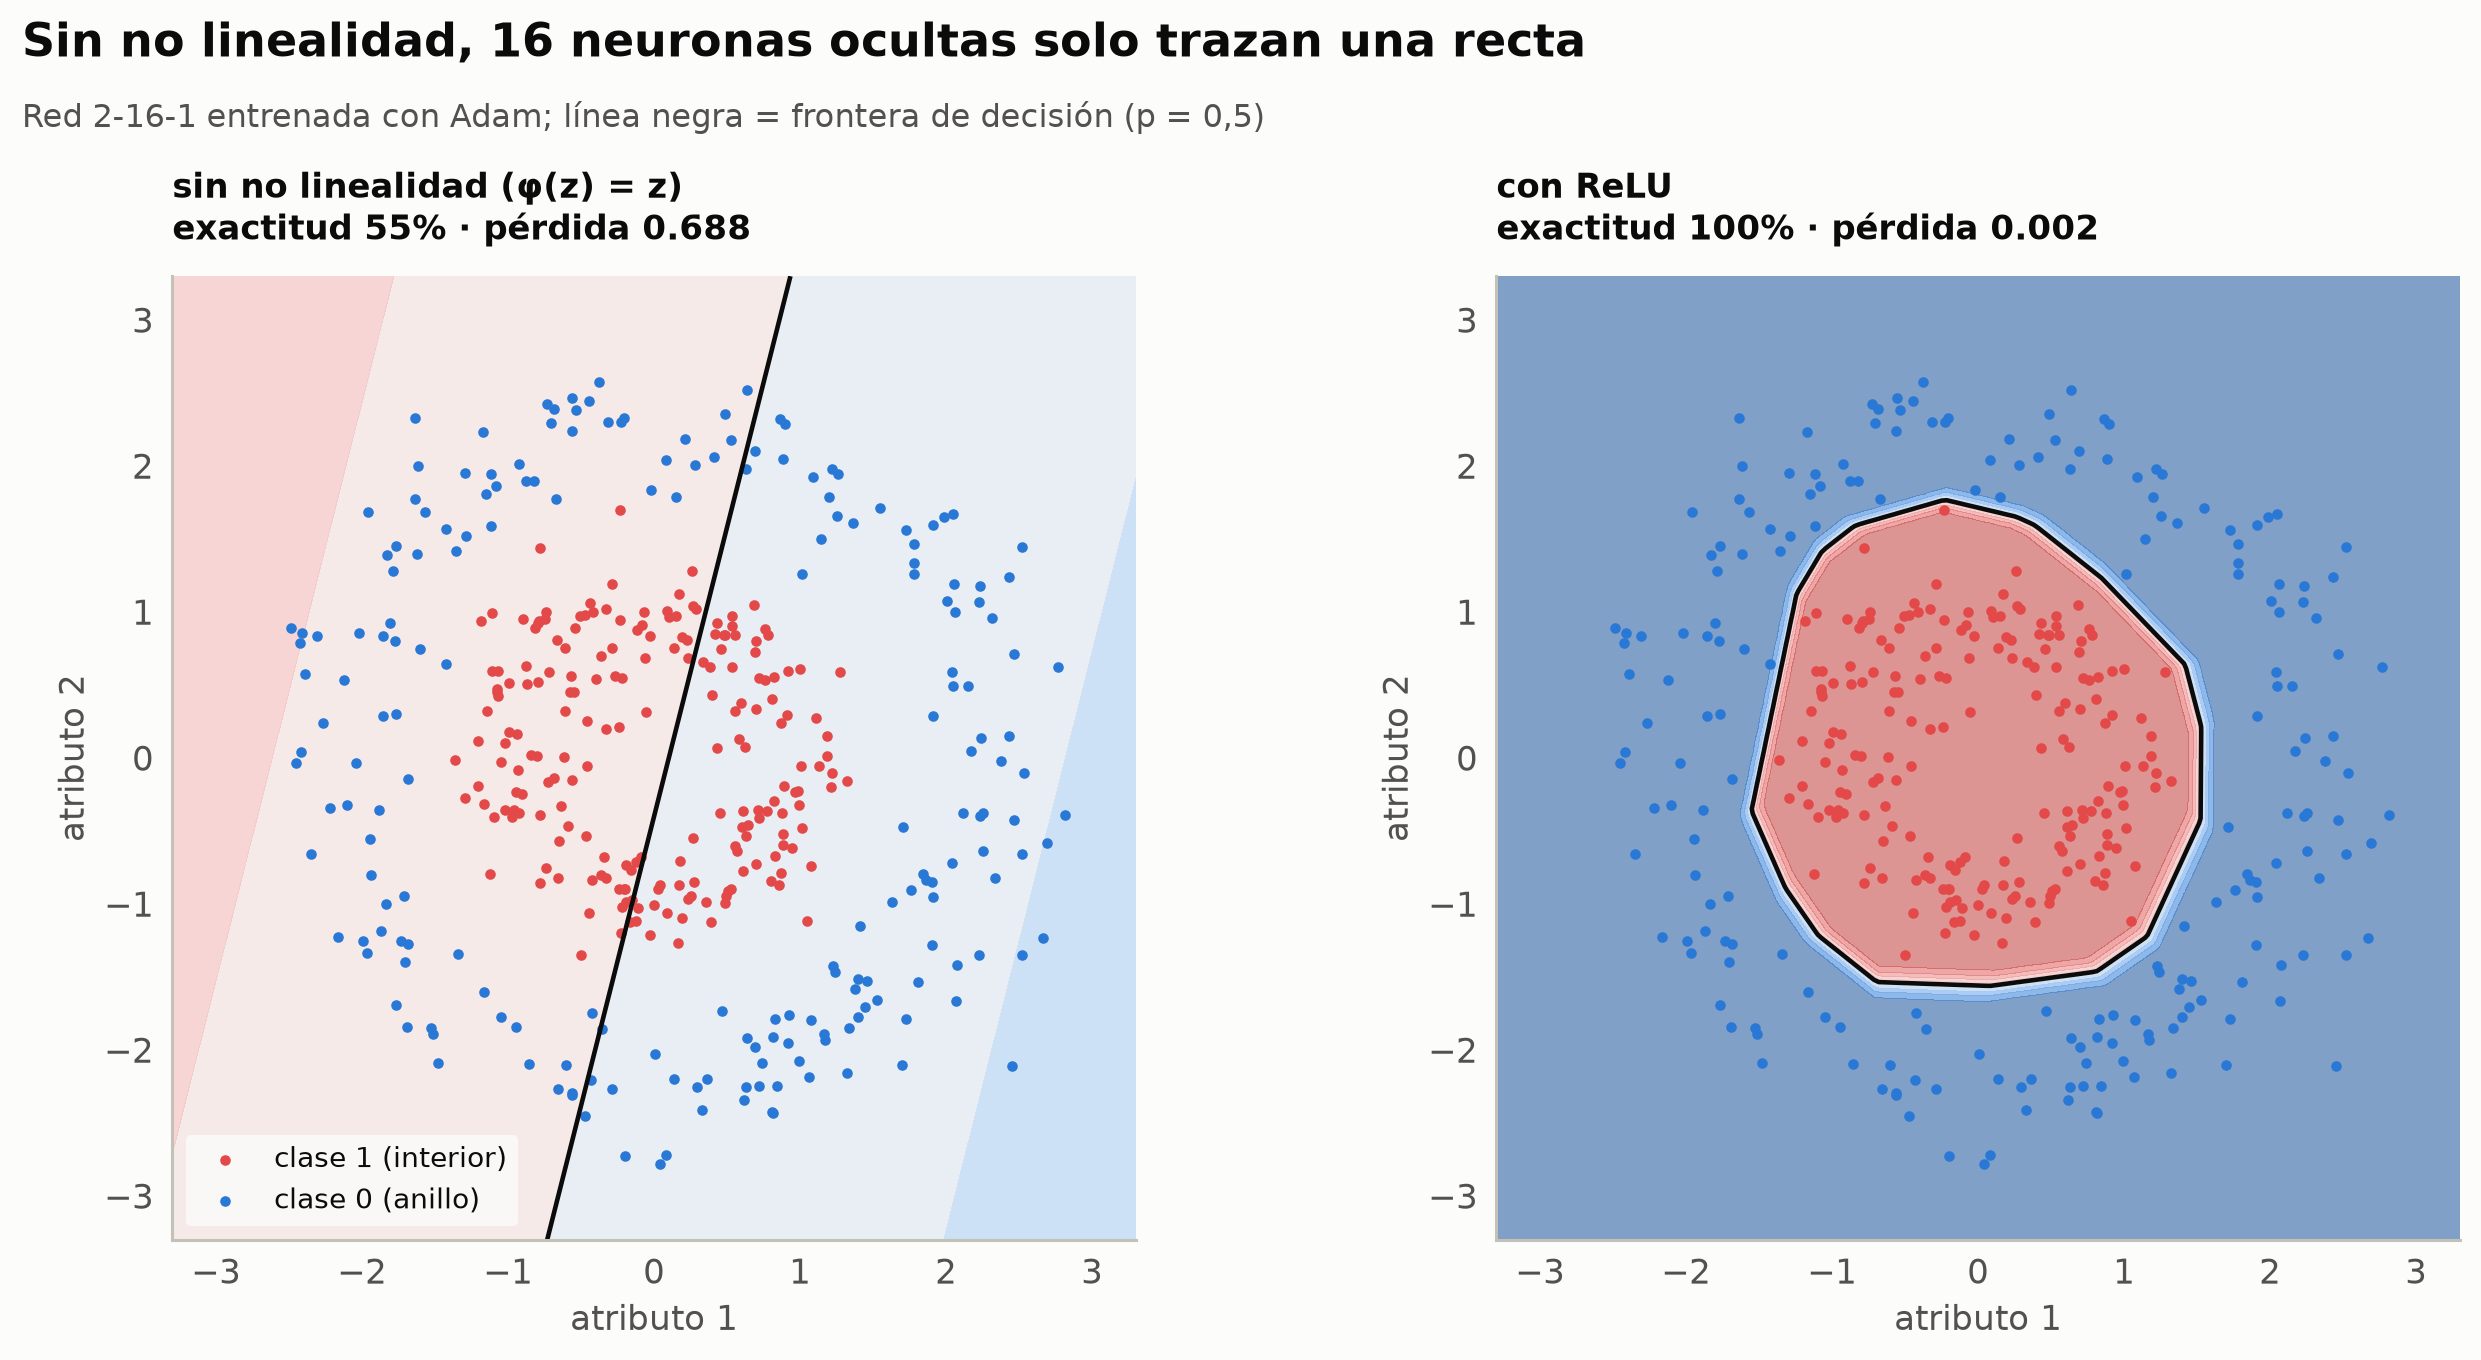

In [3]:
# Dos clases en anillo: ninguna recta las separa
g = np.random.default_rng(1)
n = 400
r = np.r_[g.normal(1.0, 0.25, n // 2), g.normal(2.3, 0.3, n // 2)]
ang = g.uniform(0, 2 * np.pi, n)
Xr = np.c_[r * np.cos(ang), r * np.sin(ang)].astype(np.float32)
yr = np.r_[np.ones(n // 2), np.zeros(n // 2)].astype(np.float32)

def fit_mlp(act, seed=0, epochs=600):
    torch.manual_seed(seed)
    net = nn.Sequential(nn.Linear(2, 16), act, nn.Linear(16, 1))
    opt = torch.optim.Adam(net.parameters(), lr=0.03)
    X_, y_ = torch.tensor(Xr), torch.tensor(yr)
    for _ in range(epochs):
        opt.zero_grad(); l = nn.functional.binary_cross_entropy_with_logits(net(X_).squeeze(1), y_); l.backward(); opt.step()
    return net, l.item()

nets = {"sin no linealidad (φ(z) = z)": fit_mlp(nn.Identity()), "con ReLU": fit_mlp(nn.ReLU())}
gx, gy = np.meshgrid(np.linspace(-3.3, 3.3, 200), np.linspace(-3.3, 3.3, 200))
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for ax, (name, (net, l)) in zip(axes, nets.items()):
    with torch.no_grad():
        P = torch.sigmoid(net(torch.tensor(np.c_[gx.ravel(), gy.ravel()], dtype=torch.float32))).numpy().reshape(gx.shape)
    ax.contourf(gx, gy, P, levels=np.linspace(0, 1, 11), cmap=ec.CMAP_DIV, alpha=0.55)
    ax.contour(gx, gy, P, levels=[0.5], colors=ec.INK, linewidths=1.5)
    ax.scatter(*Xr[yr == 1].T, s=12, color=ec.RED, label="clase 1 (interior)")
    ax.scatter(*Xr[yr == 0].T, s=12, color=ec.BLUE, label="clase 0 (anillo)")
    with torch.no_grad():
        acc = ((net(torch.tensor(Xr)).squeeze(1) > 0).numpy() == yr).mean()
    ax.set_title(f"{name}\nexactitud {acc:.0%} · pérdida {l:.3f}", fontsize=11, loc="left")
    ax.set_aspect("equal"); ax.set_xlabel("atributo 1"); ax.set_ylabel("atributo 2"); ax.grid(False)
axes[0].legend(loc="lower left", frameon=True, fontsize=9)
ec.fig_title(fig, "Sin no linealidad, 16 neuronas ocultas solo trazan una recta",
             "Red 2-16-1 entrenada con Adam; línea negra = frontera de decisión (p = 0,5)")
plt.show()

> 🔎 **Qué observamos.** Con $\varphi(z)=z$ la red, pese a sus 16 neuronas ocultas, sólo encuentra una frontera **recta**
> y acierta poco más que al azar. Con ReLU, la frontera se curva y rodea la clase interior. La profundidad sólo sirve si
> entre capa y capa hay una no linealidad.

> ✅ **Compruebe su comprensión.** En la red 3-4-1, ¿cuántos parámetros hay? *(Capa oculta: $4\times3$ pesos + 4 sesgos
> = 16; salida: 4 pesos + 1 sesgo = 5; total 21.)*

## 3. Retropropagación: la regla de la cadena con buen orden

Entrenar una red es, otra vez, **minimizar una pérdida por descenso de gradiente**, como hicimos con la regresión
logística en la lección 17.1. El problema es calcular el gradiente respecto de **millones** de pesos de forma eficiente.
Rumelhart, Hinton y Williams (1986) popularizaron la solución: la **retropropagación** (*backpropagation*), que no es
más que la regla de la cadena aplicada **de atrás hacia adelante**.

Piense en una cadena de montaje de cuatro estaciones donde el producto final sale defectuoso. Para saber cuánto
contribuyó cada estación, no desmonta la fábrica cuatro veces: empieza por la última estación, mide cuánto error pasó
por ella y le "devuelve" a la anterior su parte proporcional. Cada estación sólo necesita saber cuánto error le llegó y
cuánto amplifica ella misma.

**Derivación para nuestra red.** Con salida sigmoide y entropía cruzada, ya sabemos por la lección 17.1 que en la última
capa $\partial\ell/\partial z^{(2)}=\hat y-y\equiv\delta^{(2)}$, y por tanto
$\partial\ell/\partial\mathbf{w}^{(2)}=\delta^{(2)}\mathbf{a}^{(1)}$. Para bajar a la capa oculta:

$$
\frac{\partial\ell}{\partial z^{(1)}_j}=\frac{\partial\ell}{\partial z^{(2)}}\cdot\frac{\partial z^{(2)}}{\partial a^{(1)}_j}\cdot\frac{\partial a^{(1)}_j}{\partial z^{(1)}_j}=\delta^{(2)}\,w^{(2)}_j\,\varphi'\big(z^{(1)}_j\big)\equiv\delta^{(1)}_j,
\qquad \frac{\partial\ell}{\partial W^{(1)}_{jk}}=\delta^{(1)}_j\,x_k .
$$

El patrón se repite en cualquier número de capas (**teorema de la retropropagación** del libro):

$$
\boldsymbol\delta^{(l)} = \Big(W^{(l+1)\top}\boldsymbol\delta^{(l+1)}\Big)\odot\varphi'\big(\mathbf{z}^{(l)}\big),
\qquad
\frac{\partial\ell}{\partial W^{(l)}} = \boldsymbol\delta^{(l)}\,\mathbf{a}^{(l-1)\top},\qquad
\frac{\partial\ell}{\partial \mathbf{b}^{(l)}} = \boldsymbol\delta^{(l)} .
$$

| Símbolo | Significado |
|---|---|
| $\boldsymbol\delta^{(l)}=\partial\ell/\partial\mathbf{z}^{(l)}$ | sensibilidad de la pérdida a las preactivaciones de la capa $l$ ("error que llega") |
| $\odot$ | producto elemento a elemento (de Hadamard) |
| $\varphi'$ | derivada de la activación; para ReLU vale 1 si $z>0$ y 0 si $z<0$ |

**A mano, con la red del apartado 2.3.** $\delta^{(2)}=\hat y-y=0{,}6792-1=-0{,}3208$. Entonces
$\partial\ell/\partial\mathbf{w}^{(2)}=\delta^{(2)}\mathbf{a}^{(1)}=(-0{,}4812;\ 0;\ -0{,}1604;\ -0{,}1604)$. Bajando:
$\varphi'(\mathbf{z}^{(1)})=(1,0,1,1)$ (la segunda neurona estaba apagada), así que
$\boldsymbol\delta^{(1)}=-0{,}3208\cdot(1,-1,-1,0{,}5)\odot(1,0,1,1)=(-0{,}3208;\ 0;\ 0{,}3208;\ -0{,}1604)$. Observe que
la neurona apagada recibe **error cero**: sus pesos de entrada no cambian en este paso.

Comprobémoslo de **tres maneras**: con las ecuaciones, con la diferenciación automática de PyTorch y con la vía
ingenua de **diferencias finitas** (perturbar cada peso y medir el cambio de la pérdida).

In [4]:
# (1) Retropropagación con las ecuaciones del libro
d2 = y_hat - y
g_w2, g_b2 = d2 * a1, d2
d1 = (w2 * d2) * (z1 > 0)                 # δ(1) = (W(2)ᵀ δ(2)) ⊙ φ'(z(1))
g_W1, g_b1 = np.outer(d1, x), d1
print("δ(2) =", round(d2, 4), "| ∂ℓ/∂w(2) =", g_w2.round(4), "| δ(1) =", d1.round(4))

# (2) Diferenciación automática de PyTorch (la misma red)
tW1 = torch.tensor(W1, requires_grad=True); tb1 = torch.tensor(b1, requires_grad=True)
tw2 = torch.tensor(w2, requires_grad=True); tb2 = torch.tensor(b2, requires_grad=True)
tz2 = tw2 @ torch.relu(tW1 @ torch.tensor(x) + tb1) + tb2
nn.functional.binary_cross_entropy_with_logits(tz2, torch.tensor(y, dtype=torch.float64)).backward()

# (3) Diferencias finitas centradas: 2 evaluaciones de la red POR CADA parámetro
def loss_fn(W1_, b1_, w2_, b2_):
    p = sigmoid(w2_ @ relu(W1_ @ x + b1_) + b2_)
    return -np.log(p)
eps, fd = 1e-6, np.zeros_like(W1)
for j in range(4):
    for k in range(3):
        Wp, Wm = W1.copy(), W1.copy(); Wp[j, k] += eps; Wm[j, k] -= eps
        fd[j, k] = (loss_fn(Wp, b1, w2, b2) - loss_fn(Wm, b1, w2, b2)) / (2 * eps)

print("\n∂ℓ/∂W(1) por retropropagación:\n", g_W1.round(4))
print("máx |ecuaciones − PyTorch|        =", f"{np.abs(g_W1 - tW1.grad.numpy()).max():.1e}")
print("máx |ecuaciones − dif. finitas|   =", f"{np.abs(g_W1 - fd).max():.1e}")

δ(2) = -0.3208 | ∂ℓ/∂w(2) = [-0.4812 -0.     -0.1604 -0.1604] | δ(1) = [-0.3208  0.      0.3208 -0.1604]

∂ℓ/∂W(1) por retropropagación:
 [[-0.3208 -0.     -0.3208]
 [ 0.      0.      0.    ]
 [ 0.3208  0.      0.3208]
 [-0.1604 -0.     -0.1604]]
máx |ecuaciones − PyTorch|        = 0.0e+00
máx |ecuaciones − dif. finitas|   = 4.5e-11


> 🔎 **Qué observamos.** Las tres vías coinciden hasta la precisión numérica. La diferencia está en el **coste**: las
> diferencias finitas necesitan dos evaluaciones de la red **por cada peso**; la retropropagación obtiene **todas** las
> derivadas con un pase hacia adelante y uno hacia atrás. Midamos esa diferencia con una red de tamaño creciente.

In [5]:
# Coste: retropropagación (1 pase adelante + 1 atrás) frente a diferencias finitas (2 pases por parámetro)
rows = []
for width in (8, 16, 32, 64):
    torch.manual_seed(0)
    net = nn.Sequential(nn.Linear(40, width), nn.ReLU(), nn.Linear(width, width), nn.ReLU(), nn.Linear(width, 1))
    xb = torch.randn(32, 40); yb = (torch.rand(32) > 0.5).float()
    P = sum(p.numel() for p in net.parameters())
    lossf_ = lambda: nn.functional.binary_cross_entropy_with_logits(net(xb).squeeze(1), yb)
    t0 = time.perf_counter()
    for _ in range(20):
        net.zero_grad(); lossf_().backward()
    t_bp = (time.perf_counter() - t0) / 20
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(20):
            lossf_()
    t_fwd = (time.perf_counter() - t0) / 20
    rows.append(dict(ancho=width, parametros=P, t_backprop_ms=1e3 * t_bp, t_dif_finitas_ms=1e3 * 2 * P * t_fwd))
cost = pd.DataFrame(rows)
cost["veces_mas_lento"] = cost["t_dif_finitas_ms"] / cost["t_backprop_ms"]
cost.round(2)

,ancho,parametros,t_backprop_ms,t_dif_finitas_ms,veces_mas_lento
0,8,409,0.10,22.59,232.23
1,16,945,0.09,58.22,631.14
2,32,2401,0.09,143.30,1625.13
3,64,6849,0.09,462.11,4977.93


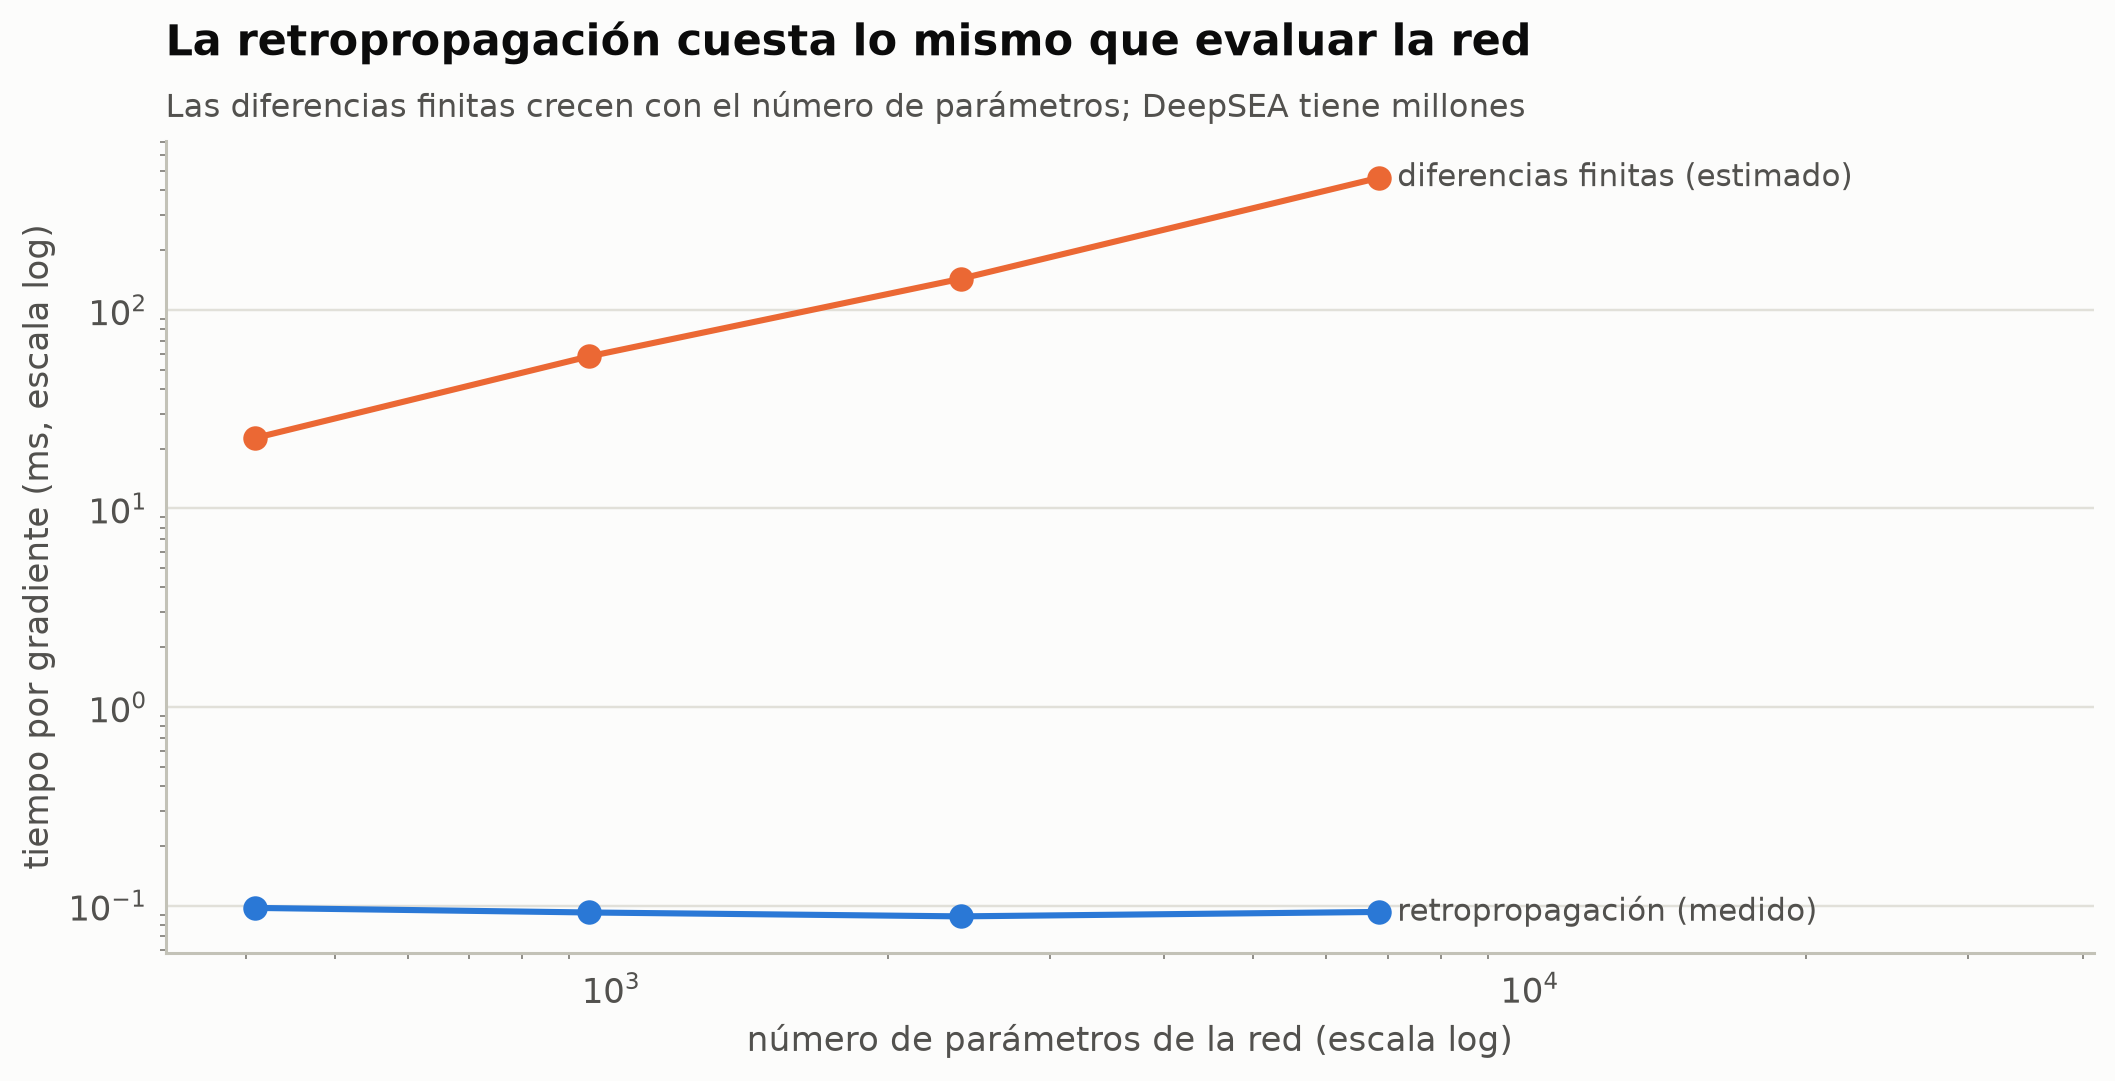

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(cost["parametros"], cost["t_dif_finitas_ms"], "o-", color=ec.ORANGE, lw=2)
ax.plot(cost["parametros"], cost["t_backprop_ms"], "o-", color=ec.BLUE, lw=2)
ec.label_end(ax, cost["parametros"].iloc[-1], cost["t_dif_finitas_ms"].iloc[-1], "diferencias finitas (estimado)")
ec.label_end(ax, cost["parametros"].iloc[-1], cost["t_backprop_ms"].iloc[-1], "retropropagación (medido)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("número de parámetros de la red (escala log)"); ax.set_ylabel("tiempo por gradiente (ms, escala log)")
ax.set_xlim(cost["parametros"].min() * 0.8, cost["parametros"].max() * 6)
ec.title(ax, "La retropropagación cuesta lo mismo que evaluar la red",
         "Las diferencias finitas crecen con el número de parámetros; DeepSEA tiene millones")
plt.show()

> 🔎 **Qué observamos.** El coste de la retropropagación apenas cambia con el tamaño de estas redes, mientras que el de
> las diferencias finitas crece en proporción al número de parámetros: con unos miles de pesos ya es cientos o miles de
> veces más lento. Por eso bibliotecas como **PyTorch**, JAX o TensorFlow implementan la retropropagación de forma
> automática (**diferenciación automática**) para cualquier composición de operaciones diferenciables. En la práctica
> el gradiente se estima con pequeños **lotes** (*minibatches*) de datos: es el **descenso por gradiente estocástico**.

> ✅ **Compruebe su comprensión.** Si en el ejemplo la segunda neurona oculta hubiera tenido $z^{(1)}_2=+0{,}5$ en vez de
> $-0{,}5$, ¿cuánto valdría $\delta^{(1)}_2$? *(Ahora $\varphi'=1$, así que $\delta^{(1)}_2=\delta^{(2)}w^{(2)}_2=-0{,}3208\times(-1)=0{,}3208$.)*

## 4. Convolución sobre ADN: un filtro es una PWM

### 4.1 Por qué no una red densa

Una red densa sobre la matriz *one-hot* de una secuencia de 1 000 pb necesitaría pesos **distintos** para "el motivo en
la posición 17" y "el motivo en la posición 18": tendría que aprender el mismo motivo mil veces. Las **redes
convolucionales** (CNN) imponen, en cambio, que **el mismo detector se aplique en todas las posiciones** (la plantilla
del corrector). Una capa convolucional unidimensional con $F$ filtros de ancho $w$ calcula

$$
h_{k,i} = \mathrm{ReLU}\!\left(b_k + \sum_{j=1}^{w}\sum_{c\in\{\texttt{A,C,G,T}\}} W_{k,c,j}\,X_{c,\,i+j-1}\right),
\qquad k=1,\dots,F,\quad i=1,\dots,L-w+1,
$$

| Símbolo | Significado |
|---|---|
| $X_{c,i}$ | matriz *one-hot* $4\times L$: vale 1 si la base de la posición $i$ es $c$ y 0 si no |
| $W_{k,c,j}$ | peso del filtro $k$ para la base $c$ en la posición $j$ de la ventana ($4\times w$ números por filtro) |
| $b_k$ | sesgo del filtro $k$; actúa como **umbral** de detección |
| $h_{k,i}$ | activación del filtro $k$ cuando la ventana empieza en la posición $i$ |
| $F,\ w$ | número de filtros y ancho de cada uno (en pb) |

### 4.2 El teorema: un filtro es una matriz de pesos posicionales

Como $X$ es *one-hot*, en la suma interior **sólo sobrevive el término de la base observada** (las otras tres se
multiplican por cero). La ecuación se simplifica de un modo revelador:

$$
h_{k,i} = \mathrm{ReLU}\!\left(b_k + \sum_{j=1}^{w} W_{k,\,x_{i+j-1},\,j}\right).
$$

Si $W_{k,c,j}=\log\big(p_{j,c}/q_c\big)$ es la matriz de log-probabilidades de una PWM y $b_k=-\tau$, **la activación es
exactamente la puntuación de la PWM** en la ventana $i$, recortada por debajo del umbral $\tau$.

| Símbolo | Significado |
|---|---|
| $x_{i+j-1}$ | base observada en la posición $j$ de la ventana |
| $p_{j,c},\ q_c$ | frecuencia de la base $c$ en la posición $j$ del motivo y en el fondo (lección 4.2) |
| $\tau$ | umbral de puntuación por debajo del cual el filtro "no ve" nada |

Este resultado explica el éxito de las CNN con ADN regulatorio: **la primera capa es un banco de PWM que se aprenden
solas**, sin alinear sitios conocidos. Tras la convolución, el ***max-pooling*** global resume cada filtro en un número:

$$
m_k = \max_{i}\; h_{k,i},
$$

| Símbolo | Significado |
|---|---|
| $m_k$ | respuesta máxima del filtro $k$ en toda la secuencia: "¿aparece el motivo $k$ en algún lugar?" |

lo que hace la predicción **invariante a la posición** del motivo. Las capas siguientes combinan esas detecciones
("motivo 1 **y** motivo 3 a menos de 20 pb") y aprenden la sintaxis regulatoria.

### 4.3 Ejemplo del libro: «Un filtro a mano»

Consideremos un filtro de ancho $w=3$ diseñado para `TGA` (la mitad de un sitio AP-1): pesos $+2$ para la base de
consenso en cada posición y $-1$ para las demás, con sesgo $b=-4$.

* Sobre la ventana `TGA`: $\mathrm{ReLU}(-4+2+2+2)=\mathrm{ReLU}(2)=2$.
* Sobre `TCA` (una discrepancia en el centro): $\mathrm{ReLU}(-4+2-1+2)=\mathrm{ReLU}(-1)=0$.
* El sesgo actúa como **umbral**: este filtro sólo "ve" coincidencias perfectas. Con $b=-2$ toleraría una
  discrepancia, pues `TCA` daría $\mathrm{ReLU}(1)=1$.

> 🤔 **Antes de ejecutar, prediga.** Con $b=-2$, ¿qué activación produce la ventana `ACC` (ninguna base coincide)?
> *(Respuesta: $\mathrm{ReLU}(-2-1-1-1)=0$.)*

Programemos el filtro **dentro de una capa `nn.Conv1d` de PyTorch**, poniéndole los pesos a mano, y apliquémoslo a la
secuencia de la figura del libro, `CGTGACTCATGCAAGT`.

In [7]:
# El filtro "TGA" del libro como capa convolucional de PyTorch (1 filtro, ancho 3, 4 canales A,C,G,T)
motif = "TGA"
W_hand = np.full((4, 3), -1.0)
for j, b in enumerate(motif):
    W_hand[BASES.index(b), j] = 2.0

conv = nn.Conv1d(in_channels=4, out_channels=1, kernel_size=3)
with torch.no_grad():
    conv.weight[:] = torch.tensor(W_hand).unsqueeze(0)      # forma (F, 4, w) = (1, 4, 3)

def filter_track(seq, bias):
    with torch.no_grad():
        conv.bias[:] = bias
        return torch.relu(conv(torch.tensor(onehot(seq)).unsqueeze(0)))[0, 0].numpy()

for window in ("TGA", "TCA", "ACC"):
    print(f"ventana {window}:  b = -4 → h = {filter_track(window, -4)[0]:.0f}   |   b = -2 → h = {filter_track(window, -2)[0]:.0f}")

seq_fig = "CGTGACTCATGCAAGT"
h4, h2 = filter_track(seq_fig, -4), filter_track(seq_fig, -2)
print(f"\nSecuencia {seq_fig} ({len(seq_fig)} pb) → {len(h4)} ventanas (L − w + 1)")
print(pd.DataFrame({"ventana": [seq_fig[i:i + 3] for i in range(len(h4))], "h (b=-4)": h4, "h (b=-2)": h2},
                   index=pd.RangeIndex(1, len(h4) + 1, name="i")).T.to_string())
print(f"\nmax-pooling: m = {h4.max():.0f} con b = -4 (sólo TGA) · m = {h2.max():.0f} con b = -2")

ventana TGA:  b = -4 → h = 2   |   b = -2 → h = 4
ventana TCA:  b = -4 → h = 0   |   b = -2 → h = 1
ventana ACC:  b = -4 → h = 0   |   b = -2 → h = 0

Secuencia CGTGACTCATGCAAGT (16 pb) → 14 ventanas (L − w + 1)
i          1    2    3    4    5    6    7    8    9    10   11   12   13   14
ventana   CGT  GTG  TGA  GAC  ACT  CTC  TCA  CAT  ATG  TGC  GCA  CAA  AAG  AGT
h (b=-4)  0.0  0.0  2.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
h (b=-2)  0.0  0.0  4.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0

max-pooling: m = 2 con b = -4 (sólo TGA) · m = 4 con b = -2


> 🔎 **Qué observamos.** Con $b=-4$ el filtro sólo se enciende en $i=3$ (`TGA`). Con $b=-2$ también responde, con
> activación 1, a las ventanas a **una discrepancia**: `TCA` en $i=7$ (la del libro) y también `TGC` en $i=10$. El sesgo es el control de **sensibilidad frente a especificidad** del detector: el mismo
> compromiso que el umbral de puntuación de una PWM en la lección 4.2.

La animación siguiente muestra la plantilla deslizándose por la secuencia: arriba la matriz *one-hot* con la ventana
actual, abajo las dos pistas de activación que se van llenando.

![El filtro TGA (w = 3) se desliza por CGTGACTCATGCAAGT: con sesgo b = −4 sólo se enciende en la coincidencia perfecta; con b = −2 también en las ventanas a una discrepancia (TCA, TGC)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-17-machine-learning/17.2_filtro_desliza.gif)

*El filtro TGA (w = 3) se desliza por CGTGACTCATGCAAGT: con sesgo b = −4 sólo se enciende en la coincidencia perfecta; con b = −2 también en las ventanas a una discrepancia (TCA, TGC)*

In [8]:
Xf = onehot(seq_fig)
nwin = len(h4)
fig = plt.figure(figsize=(11, 6.6))
fig.set_layout_engine("none")
gs = fig.add_gridspec(2, 1, height_ratios=[1.25, 1], hspace=0.55, left=0.08, right=0.97, top=0.82, bottom=0.1)
ax_x, ax_h = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

def update(t):
    ax_x.clear(); ax_h.clear()
    i = min(t, nwin - 1)                     # ventana actual (0-based); cuadros finales = max-pooling
    for c in range(4):
        for p in range(len(seq_fig)):
            on = Xf[c, p] == 1
            ax_x.add_patch(Rectangle((p, 3 - c), 0.94, 0.94, color=ec.NUC_COLORS[BASES[c]] if on else "#f3f2ee"))
            if on:
                ax_x.text(p + 0.47, 3 - c + 0.47, "1", ha="center", va="center", color="white", fontsize=9, weight="bold")
        ax_x.text(-0.3, 3 - c + 0.47, BASES[c], ha="right", va="center", fontsize=12, weight="bold",
                  color=ec.NUC_COLORS[BASES[c]])
    for p, b in enumerate(seq_fig):
        ax_x.text(p + 0.47, 4.35, b, ha="center", va="center", fontsize=13, weight="bold", family="monospace",
                  color=ec.NUC_COLORS[b])
    ax_x.add_patch(Rectangle((i - 0.08, -0.1), 3.1, 4.95, fill=False, ec=ec.ORANGE, lw=3))
    win = seq_fig[i:i + 3]
    terms = [2 if win[j] == motif[j] else -1 for j in range(3)]
    s = " ".join(f"{v:+d}" for v in terms)
    ax_x.set_xlim(-0.8, len(seq_fig) + 0.2); ax_x.set_ylim(-0.3, 5.0); ax_x.axis("off")
    ax_x.set_title(f"Ventana i = {i + 1}: {win}   →   b=−4: ReLU(−4 {s}) = {max(0, -4 + sum(terms))}"
                   f"    ·    b=−2: ReLU(−2 {s}) = {max(0, -2 + sum(terms))}", fontsize=11.5, loc="left")
    xs = np.arange(1, nwin + 1)
    shown = xs <= i + 1
    ax_h.bar(xs[shown] - 0.18, h4[shown], width=0.34, color=ec.BLUE, label="h (b = −4)")
    ax_h.bar(xs[shown] + 0.18, h2[shown], width=0.34, color=ec.ORANGE, label="h (b = −2)")
    ax_h.set_xlim(0.3, nwin + 0.7); ax_h.set_ylim(0, 4.9); ax_h.set_xticks(xs)
    ax_h.set_xlabel("posición de inicio de la ventana, i"); ax_h.set_ylabel("activación $h_i$")
    ax_h.legend(loc="upper right", frameon=False, ncol=2)
    if t >= nwin:
        ax_h.set_title(f"Max-pooling: m = max_i h_i = {h4.max():.0f} (b = −4) y {h2.max():.0f} (b = −2) "
                       "→ «el motivo aparece en algún lugar»", fontsize=11.5, loc="left", color=ec.INK)
    else:
        ax_h.set_title("Pista de activaciones del filtro", fontsize=11.5, loc="left")
    return ()

fig.text(0.01, 0.955, "Un filtro convolucional es una plantilla que se desliza", fontsize=15, weight="bold")
fig.text(0.01, 0.925, "Filtro TGA del libro: +2 en la base de consenso, −1 en las demás; el sesgo decide cuántas "
         "discrepancias tolera", fontsize=10.5, color=ec.INK_2)
ec.animate(fig, update, frames=nwin + 4, interval=600, name="17.2_filtro_desliza")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Cada cuadro es una ventana $i$: sólo sobrevive el peso de la base presente en cada columna
> (las casillas coloreadas), exactamente como dice el teorema. La pista azul ($b=-4$) tiene un único pico; la naranja
> ($b=-2$), tres. El *max-pooling* final descarta **dónde** apareció el motivo y conserva **si** apareció.

### 4.4 ¿Cuántos parámetros tiene la red que entrenaremos?

La red del libro tiene una convolución con $F=8$ filtros de $4\times11$ pesos más un sesgo cada uno:
$8\times(44+1)=360$. La capa de salida combina los 8 máximos con 8 pesos y un sesgo: 9. **En total, 369 parámetros**;
DeepSEA o Basset tienen **millones**. La definimos en PyTorch tal como la escribe el libro (identificadores en inglés).

In [9]:
class CNN(nn.Module):
    """CNN del libro: Conv1d(4 → F, ancho w) → ReLU → max-pooling global → Linear(F → 1) (logit)."""
    def __init__(self, nf=8, k=11):
        super().__init__()
        self.conv = nn.Conv1d(4, nf, k)          # canales A, C, G, T
        self.fc = nn.Linear(nf, 1)

    def forward(self, x):                        # x: (lote, 4, L)
        h = torch.relu(self.conv(x))             # (lote, F, L − w + 1)
        m = h.max(dim=2).values                  # max-pooling global: m_k
        return self.fc(m).squeeze(1)             # logit

demo = CNN()
for name, p in demo.named_parameters():
    print(f"{name:12s} forma {tuple(p.shape)!s:14s} → {p.numel():4d} parámetros")
print("total:", sum(p.numel() for p in demo.parameters()), "parámetros")

conv.weight  forma (8, 4, 11)     →  352 parámetros
conv.bias    forma (8,)           →    8 parámetros
fc.weight    forma (1, 8)         →    8 parámetros
fc.bias      forma (1,)           →    1 parámetros
total: 369 parámetros


## 5. Un experimento: una CNN aprende un motivo

### 5.1 Los datos simulados del libro

Para ver el teorema en acción, el libro simula **6 000 secuencias aleatorias de 100 pb**. En la mitad, elegidas al azar,
inserta en una posición aleatoria un sitio muestreado de una PWM de tipo **AP-1** (el factor de transcripción
Fos/Jun, que responde a estrés y factores de crecimiento): consenso `TGASTCA`, donde `S` es `C` o `G`, con probabilidad
0,91 para la base de consenso en las posiciones no degeneradas (0,03 para cada una de las otras) y 0,47/0,47 para C/G
en la posición degenerada. Se entrena con **4 000** secuencias, se usan **1 000** para validación y se reservan
**1 000** para la prueba final.

**Mismas cifras que el libro.** El script del libro usa un único generador `np.random.default_rng(17)` para todo el
capítulo, y cuando llega a esta sección el generador ya ha sido "gastado" por las simulaciones de la sección 17.1. Para
reproducir exactamente sus secuencias guardamos el **estado interno** del generador en ese punto
(`data/172_rng_state_cap17.json`, un JSON de 200 bytes) y lo restauramos aquí. Es un truco de reproducibilidad útil en
cualquier proyecto: el estado de un generador PCG64 se puede serializar y restaurar.

In [10]:
# Restaurar el estado del generador del libro justo antes de simular (ver texto)
rng = np.random.default_rng()
with open(data_file("172_rng_state_cap17.json")) as fh:
    rng.bit_generator.state = json.load(fh)

PFM = np.array([  # motivo tipo AP-1 (TGA[CG]TCA): filas = posiciones, columnas = A, C, G, T
    [0.03, 0.03, 0.03, 0.91], [0.03, 0.03, 0.91, 0.03], [0.91, 0.03, 0.03, 0.03],
    [0.03, 0.47, 0.47, 0.03], [0.03, 0.03, 0.03, 0.91], [0.03, 0.91, 0.03, 0.03],
    [0.91, 0.03, 0.03, 0.03]])
Lc, Nc = 100, 6000

def sim_seq(pos):
    """Secuencia uniforme de 100 pb; si pos, se planta un sitio muestreado de la PWM en una posición al azar."""
    s = rng.choice(list(BASES), Lc)
    at = -1
    if pos:
        at = rng.integers(0, Lc - len(PFM))
        for j, p in enumerate(PFM):
            s[at + j] = rng.choice(list(BASES), p=p)
    return "".join(s), at

t0 = time.perf_counter()
yc = rng.integers(0, 2, Nc)
sims = [sim_seq(v) for v in yc]
Xc = torch.tensor(np.stack([onehot(s) for s, _ in sims]))
Yc = torch.tensor(yc, dtype=torch.float32)
itr, iva, ite = np.arange(0, 4000), np.arange(4000, 5000), np.arange(5000, 6000)
print(f"{Nc} secuencias simuladas en {time.perf_counter() - t0:.1f} s · positivas: {yc.sum()} · tensor X: {tuple(Xc.shape)}")
print("Ejemplo positivo:", sims[int(np.argmax(yc))][0], "· sitio en", sims[int(np.argmax(yc))][1] + 1)

6000 secuencias simuladas en 0.3 s · positivas: 2944 · tensor X: (6000, 4, 100)
Ejemplo positivo: GTGGACGCATCCAGACGGGAGTGGTATTTAATGACTGGCGACTAGGAGTGACTCACGGCCGAGTATTCGGAATGAGACAACTAAGTATCGAATTGAGTTC · sitio en 49


> 🤔 **Antes de entrenar, prediga.** ¿Qué exactitud cree que puede alcanzar **cualquier** clasificador en este
> problema? Piense en dos hechos: (1) la probabilidad de que un sitio plantado salga **idéntico** al consenso es
> $0{,}91^6\times0{,}94\approx0{,}53$; (2) en 100 pb aleatorios hay 94 ventanas de 7 pb, y cada una tiene cierta
> probabilidad de estar a **una** discrepancia del consenso. Calculémoslo.

In [11]:
# ¿Cuán separables son las clases? Discrepancias con el consenso TGA[CG]TCA
def min_mismatch(s):
    best = 7
    for i in range(len(s) - 6):
        w = s[i:i + 7]
        mm = sum(w[j] != c for j, c in enumerate("TGA-TCA") if c != "-") + (w[3] not in "CG")
        best = min(best, mm)
    return best

mm = np.array([min_mismatch(s) for s, _ in sims])
tab = pd.crosstab(pd.Series(np.where(yc == 1, "positiva (sitio plantado)", "negativa"), name="clase"),
                  pd.Series(np.minimum(mm, 3), name="mín. discrepancias con TGASTCA (3 = ≥3)"), normalize="index")
print(f"P(sitio plantado idéntico al consenso) teórica = {0.91**6 * 0.94:.3f}")
tab.round(3)

P(sitio plantado idéntico al consenso) teórica = 0.534


mín. discrepancias con TGASTCA (3 = ≥3),0,1,2,3
clase,,,,
negativa,0.010,0.193,0.671,0.126
positiva (sitio plantado),0.542,0.361,0.094,0.002


> 🔎 **Qué observamos.** Alrededor de la mitad de los positivos tienen su mejor ventana a una o más discrepancias del
> consenso, y una fracción apreciable de los negativos contiene **por azar** una palabra a una sola discrepancia. En esa
> zona compartida ningún clasificador puede acertar siempre: hay un **error de Bayes** distinto de cero, que no se debe a
> la red sino a los datos. Téngalo presente cuando veamos una exactitud "modesta".

### 5.2 Entrenamiento

El bucle del libro es:

```python
red = CNNMotivo()
opt = torch.optim.Adam(red.parameters(), lr=3e-3)
perdida = nn.BCEWithLogitsLoss()            # entropía cruzada
for epoca in range(40):
    for xb, yb in cargador:                 # lotes de 64 secuencias
        opt.zero_grad()
        perdida(red(xb), yb).backward()     # retropropagación
        opt.step()
```

Para obtener **exactamente** las mismas cifras, el `cargador` se implementa como en el script del libro: en cada época
se baraja el conjunto de entrenamiento con `rng.permutation` (el mismo generador restaurado) y se recorre en lotes de
64. Además guardamos una copia de los pesos en varios momentos (antes de entrenar, a mitad de las épocas 2 a 5 y al
final de cada época) para la animación del apartado 6. La semilla `torch.manual_seed(17)` va justo antes de crear la red,
porque fija la **inicialización** de los pesos.

In [12]:
torch.manual_seed(17)
net = CNN()
opt = torch.optim.Adam(net.parameters(), lr=3e-3)
lossf = nn.BCEWithLogitsLoss()
hist, snaps = [], [("antes de entrenar", 0, copy.deepcopy(net.state_dict()))]
early = {16, 32, 48}                                      # lotes intermedios guardados en las épocas 2-5
t0 = time.perf_counter()
for ep in range(1, 41):
    net.train()
    perm = torch.tensor(rng.permutation(itr))
    for nb_, b in enumerate(range(0, len(perm), 64), start=1):
        ib = perm[b:b + 64]
        opt.zero_grad()
        loss = lossf(net(Xc[ib]), Yc[ib])
        loss.backward()                                   # retropropagación automática
        opt.step()
        if 2 <= ep <= 5 and nb_ in early:
            snaps.append((f"época {ep} · lote {nb_}", ep - 1 + nb_ / 63, copy.deepcopy(net.state_dict())))
    net.eval()
    with torch.no_grad():
        ltr = lossf(net(Xc[itr]), Yc[itr]).item()
        pva = net(Xc[iva])
        lva = lossf(pva, Yc[iva]).item()
    hist.append((ep, ltr, lva, roc_auc_score(yc[iva], pva.numpy())))
    snaps.append((f"época {ep}", ep, copy.deepcopy(net.state_dict())))
hist = pd.DataFrame(hist, columns=["epoca", "train", "val", "auroc_val"])
with torch.no_grad():
    lte = net(Xc[ite]).numpy()
print(f"Entrenamiento: {time.perf_counter() - t0:.0f} s · {len(snaps)} instantáneas de pesos guardadas")
print(f"Pérdida final entrenamiento / validación: {hist.train.iloc[-1]:.3f} / {hist.val.iloc[-1]:.3f}   (libro: 0,327 / 0,426)")
print(f"Prueba (1 000 secuencias nunca vistas): AUROC = {roc_auc_score(yc[ite], lte):.3f}   (libro: 0,896)")
print(f"                                        exactitud = {((lte > 0) == yc[ite]).mean():.3f}   (libro: 0,822)")

Entrenamiento: 14 s · 53 instantáneas de pesos guardadas
Pérdida final entrenamiento / validación: 0.327 / 0.426   (libro: 0,327 / 0,426)
Prueba (1 000 secuencias nunca vistas): AUROC = 0.896   (libro: 0,896)
                                        exactitud = 0.822   (libro: 0,822)


Ahora las **curvas de aprendizaje** en una figura interactiva. Pase el cursor por cada época: verá las dos pérdidas, la
**brecha** entre ellas y el AUROC de validación.

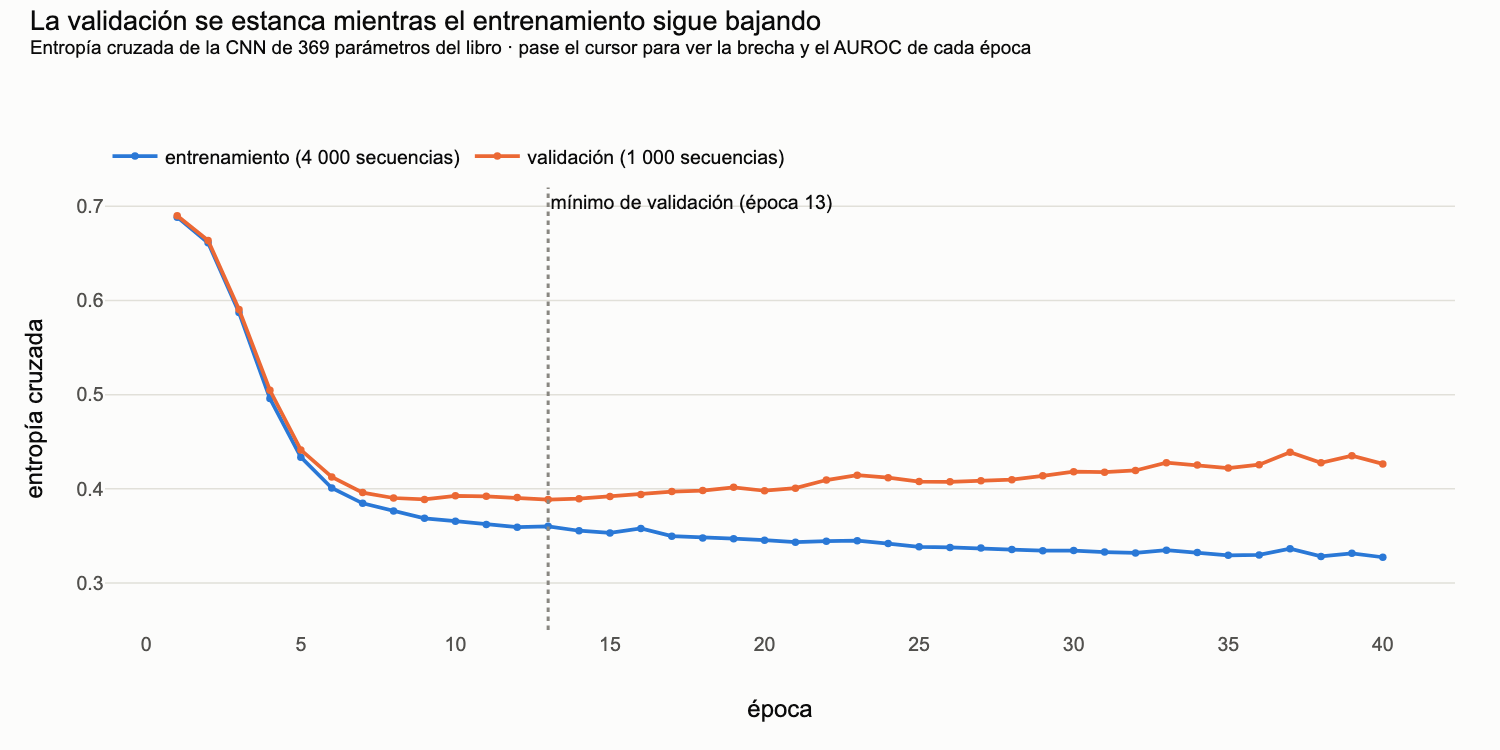

In [13]:
gap = hist.val - hist.train
best_ep = int(hist.epoca[hist.val.idxmin()])
hover = [f"<b>época {e}</b><br>pérdida entrenamiento: {a:.3f}<br>pérdida validación: {b:.3f}"
         f"<br>brecha (val − entr.): {g:+.3f}<br>AUROC validación: {u:.3f}"
         + ("<br><i>después del mínimo de validación:<br>más épocas = más sobreajuste</i>" if e > best_ep else "")
         for e, a, b, g, u in zip(hist.epoca, hist.train, hist.val, gap, hist.auroc_val)]
best_ep = int(hist.epoca[hist.val.idxmin()])
fig = go.Figure()
fig.add_trace(go.Scatter(x=hist.epoca, y=hist.train, mode="lines+markers", name="entrenamiento (4 000 secuencias)",
                         line=dict(color=ec.BLUE, width=2.5), marker=dict(size=5), text=hover,
                         hovertemplate="%{text}<extra></extra>"))
fig.add_trace(go.Scatter(x=hist.epoca, y=hist.val, mode="lines+markers", name="validación (1 000 secuencias)",
                         line=dict(color=ec.ORANGE, width=2.5), marker=dict(size=5), text=hover,
                         hovertemplate="%{text}<extra></extra>"))
fig.add_vline(x=best_ep, line=dict(color=ec.MUTED, dash="dot"),
              annotation_text=f"mínimo de validación (época {best_ep})", annotation_position="top right")
fig.update_layout(
    title="La validación se estanca mientras el entrenamiento sigue bajando<br><sup>Entropía cruzada de la CNN de "
          "369 parámetros del libro · pase el cursor para ver la brecha y el AUROC de cada época</sup>",
    title_y=0.96, title_yanchor="top", xaxis_title="época", yaxis_title="entropía cruzada",
    height=500, margin=dict(t=125, r=30, l=70), yaxis_range=[0.25, 0.72],
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> 🔎 **Qué observamos.** Tras 40 épocas la red alcanza en la prueba un **AUROC de 0,896** y una **exactitud de 0,822**,
> las cifras del libro. Puede parecer poco para un problema "fácil", pero el límite no está en la red sino en los datos
> (apartado 5.1). Las curvas muestran además el **sobreajuste incipiente**: la pérdida de entrenamiento (0,327) queda por
> debajo de la de validación (0,426), y la de validación alcanza su mínimo (0,389) en la época 13 y después **aumenta ligeramente** hasta 0,426. En un proyecto real
> se usaría **parada temprana** (*early stopping*): quedarse con los pesos de la época de mínima pérdida de validación.

> ✅ **Compruebe su comprensión.** ¿Por qué no elegimos la época final mirando la pérdida del conjunto de **prueba**?
> *(Porque entonces la prueba dejaría de ser independiente: estaríamos ajustando un hiperparámetro con ella y su AUROC
> sería optimista. Para eso está la validación.)*

## 6. Qué aprendió: el logo del filtro frente al motivo verdadero

Lo interesante es **qué** aprendió. Seguimos el procedimiento del libro, que es el que emplearon DeepBind y Basset
(Alipanahi et al., 2015; Kelley et al., 2016):

1. tomamos el filtro con **mayor peso positivo** en la capa de salida (el que más "vota" por la clase 1);
2. en cada secuencia de validación y prueba (2 000) localizamos la ventana de **máxima activación** de ese filtro;
3. si supera la **mitad del máximo global**, la añadimos a un alineamiento;
4. con las ventanas resultantes contamos bases por columna (con una pseudocuenta de 0,1) y dibujamos un **logo**.

In [14]:
def filter_logo(model, f, idx, width=11, frac=0.5):
    """Logo del filtro f: ventanas de máxima activación (≥ frac · máximo global) en las secuencias idx."""
    with torch.no_grad():
        act = torch.relu(model.conv(Xc[idx])).numpy()[:, f, :]
    thr = frac * act.max()
    cnt = np.ones((width, 4)) * 0.1
    nwin = 0
    for i, a in zip(idx, act):
        j = int(a.argmax())
        if a[j] > thr and thr > 0:
            nwin += 1
            for q, c in enumerate(sims[i][0][j:j + width]):
                cnt[q, BASES.index(c)] += 1
    return cnt / cnt.sum(1, keepdims=True), nwin

Wfc = net.fc.weight.detach().numpy()[0]
fbest = int(np.argmax(Wfc))
idx_vt = np.r_[iva, ite]
pfm_learn, nwin = filter_logo(net, fbest, idx_vt)
ics = np.array([ic_col(p) for p in pfm_learn])
off = int(np.argmax([ics[o:o + 7].sum() for o in range(5)]))
Wf = net.conv.weight.detach().numpy()[fbest]          # (4, 11)
print("pesos de la capa de salida por filtro:", Wfc.round(2))
print(f"filtro elegido: {fbest} · ventanas en el alineamiento: {nwin}   (libro: 4, 1115)")
print("IC aprendido por posición (bits):", ics.round(2).tolist())
print(f"consenso aprendido: {kmer(pfm_learn)} · desfase del motivo en el filtro: {off}")
print(f"IC teórico: posición fija {ic_col(PFM[0]):.2f} bits · posición degenerada {ic_col(PFM[3]):.2f} bits")
print(f"rango de pesos del filtro: ({Wf.min():.2f}, {Wf.max():.2f})")

pesos de la capa de salida por filtro: [-0.64 -0.63 -0.56 -0.68  1.44 -0.78 -0.63 -0.62]
filtro elegido: 4 · ventanas en el alineamiento: 1115   (libro: 4, 1115)
IC aprendido por posición (bits): [1.47, 1.44, 1.52, 0.67, 1.49, 1.53, 1.49, 0.0, 0.0, 0.0, 0.0]
consenso aprendido: TGAGTCATTAC · desfase del motivo en el filtro: 0
IC teórico: posición fija 1.42 bits · posición degenerada 0.67 bits
rango de pesos del filtro: (-1.54, 1.11)


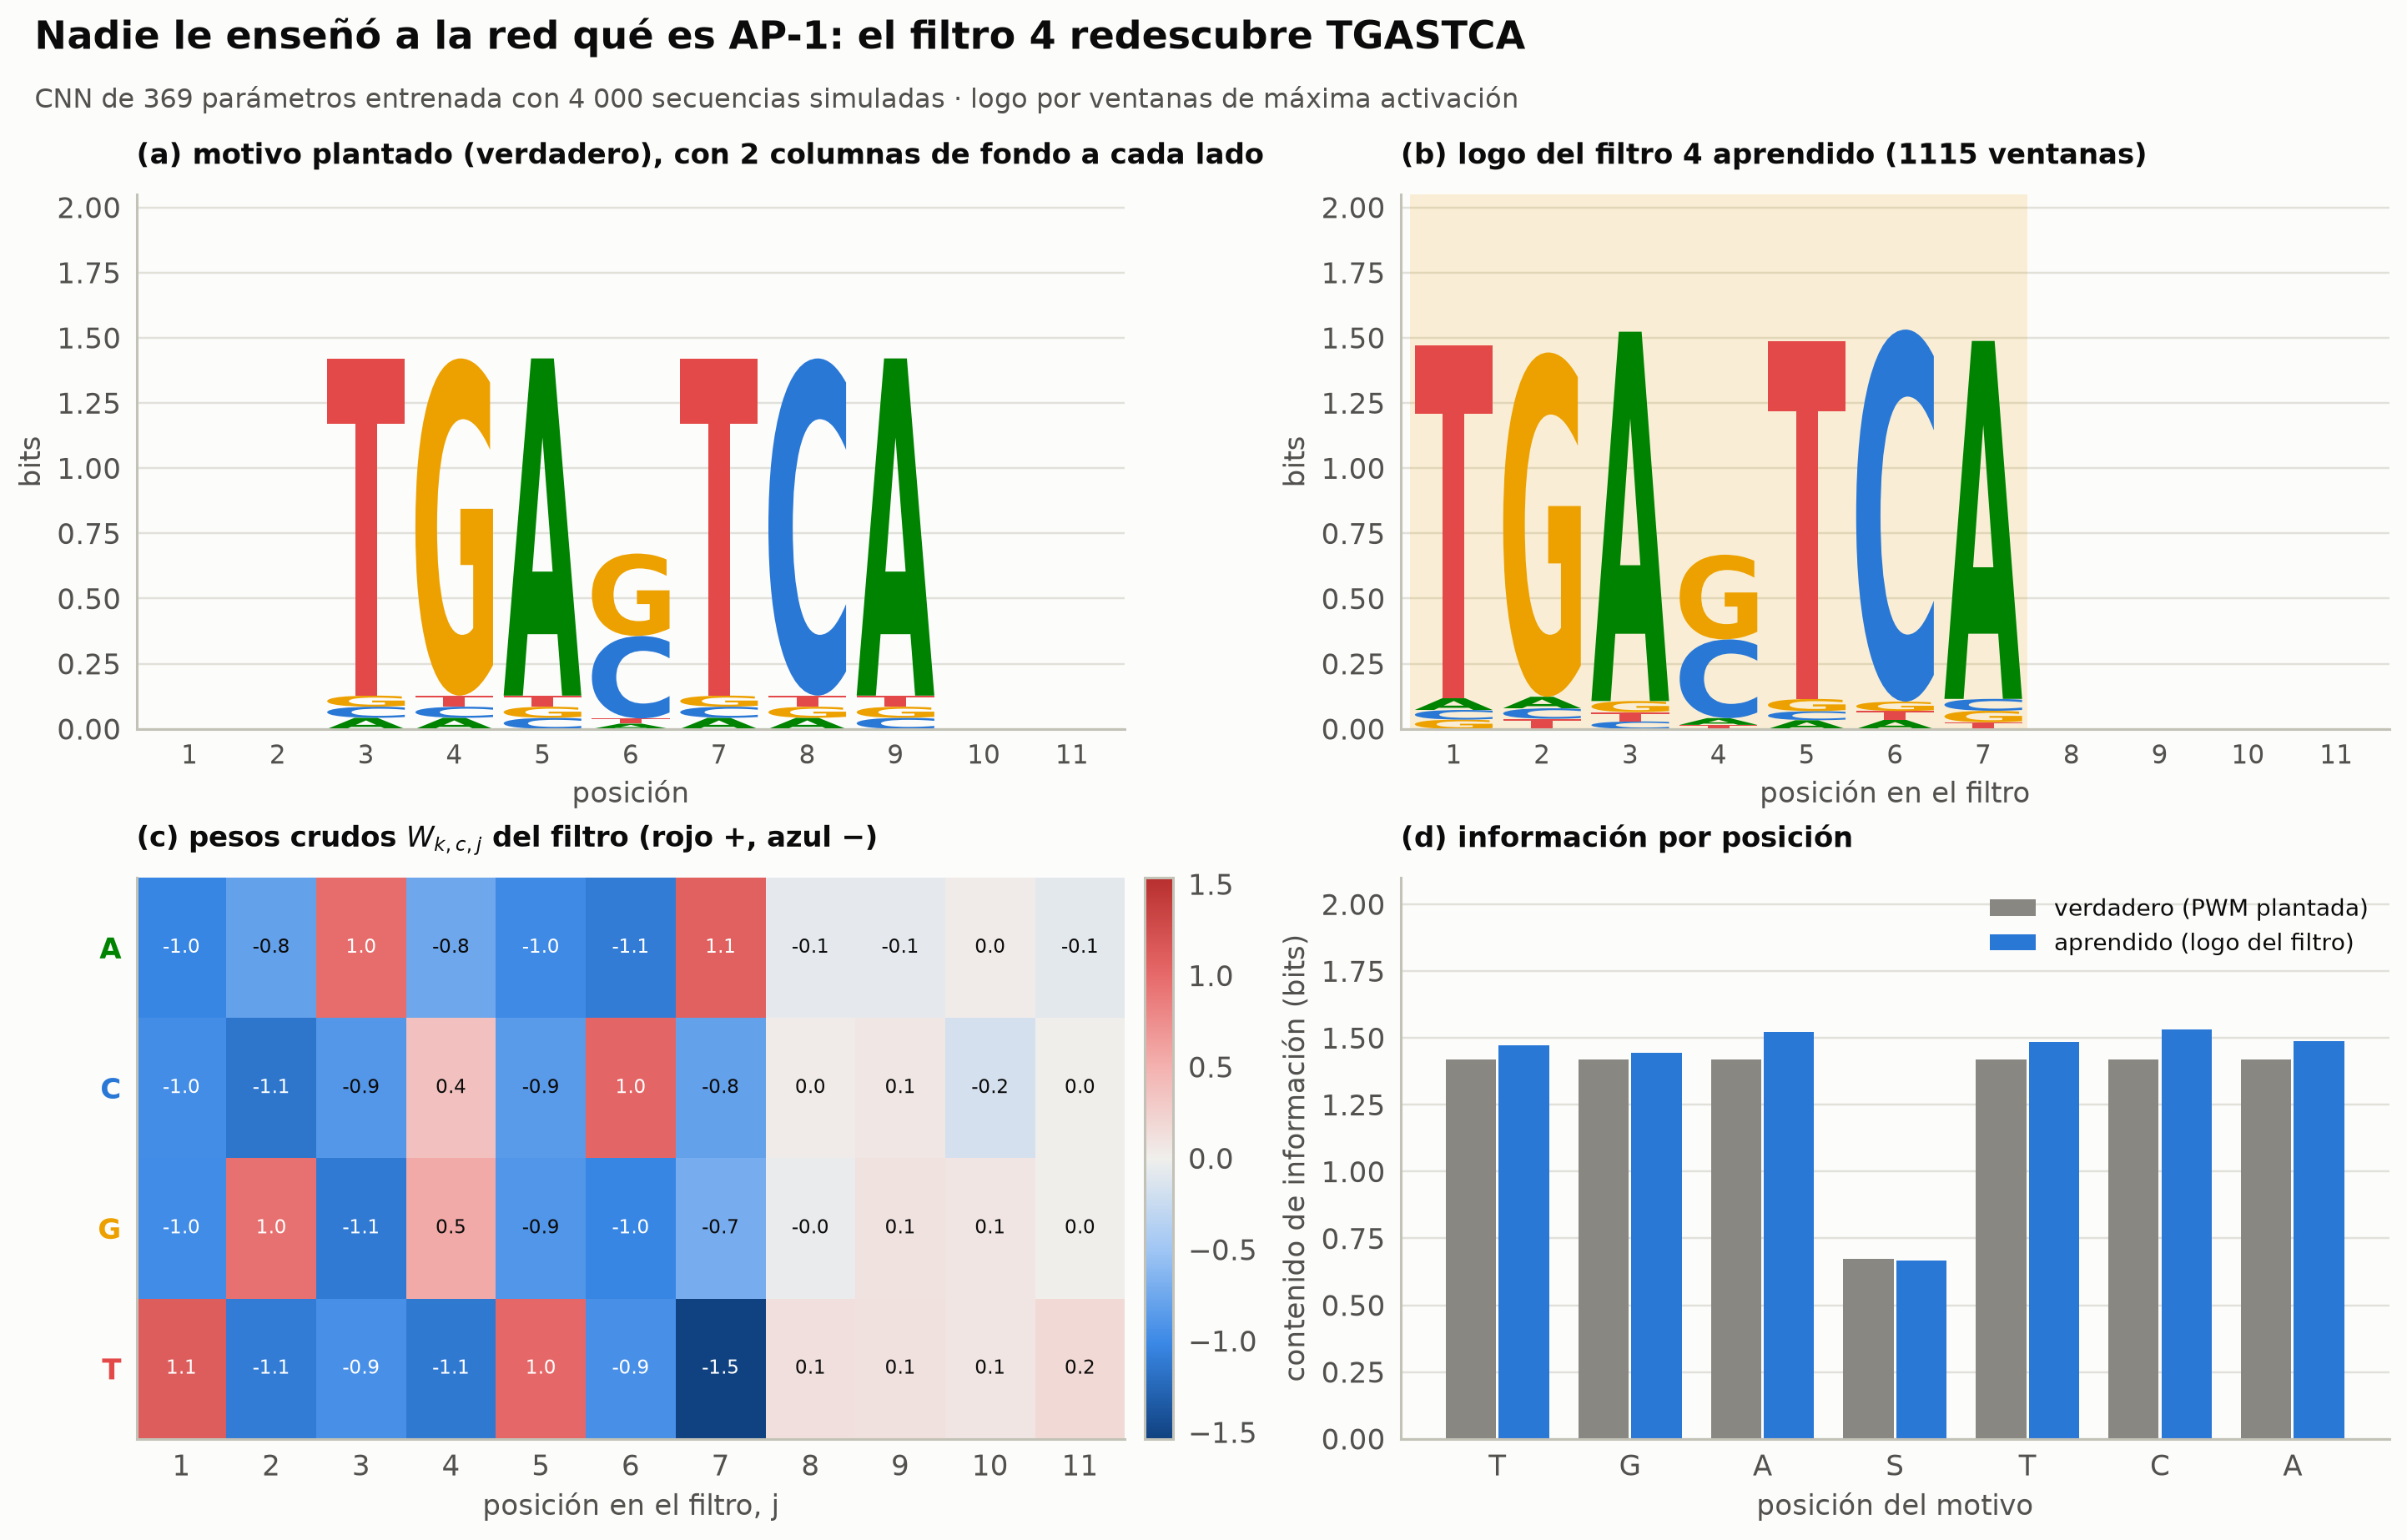

In [15]:
pad = np.full((2, 4), 0.25)
fig = plt.figure(figsize=(13, 7.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.05])
ax_a, ax_b = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
draw_logo(ax_a, np.r_[pad, PFM, pad], title="(a) motivo plantado (verdadero), con 2 columnas de fondo a cada lado",
          xlabel="posición")
draw_logo(ax_b, pfm_learn, title=f"(b) logo del filtro {fbest} aprendido ({nwin} ventanas)", shade=(off + 1, off + 7))
vm = np.abs(Wf).max()
im = ax_c.imshow(Wf, cmap=ec.CMAP_DIV, vmin=-vm, vmax=vm, aspect="auto")
ax_c.set_yticks(range(4)); ax_c.set_yticklabels(list(BASES))
for t_, b in zip(ax_c.get_yticklabels(), BASES):
    t_.set_color(ec.NUC_COLORS[b]); t_.set_fontweight("bold")
ax_c.set_xticks(range(11)); ax_c.set_xticklabels(range(1, 12))
for c in range(4):
    for j in range(11):
        ax_c.text(j, c, f"{Wf[c, j]:.1f}", ha="center", va="center", fontsize=7.5,
                  color="white" if abs(Wf[c, j]) > 0.6 * vm else ec.INK)
ax_c.set_xlabel("posición en el filtro, j"); ax_c.grid(False)
ax_c.set_title("(c) pesos crudos $W_{k,c,j}$ del filtro (rojo +, azul −)", fontsize=11, loc="left")
plt.colorbar(im, ax=ax_c, fraction=0.04, pad=0.02)
ax_d = fig.add_subplot(gs[1, 1])
theo = np.array([ic_col(p) for p in PFM])
xs = np.arange(1, 8)
ax_d.bar(xs - 0.2, theo, width=0.38, color=ec.MUTED, label="verdadero (PWM plantada)")
ax_d.bar(xs + 0.2, ics[off:off + 7], width=0.38, color=ec.BLUE, label="aprendido (logo del filtro)")
ax_d.set_xticks(xs); ax_d.set_xticklabels(list("TGASTCA"))
ax_d.set_ylim(0, 2.1); ax_d.set_ylabel("contenido de información (bits)"); ax_d.set_xlabel("posición del motivo")
ax_d.legend(loc="upper right", frameon=False, fontsize=9, ncol=1)
ax_d.set_title("(d) información por posición", fontsize=11, loc="left")
ec.fig_title(fig, "Nadie le enseñó a la red qué es AP-1: el filtro 4 redescubre TGASTCA",
             "CNN de 369 parámetros entrenada con 4 000 secuencias simuladas · logo por ventanas de máxima activación")
plt.show()

> 🔎 **Qué observamos.** El logo del filtro (b) es el motivo que plantamos: consenso `TGAGTCA`, con contenidos de
> información de 1,44 a 1,53 bits en las posiciones fijas (el valor teórico es 1,42) y **0,67 bits** en la posición
> degenerada, exactamente el valor teórico de la columna plantada (0,47 para `C`, 0,47 para `G` y 0,03 para `A` y `T`);
> una mezcla pura al 50 % de `C` y `G` daría 1 bit, pero el 6 % reservado a las otras dos bases le resta información (d). Las cuatro últimas columnas quedan vacías
> porque el filtro, de 11 pb, es **más ancho** que el motivo de 7 pb. Los **pesos crudos** (c) son directamente una
> matriz de tipo PWM, como dice el teorema: rojo en la base de consenso, azul en las demás. ¿Por qué el logo aprendido
> tiene algo **más** de información que el verdadero? Porque sólo entran ventanas con activación alta, es decir, copias
> del motivo más parecidas al consenso: una selección que "afila" el logo.

¿Cómo llega un filtro aleatorio a convertirse en un motivo? Usemos las instantáneas guardadas durante el entrenamiento.

![El filtro 4 durante el entrenamiento: de pesos aleatorios a la PWM de AP-1. El motivo emerge entre las épocas 2 y 5, cuando cae la pérdida, y después sólo se afina mientras la validación se estanca](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-17-machine-learning/17.2_filtro_aprende.gif)

*El filtro 4 durante el entrenamiento: de pesos aleatorios a la PWM de AP-1. El motivo emerge entre las épocas 2 y 5, cuando cae la pérdida, y después sólo se afina mientras la validación se estanca*

In [16]:
frames_data = []
for label, x_ep, sd in snaps:
    m = CNN(); m.load_state_dict(sd); m.eval()
    pf, nw = filter_logo(m, fbest, idx_vt)
    frames_data.append((label, x_ep, pf, nw, m.conv.weight.detach().numpy()[fbest].copy()))
vmax_w = max(np.abs(f[4]).max() for f in frames_data)

fig = plt.figure(figsize=(12, 7.4))
fig.set_layout_engine("none")
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1.15, 1], hspace=0.5, wspace=0.22,
                      left=0.07, right=0.97, top=0.86, bottom=0.08)
ax_l, ax_w, ax_c = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])
fig.text(0.01, 0.965, "Un filtro aleatorio se convierte en el motivo AP-1", fontsize=15, weight="bold")
fig.text(0.01, 0.925, f"Filtro {fbest} de la CNN del libro: logo por ventanas de máxima activación, pesos crudos y "
         "curvas de pérdida en cada instantánea", fontsize=10.5, color=ec.INK_2)

def update(t):
    label, x_ep, pf, nw, W_ = frames_data[t]
    for a in (ax_l, ax_w, ax_c):
        a.clear()
    draw_logo(ax_l, pf, title=f"{label} · consenso {kmer(pf)} · {nw} ventanas")
    ax_w.imshow(W_, cmap=ec.CMAP_DIV, vmin=-vmax_w, vmax=vmax_w, aspect="auto")
    ax_w.set_yticks(range(4)); ax_w.set_yticklabels(list(BASES)); ax_w.set_xticks(range(11))
    ax_w.set_xticklabels(range(1, 12)); ax_w.grid(False)
    ax_w.set_title("pesos $W_{k,c,j}$ (rojo +, azul −)", fontsize=11, loc="left")
    ax_c.plot(hist.epoca, hist.train, color=ec.BASELINE, lw=1.5)
    ax_c.plot(hist.epoca, hist.val, color=ec.BASELINE, lw=1.5, ls="--")
    k = int(np.floor(x_ep + 1e-9))
    if k >= 1:
        ax_c.plot(hist.epoca[:k], hist.train[:k], color=ec.BLUE, lw=2.5)
        ax_c.plot(hist.epoca[:k], hist.val[:k], color=ec.ORANGE, lw=2.5, ls="--")
    ax_c.axvline(max(x_ep, 0.02), color=ec.INK_2, lw=1)
    ax_c.text(40.5, hist.train.iloc[-1], "entrenamiento", va="center", fontsize=9.5, color=ec.INK_2)
    ax_c.text(40.5, hist.val.iloc[-1], "validación", va="center", fontsize=9.5, color=ec.INK_2)
    ax_c.set_xlim(0, 46); ax_c.set_ylim(0.25, 0.72)
    ax_c.set_xlabel("época"); ax_c.set_ylabel("entropía cruzada")
    return ()

ec.animate(fig, update, frames=len(frames_data), interval=260, name="17.2_filtro_aprende")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Antes de entrenar, los pesos son ruido y el "logo" es casi plano; durante la primera época
> apenas cambia (la pérdida sigue en $\log 2\approx0{,}69$, la de una moneda). Entre las **épocas 2 y 5** el motivo
> `TGA.TCA` **emerge**, justo cuando la pérdida se desploma: el gradiente empuja el filtro hacia las ventanas que
> separan las clases, y esas ventanas son los sitios plantados. El resto del entrenamiento sólo **afina** los pesos
> (el contraste rojo/azul crece) mientras la validación se estanca. Es la versión aprendida de lo que la lección 13.3 hacía con EM: estimar una
> PWM sin saber dónde están los sitios, pero guiada por las **etiquetas** en lugar de por un modelo generativo.

## 7. De DeepBind a Enformer: la carrera por el contexto

La historia reciente de la genómica regulatoria puede leerse como una carrera por ampliar el **contexto** que ve la red.

**DeepBind** (Alipanahi et al., 2015) aplicó por primera vez CNN a gran escala para predecir la especificidad de
proteínas de unión a ADN y ARN a partir de microarreglos de unión (PBM), SELEX, ChIP-seq y CLIP-seq. Su arquitectura era
esencialmente la de nuestro experimento: una capa convolucional, *pooling* y una pequeña red densa, **un modelo por
proteína**. Introdujo además los "mapas de mutación", que muestran cómo cambia la predicción al mutar cada base.

**DeepSEA** (Zhou y Troyanskaya, 2015) dio el salto a la predicción **multitarea**: una sola red que, a partir de
1 000 pb, predice simultáneamente **919 perfiles** de cromatina (unión de factores de transcripción, hipersensibilidad a
DNasa, marcas de histonas) de ENCODE y Roadmap. Y, sobre todo, lo usó para **puntuar variantes no codificantes** por la
diferencia entre las predicciones de los dos alelos:

$$
\Delta_t(v) = f_t\big(x^{\text{alt}}\big) - f_t\big(x^{\text{ref}}\big),
$$

| Símbolo | Significado |
|---|---|
| $f_t(x)$ | predicción del modelo para la pista $t$ (p. ej., unión de CTCF en células K562) con la secuencia $x$ |
| $x^{\text{ref}},\ x^{\text{alt}}$ | secuencia de referencia y la misma con el alelo alternativo de la variante $v$ |
| $\Delta_t(v)$ | efecto predicho de la variante sobre la pista $t$ |

lo que permite **priorizar variantes de GWAS** (lección 10.3) sin haber medido nunca su efecto. **Basset** (Kelley et
al., 2016) entrenó una CNN profunda sobre sitios accesibles medidos por DNase-seq en **164 tipos celulares** y mostró que
sus predicciones de cambio de accesibilidad eran mucho mayores para las variantes de GWAS probablemente causales que para
sus vecinas en desequilibrio de ligamiento.

El siguiente obstáculo era la **distancia**. Los potenciadores pueden actuar a decenas de kilobases del promotor que
regulan, pero una pila de convoluciones con filtros de ancho $w$ sólo "ve" unos pocos cientos de pares de bases.
**Basenji** (Kelley et al., 2018) usó **convoluciones dilatadas**, que saltan posiciones con un paso $d$ creciente, para
cubrir secuencias de 131 kb. Con $D$ capas de ancho $w$ y dilataciones $d_l$, el **campo receptivo** (el tramo de
secuencia que influye en una salida) es

$$
R = 1 + \sum_{l=1}^{D}(w-1)\,d_l \;\overset{d_l=2^{l-1}}{=}\; 1 + (w-1)\,\big(2^{D}-1\big),
$$

| Símbolo | Significado |
|---|---|
| $R$ | campo receptivo en pares de bases |
| $d_l$ | dilatación de la capa $l$ (cuántas posiciones salta el filtro entre elementos) |
| $w,\ D$ | ancho de los filtros y número de capas dilatadas |

**A mano.** Con $w=3$ y $D=11$ capas **sin** dilatar ($d_l=1$), $R=1+2\times11=23$ pb. **Duplicando** la dilatación en
cada capa ($d_l=1,2,4,\dots,1024$), $R=1+2\times(2^{11}-1)=1+2\times2047=4\,095$ posiciones: el campo receptivo crece de
forma **exponencial** con la profundidad en lugar de lineal. Finalmente, **Enformer** (Avsec et al., 2021) sustituyó
las convoluciones dilatadas por capas de **atención** (el mecanismo de la lección 17.3) sobre secuencias de unos
200 kb, integrando información de elementos situados hasta a 100 kb de distancia, lo que mejoró de forma sustancial la
predicción de la expresión génica y del efecto de variantes medido por ensayos de reporteros masivamente paralelos.

w = 3, D = 11: sin dilatar R = 23 · dilatación doble R = 4095


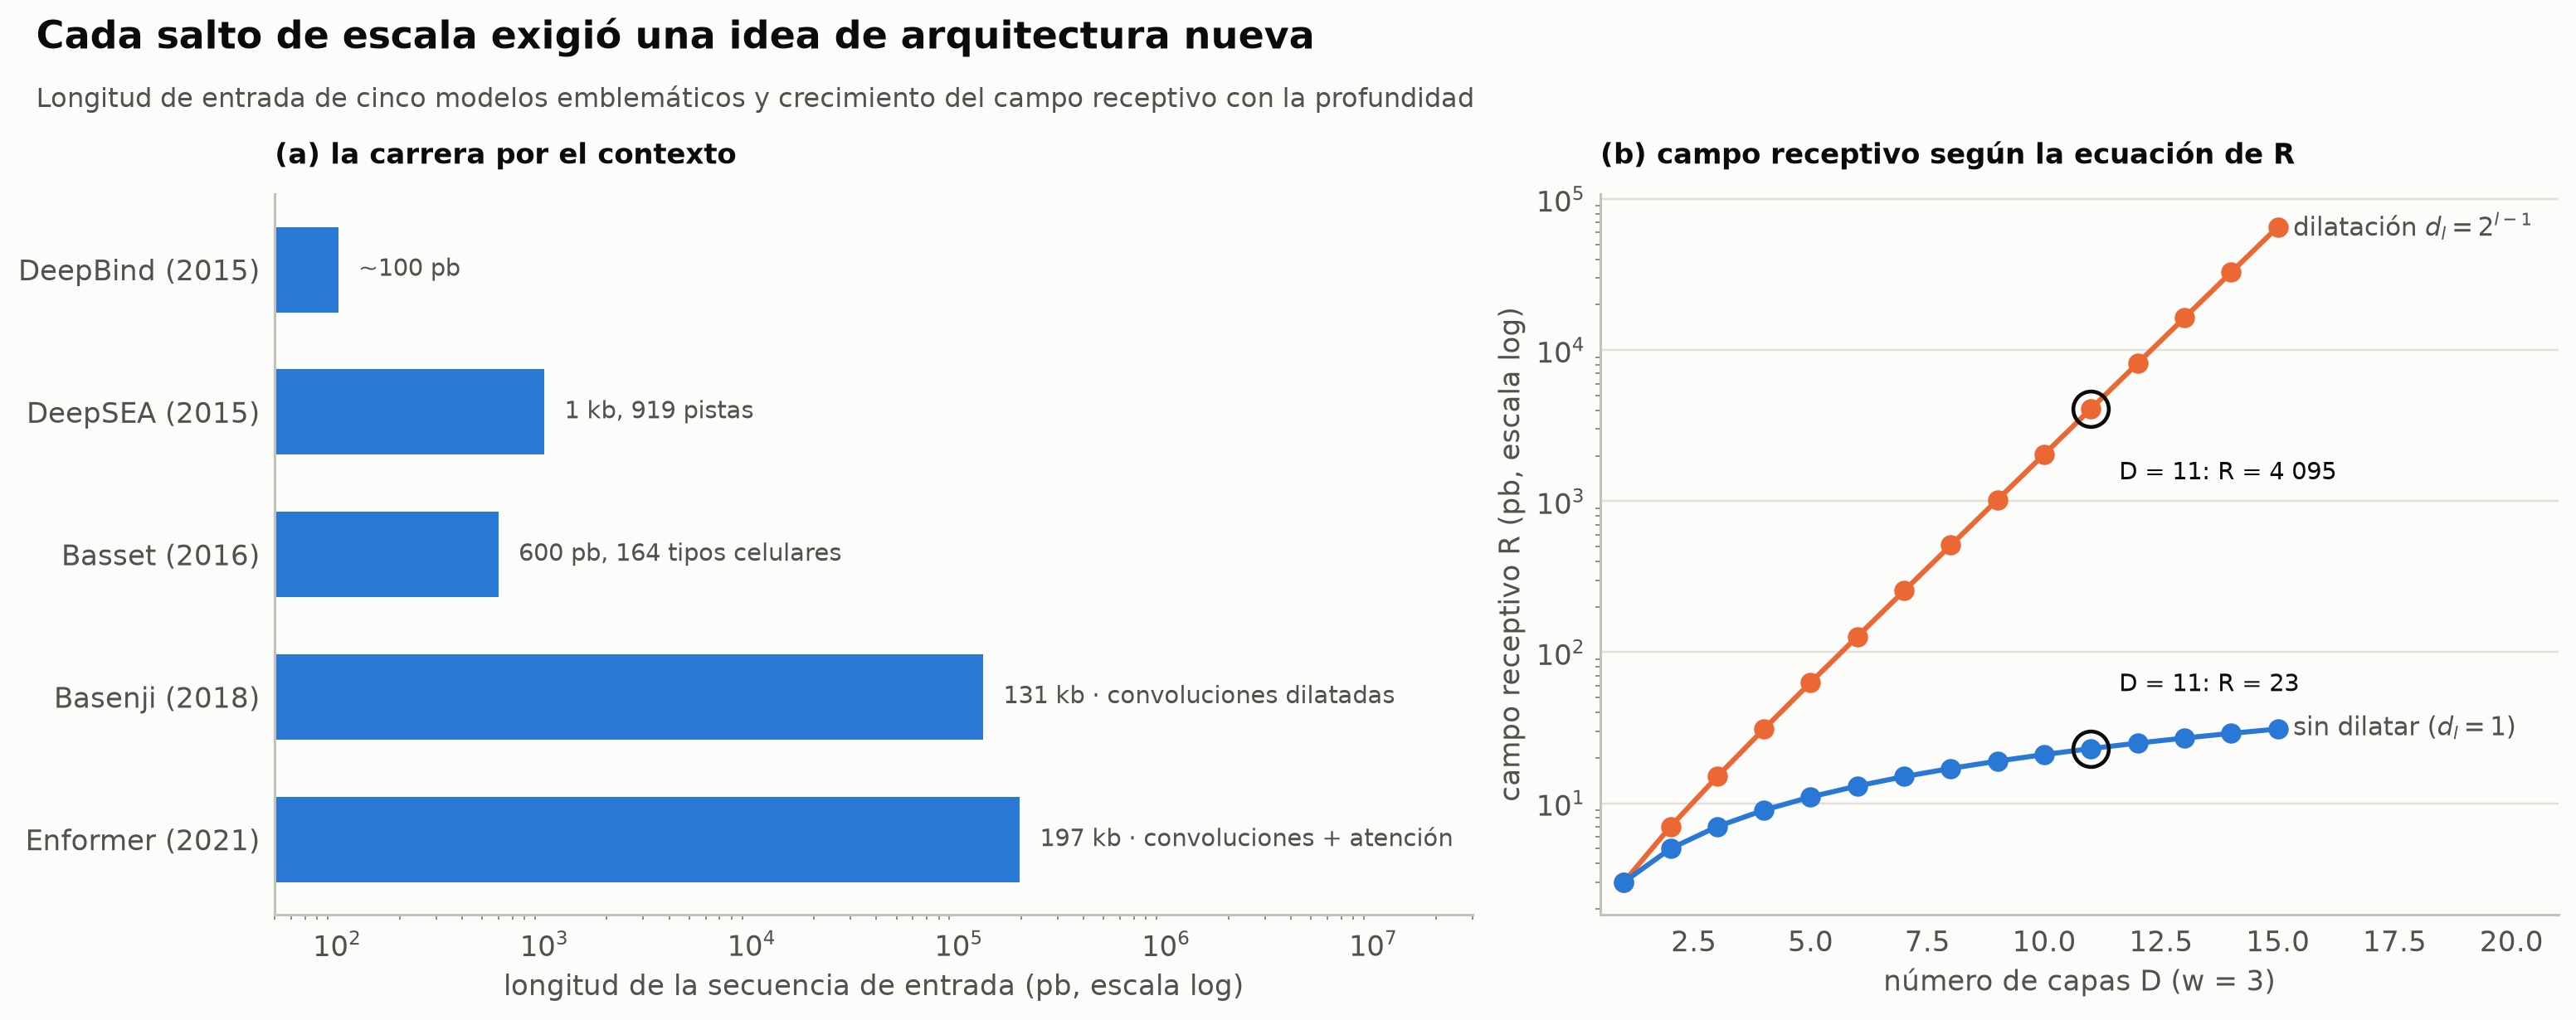

In [17]:
def receptive_field(w, dilations):
    return 1 + sum((w - 1) * d for d in dilations)

Ds = np.arange(1, 16)
R_lin = [receptive_field(3, [1] * D) for D in Ds]
R_dil = [receptive_field(3, [2 ** (l - 1) for l in range(1, D + 1)]) for D in Ds]
print("w = 3, D = 11: sin dilatar R =", R_lin[10], "· dilatación doble R =", R_dil[10])

models = pd.DataFrame({"modelo": ["DeepBind (2015)", "DeepSEA (2015)", "Basset (2016)", "Basenji (2018)", "Enformer (2021)"],
                       "entrada_pb": [101, 1000, 600, 131072, 196608],
                       "nota": ["~100 pb", "1 kb, 919 pistas", "600 pb, 164 tipos celulares",
                                "131 kb · convoluciones dilatadas", "197 kb · convoluciones + atención"]})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8), width_ratios=[1.25, 1])
yy = np.arange(len(models))[::-1]
ax1.barh(yy, models.entrada_pb, color=ec.BLUE, height=0.6)
for y_, v, t_ in zip(yy, models.entrada_pb, models.nota):
    ax1.text(v * 1.25, y_, t_, va="center", fontsize=9.5, color=ec.INK_2)
ax1.set_yticks(yy); ax1.set_yticklabels(models.modelo)
ax1.set_xscale("log"); ax1.set_xlim(50, 3e7); ax1.set_xlabel("longitud de la secuencia de entrada (pb, escala log)")
ax1.grid(axis="y", visible=False)
ax1.set_title("(a) la carrera por el contexto", fontsize=11, loc="left")
ax2.plot(Ds, R_dil, "o-", color=ec.ORANGE, lw=2)
ax2.plot(Ds, R_lin, "o-", color=ec.BLUE, lw=2)
ec.label_end(ax2, Ds[-1], R_dil[-1], "dilatación $d_l=2^{l-1}$")
ec.label_end(ax2, Ds[-1], R_lin[-1], "sin dilatar ($d_l=1$)")
ax2.plot(11, R_dil[10], "o", ms=14, mfc="none", mec=ec.INK, mew=1.5)
ax2.text(11.6, R_dil[10] * 0.45, "D = 11: R = 4 095", fontsize=9.5, color=ec.INK, va="top")
ax2.plot(11, R_lin[10], "o", ms=14, mfc="none", mec=ec.INK, mew=1.5)
ax2.text(11.6, R_lin[10] * 2.2, "D = 11: R = 23", fontsize=9.5, color=ec.INK, va="bottom")
ax2.set_yscale("log"); ax2.set_xlim(0.5, 21); ax2.set_xlabel("número de capas D (w = 3)")
ax2.set_ylabel("campo receptivo R (pb, escala log)")
ax2.set_title("(b) campo receptivo según la ecuación de R", fontsize=11, loc="left")
ec.fig_title(fig, "Cada salto de escala exigió una idea de arquitectura nueva",
             "Longitud de entrada de cinco modelos emblemáticos y crecimiento del campo receptivo con la profundidad")
plt.show()

> 🔎 **Qué observamos.** De DeepBind a Enformer la entrada creció unas **dos mil veces**, y cada salto necesitó una
> idea nueva: *pooling* y multitarea, dilatación, atención. En (b), con capas normales el campo receptivo crece
> **linealmente** (23 pb con 11 capas); duplicando la dilatación crece **exponencialmente** (4 095 pb con las mismas 11
> capas y el mismo número de parámetros).

> ✅ **Compruebe su comprensión.** ¿Cuántas capas dilatadas de ancho $w=3$ con $d_l=2^{l-1}$ necesitaría para un campo
> receptivo de al menos 100 kb? *(Hay que cumplir $1+2(2^D-1)\ge 10^5$, es decir $2^D\ge 50\,000{,}5$: $D=16$, con
> $R=131\,071$ pb, justo la escala de Basenji.)*

## 8. Abrir la caja negra: saliencia, mutagénesis *in silico* y DeepLIFT

Un modelo que predice bien no explica **por qué** predice. Para convertir predicciones en hipótesis biológicas
necesitamos saber qué bases fueron responsables. El método más directo son los **mapas de saliencia** de Simonyan et al.
(2013): la derivada de la salida respecto de la entrada, que la retropropagación calcula **gratis** (es el mismo
algoritmo del apartado 3, pero derivando respecto de $X$ en lugar de respecto de $W$). En secuencias *one-hot* se usa la
variante **gradiente × entrada**:

$$
s_i = \sum_{c} X_{c,i}\,\frac{\partial f(X)}{\partial X_{c,i}} = \left.\frac{\partial f}{\partial X_{c,i}}\right|_{c=x_i},
$$

| Símbolo | Significado |
|---|---|
| $s_i$ | contribución atribuida a la base observada en la posición $i$ |
| $f(X)$ | salida del modelo (*logit*) para la secuencia codificada $X$ |

que, igual que en el teorema del filtro, **selecciona la derivada correspondiente a la base presente**. Tomamos la misma
secuencia de prueba que el libro: la primera positiva del conjunto de prueba con el sitio completo (`TGACTCA` o
`TGAGTCA`) que empieza entre las posiciones 32 y 60 (contando desde 1) y con *logit* mayor que 2.

In [18]:
cons = {"TGACTCA", "TGAGTCA"}
cand = [i for i in ite if yc[i] == 1 and 30 < sims[i][1] < 60
        and sims[i][0][sims[i][1]:sims[i][1] + 7] in cons and lte[i - 5000] > 2]
i0 = cand[0]
s0, at0 = sims[i0]
xi = Xc[i0:i0 + 1].clone().requires_grad_(True)
net(xi).sum().backward()                                   # ∂ logit / ∂ X
sal = (xi.grad * xi).detach().numpy()[0].sum(0)             # gradiente × entrada → s_i
frac = np.abs(sal[at0:at0 + 7]).sum() / np.abs(sal).sum()
print("secuencia:", s0)
print(f"motivo en posiciones {at0 + 1}–{at0 + 7}: {s0[at0:at0 + 7]}   (libro: 37–43, TGAGTCA)")
print(f"logit = {lte[i0 - 5000]:.2f} → P(y=1) = {1 / (1 + np.exp(-lte[i0 - 5000])):.3f}")
print(f"fracción de |s| dentro del motivo: {frac:.3f}   (libro: 0,464) · el motivo es el {7 / Lc:.0%} de la secuencia")
top = np.abs(sal).argsort()[::-1][:10]
print("posiciones más influyentes:", (top + 1).tolist())

secuencia: CCTGATCATCAAGAAAACCACGGCCAGTTGGGTGAGTGAGTCAGATACGTTCGGTGATCCAGGGAAAAGGGTGGCTTAGTATATATTCGTTCACCGACTC
motivo en posiciones 37–43: TGAGTCA   (libro: 37–43, TGAGTCA)
logit = 2.78 → P(y=1) = 0.942
fracción de |s| dentro del motivo: 0.464   (libro: 0,464) · el motivo es el 7% de la secuencia
posiciones más influyentes: [37, 41, 39, 42, 38, 43, 40, 69, 94, 24]


La pista de saliencia es larga (100 posiciones) y conviene explorarla con el cursor: cada barra es una base, coloreada
por su nucleótido; el sombreado amarillo marca el sitio plantado.

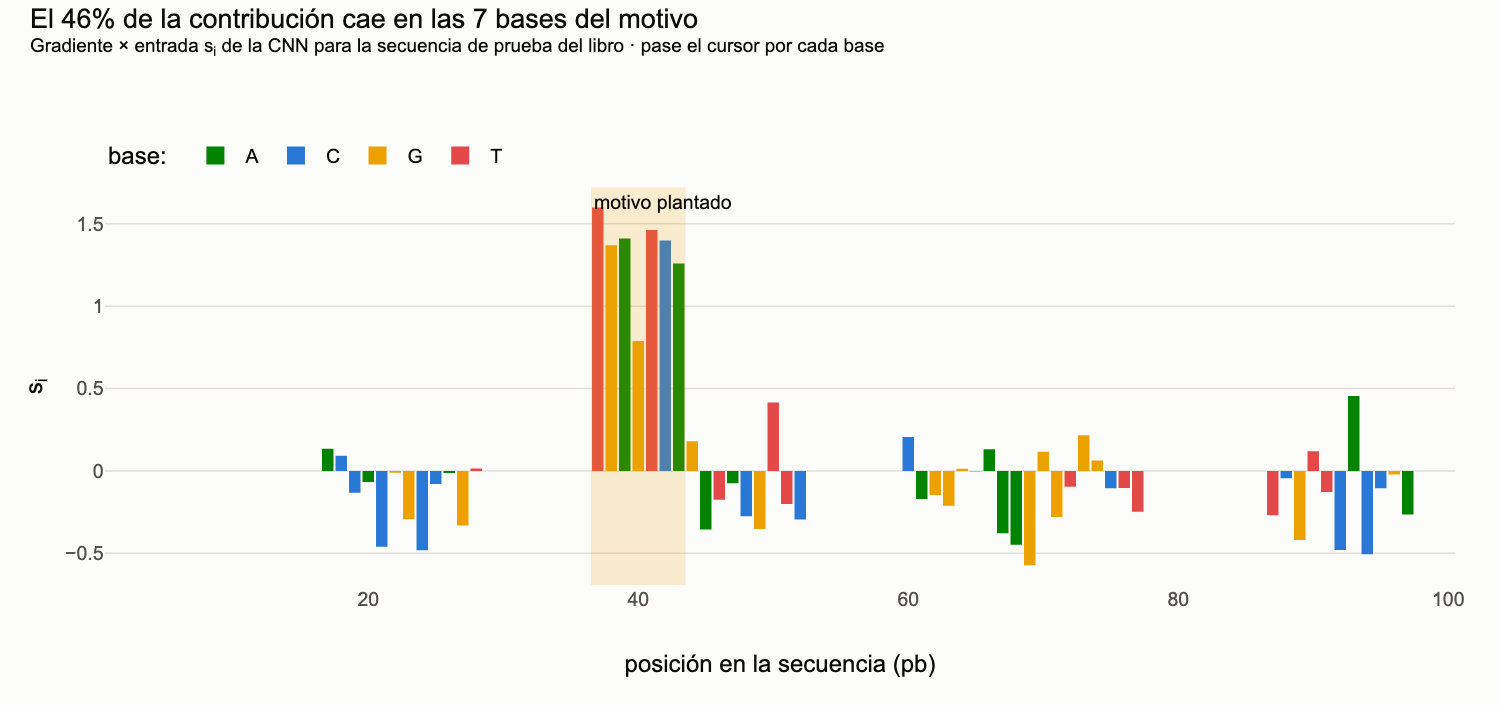

In [19]:
pos = np.arange(1, Lc + 1)
fig = go.Figure()
fig.add_vrect(x0=at0 + 0.5, x1=at0 + 7.5, fillcolor=ec.YELLOW, opacity=0.18, line_width=0,
              annotation_text="motivo plantado", annotation_position="top left")
for b in BASES:
    msk = np.array([c == b for c in s0])
    txt = [f"<b>posición {p}</b> · base <b>{b}</b><br>s<sub>i</sub> = {v:+.3f}"
           + ("<br><i>dentro del sitio AP-1 plantado</i>" if at0 < p <= at0 + 7 else "")
           + ("<br>contribuye a favor de «se une»" if v > 0 else "<br>contribuye en contra")
           for p, v in zip(pos[msk], sal[msk])]
    fig.add_trace(go.Bar(x=pos[msk], y=sal[msk], name=b, marker_color=ec.NUC_COLORS[b], text=txt,
                         hovertemplate="%{text}<extra></extra>", textposition="none"))
fig.update_layout(
    title=f"El {frac:.0%} de la contribución cae en las 7 bases del motivo<br><sup>Gradiente × entrada s<sub>i</sub> de la CNN "
          f"para la secuencia de prueba del libro · pase el cursor por cada base</sup>",
    title_y=0.96, title_yanchor="top", xaxis_title="posición en la secuencia (pb)", yaxis_title="s<sub>i</sub>",
    height=470, margin=dict(t=125, r=30, l=70), bargap=0.15, xaxis_range=[0.5, 100.5],
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0, title_text="base: "))
fig.show()

La misma información como **logo de contribución** (como en la figura del libro): la altura de cada letra es
proporcional a $s_i$, hacia abajo y en tono pálido si es negativa. Al lado, la alternativa de fuerza bruta: la
**mutagénesis *in silico*** (ISM), que muta cada posición a las tres bases alternativas y registra
$\Delta=f(x^{\text{alt}})-f(x^{\text{ref}})$ con la ecuación de DeepSEA. Es exacta pero cuesta $3L=300$ evaluaciones
(en un solo lote, una fracción de segundo para esta red).

300 mutantes evaluados · correlación entre saliencia y −(efecto medio de ISM): r = 0.96
mutación más dañina: posición 39 A>G, Δ = -3.20 en el logit


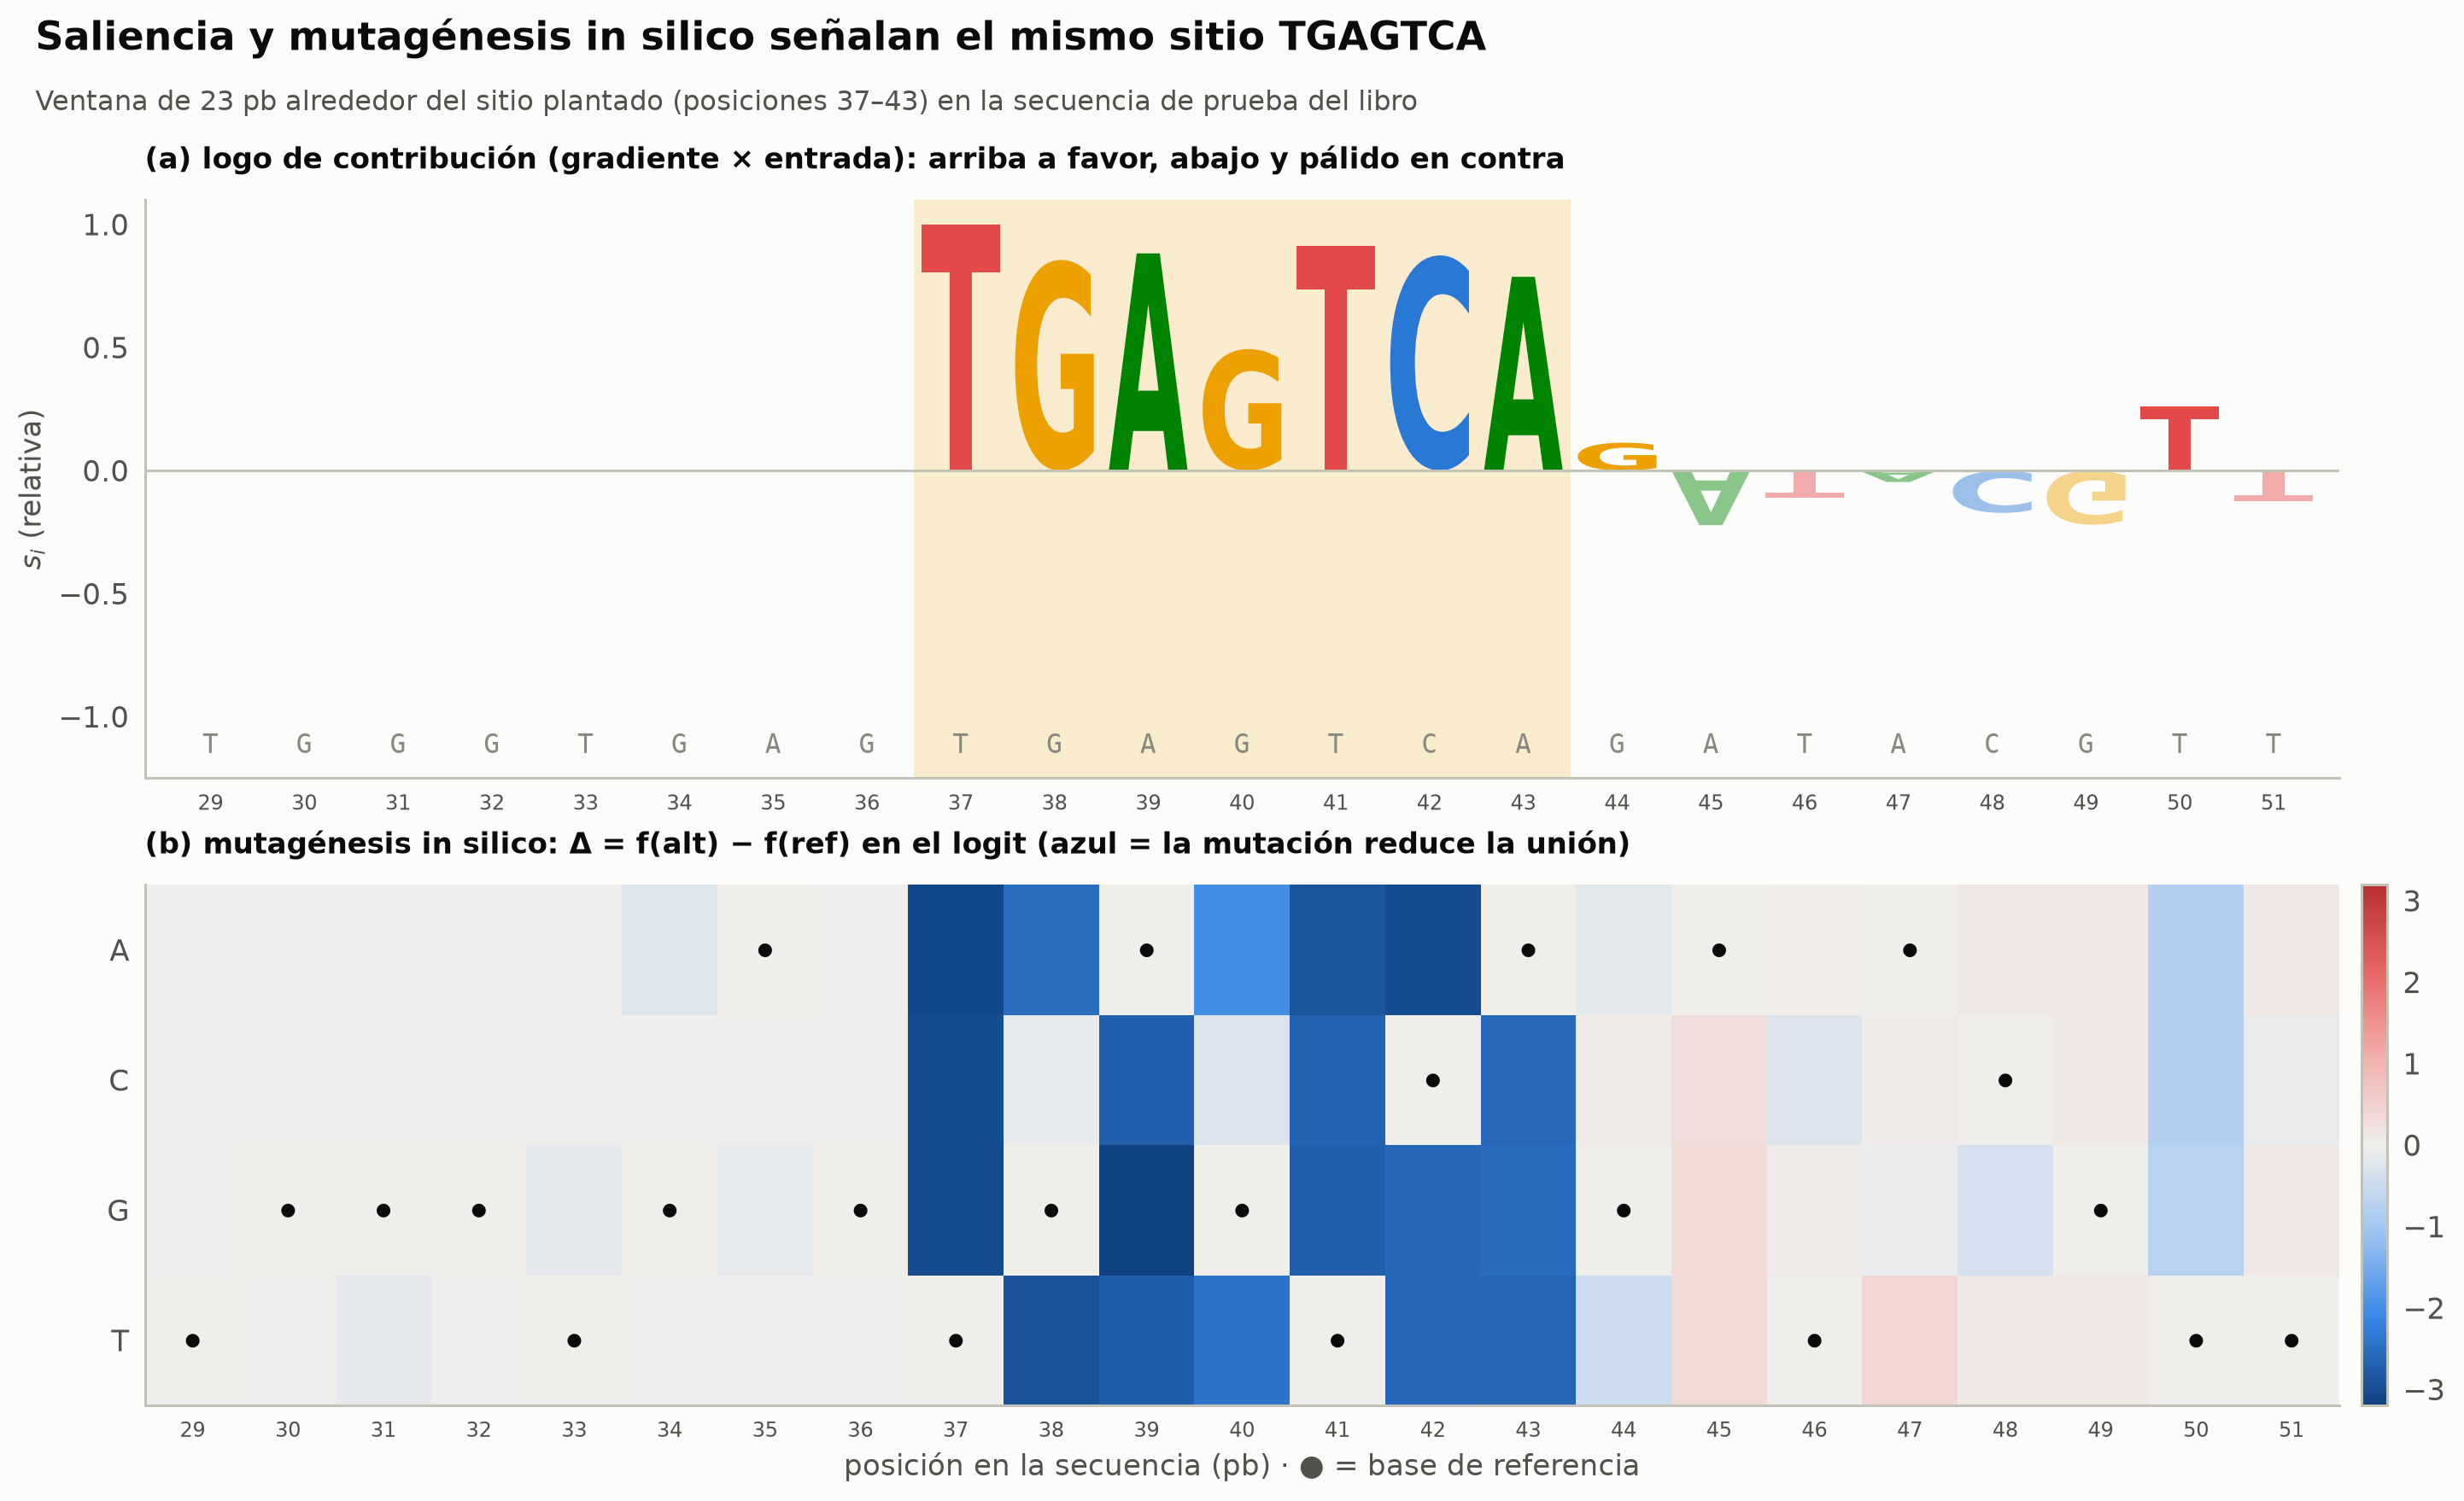

In [20]:
# Mutagénesis in silico: 3L secuencias mutantes evaluadas en un lote
muts = []
for p in range(Lc):
    for b in BASES:
        if b != s0[p]:
            muts.append((p, b, s0[:p] + b + s0[p + 1:]))
with torch.no_grad():
    f_ref = net(Xc[i0:i0 + 1]).item()
    f_alt = net(torch.tensor(np.stack([onehot(m[2]) for m in muts]))).numpy()
ism = np.zeros((4, Lc))
for (p, b, _), v in zip(muts, f_alt):
    ism[BASES.index(b), p] = v - f_ref
ism_mean = ism.sum(0) / 3                                   # efecto medio de mutar la posición i
r_ = np.corrcoef(-ism_mean, sal)[0, 1]
print(f"{len(muts)} mutantes evaluados · correlación entre saliencia y −(efecto medio de ISM): r = {r_:.2f}")
worst = np.unravel_index(ism.argmin(), ism.shape)
print(f"mutación más dañina: posición {worst[1] + 1} {s0[worst[1]]}>{BASES[worst[0]]}, Δ = {ism.min():.2f} en el logit")

a_, b_ = at0 - 8, at0 + 15
fig = plt.figure(figsize=(13, 7.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 0.9])
ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
vmax = np.abs(sal[a_:b_]).max()
ax1.axvspan(at0 - a_ + 0.5, at0 - a_ + 7.5, color=ec.YELLOW, alpha=0.18, lw=0)
for k in range(a_, b_):
    c = s0[k]; v = sal[k] / vmax; xk = k - a_ + 1
    draw_letter(ax1, c, xk - 0.42, 0, 0.84, v, ec.NUC_COLORS[c], alpha=1.0 if v > 0 else 0.45)
    ax1.text(xk, -1.12, c, ha="center", va="center", family="monospace", fontsize=10, color=ec.MUTED)
ax1.axhline(0, color=ec.BASELINE, lw=1)
ax1.set_xlim(0.3, b_ - a_ + 0.7); ax1.set_ylim(-1.25, 1.1)
ax1.set_xticks(range(1, b_ - a_ + 1)); ax1.set_xticklabels(range(a_ + 1, b_ + 1), fontsize=8)
ax1.set_ylabel("$s_i$ (relativa)"); ax1.grid(False)
ax1.set_title("(a) logo de contribución (gradiente × entrada): arriba a favor, abajo y pálido en contra",
              fontsize=11, loc="left")
vm = np.abs(ism[:, a_:b_]).max()
im = ax2.imshow(ism[:, a_:b_], cmap=ec.CMAP_DIV, vmin=-vm, vmax=vm, aspect="auto",
                extent=(a_ + 0.5, b_ + 0.5, 3.5, -0.5))
for k in range(a_, b_):
    ax2.text(k + 1, BASES.index(s0[k]), "●", ha="center", va="center", fontsize=7, color=ec.INK)
ax2.set_yticks(range(4)); ax2.set_yticklabels(list(BASES)); ax2.grid(False)
ax2.set_xticks(range(a_ + 1, b_ + 1)); ax2.tick_params(axis="x", labelsize=8)
ax2.set_xlabel("posición en la secuencia (pb) · ● = base de referencia")
ax2.set_title("(b) mutagénesis in silico: Δ = f(alt) − f(ref) en el logit (azul = la mutación reduce la unión)",
              fontsize=11, loc="left")
plt.colorbar(im, ax=ax2, fraction=0.03, pad=0.01)
ec.fig_title(fig, "Saliencia y mutagénesis in silico señalan el mismo sitio TGAGTCA",
             f"Ventana de 23 pb alrededor del sitio plantado (posiciones {at0 + 1}–{at0 + 7}) en la secuencia de prueba del libro")
plt.show()

> 🔎 **Qué observamos.** Las dos vistas coinciden: las letras grandes y positivas de (a) son las del sitio `TGAGTCA`, y en
> (b) casi cualquier mutación dentro del sitio es **azul** (reduce el *logit*), salvo en la posición degenerada, donde
> cambiar `G` por `C` cuesta muy poco: el modelo aprendió que `S` admite ambas (pero no `A` ni `T`). Fuera del motivo, las mutaciones apenas
> importan, excepto las que **crean** por azar un sitio parcial para otro filtro. Como en el libro, el 46 % de la
> contribución absoluta se concentra en las 7 posiciones del motivo (el 7 % de la secuencia); el resto se reparte en las
> ventanas de máxima activación de los demás filtros, que también intervienen en la salida.

### 8.1 Más allá del gradiente: DeepLIFT y TF-MoDISco

El gradiente es una aproximación **local**: mide el efecto de un cambio infinitesimal, y con activaciones ReLU
**saturadas** puede valer cero aunque la base sea importante (si el filtro está apagado, $\varphi'=0$ y el error no
fluye, como la neurona apagada del apartado 3). **DeepLIFT** (Shrikumar et al., 2017) compara en su lugar la activación
con la de una **secuencia de referencia** $X^0$ (por ejemplo, una versión barajada con la misma composición) y reparte la
diferencia total entre las entradas, de modo que las contribuciones cumplen una propiedad de **conservación**:

$$
\sum_{i}\sum_c C_{\Delta X_{c,i}\,\Delta f} = \Delta f = f(X)-f(X^0).
$$

| Símbolo | Significado |
|---|---|
| $X^0$ | secuencia de referencia ("neutra") |
| $C_{\Delta X_{c,i}\,\Delta f}$ | contribución de la diferencia en la entrada $(c,i)$ a la diferencia en la salida |
| $\Delta f$ | cambio total de la salida entre la secuencia y la referencia |

Los mapas de contribución de miles de secuencias contienen fragmentos de alta importancia (*seqlets*) que
**TF-MoDISco** (Shrikumar et al., 2018) extrae, agrupa por similitud y consolida en motivos no redundantes: un catálogo
de motivos **aprendidos por el modelo**, comparable con JASPAR, que a menudo incluye variantes o combinaciones que los
métodos clásicos no detectan. (En PyTorch, la biblioteca Captum implementa DeepLIFT y gradientes integrados; aquí nos
basta el gradiente × entrada.)

> ✅ **Compruebe su comprensión.** ¿Por qué la ISM necesita $3L$ evaluaciones y la saliencia sólo una pasada hacia
> atrás? ¿Qué gana la ISM a cambio? *(La saliencia es una derivada, calculada para todas las entradas a la vez por
> retropropagación; la ISM evalúa cada cambio **real** de base, así que captura efectos no lineales y saturaciones que
> el gradiente no ve.)*

## 9. 🧪 Datos reales: CTCF en GM12878, el atajo del GC y JASPAR MA0139

### 9.1 El problema y la trampa

Volvemos a los datos de la lección 13.3: **1 000 picos de ChIP-seq de CTCF** de ENCODE en la línea linfoblastoide
**GM12878** (500 pb centrados en la cumbre) y **6 202 fragmentos genómicos de 100 pb** tomados al azar de hg38. CTCF es la
proteína aislante de once dedos de zinc que ancla los bucles de la cromatina; su motivo, de unos 19 pb, está en el
perfil **MA0139** de JASPAR. La pregunta: **¿puede una CNN pequeña, sin saber nada de CTCF, distinguir los picos del
fondo y redescubrir el motivo en su primera capa?**

Antes de entrenar, recuerde la advertencia del libro:

> ⚠️ **Atajos y confusores.** Una red aprende **cualquier** regularidad que separe las clases, sea biológica o no. Si los
> positivos de ChIP-seq son más ricos en GC que los negativos elegidos al azar, la red puede aprender "GC alto" en lugar
> del motivo; si las secuencias positivas provienen de promotores y las negativas de regiones intergénicas, aprenderá a
> reconocer promotores. Elija negativos con la misma composición (por ejemplo, **barajando dinucleótidos**), compruebe
> con saliencia que el modelo mira donde debe y, sobre todo, **evalúe en cromosomas completos que no se usaron para
> entrenar**.

Seguiremos las tres recomendaciones. Entrenaremos **dos modelos idénticos** que sólo difieren en los negativos:

* **Modelo A**: picos frente a **fondo genómico** al azar (más pobre en GC);
* **Modelo B**: picos frente a los **mismos picos con los dinucleótidos barajados** (misma composición de bases y de
  pares de bases, pero sin motivos).

y los evaluaremos a los dos contra **ambos** tipos de negativos, en **cromosomas reservados** (chr1 y chr8 para la
prueba; chr2 y chr9 para la validación).

In [21]:
def read_fasta(path):
    """Lee un FASTA (gzip) → lista de (encabezado, secuencia)."""
    recs, name, buf = [], None, []
    with gzip.open(path, "rt") as fh:
        for line in fh:
            line = line.strip()
            if line.startswith(">"):
                if name is not None:
                    recs.append((name, "".join(buf)))
                name, buf = line[1:], []
            else:
                buf.append(line)
    recs.append((name, "".join(buf)))
    return recs

ok = lambda s: set(s) <= set("ACGT")
peaks = [(h.split(":")[0], s.upper()) for h, s in read_fasta(data_file("133_ctcf_gm12878_summits500.fa.gz"))]
peaks = [(c, s) for c, s in peaks if ok(s)]
bg = [(h.split(":")[0], s.upper()) for h, s in read_fasta(data_file("133_hg38_random_background100.fa.gz"))]
bg = [(c, s) for c, s in bg if ok(s) and len(s) == 100]

TEST, VAL = {"chr1", "chr8"}, {"chr2", "chr9"}
part = lambda chrom: "prueba" if chrom in TEST else "validación" if chrom in VAL else "entrenamiento"
gc = lambda s: (s.count("G") + s.count("C")) / len(s)
print(f"{len(peaks)} picos de 500 pb · {len(bg)} fragmentos de fondo de 100 pb")
print(pd.crosstab(pd.Series([part(c) for c, _ in peaks] + [part(c) for c, _ in bg], name="partición"),
                  pd.Series(["picos"] * len(peaks) + ["fondo"] * len(bg), name="conjunto")).to_string())
print(f"\nGC medio: picos (±50 pb) {np.mean([gc(s[200:300]) for _, s in peaks]):.3f} · fondo {np.mean([gc(s) for _, s in bg]):.3f}")

1000 picos de 500 pb · 6202 fragmentos de fondo de 100 pb
conjunto       fondo  picos
partición                  
entrenamiento   4472    725
prueba           925    158
validación       805    117

GC medio: picos (±50 pb) 0.524 · fondo 0.409


**Barajar dinucleótidos.** Queremos secuencias con **exactamente** los mismos pares de bases vecinas que un pico (por
tanto el mismo GC y la misma frecuencia de CpG), pero en otro orden. El algoritmo clásico de Altschul y Erickson (1985)
ve la secuencia como un **camino euleriano** en un grafo de 4 nodos (A, C, G, T) cuyas aristas son los dinucleótidos, y
elige al azar otro camino euleriano con las mismas aristas. Lo implementamos en pocas líneas.

In [22]:
def dinuc_shuffle(s, rng):
    """Barajado que conserva los conteos exactos de dinucleótidos (Altschul y Erickson, 1985)."""
    edges = {}
    for a, b in zip(s[:-1], s[1:]):
        edges.setdefault(a, []).append(b)
    last = s[-1]
    # 1) árbol aleatorio de "últimas aristas" hacia el último nodo (paseos aleatorios, algoritmo de Wilson)
    in_tree, last_edge = {last}, {}
    for v in sorted(set(edges) | {last}):                # orden fijo → resultado reproducible
        u, path = v, {}
        while u not in in_tree:
            path[u] = edges[u][rng.integers(len(edges[u]))]
            u = path[u]
        u = v
        while u not in in_tree:
            in_tree.add(u); last_edge[u] = path[u]; u = path[u]
    # 2) barajar las demás aristas de cada nodo y dejar la del árbol al final
    order = {}
    for v in sorted(edges):
        lst = list(edges[v])
        if v in last_edge:
            lst.remove(last_edge[v]); rng.shuffle(lst); lst.append(last_edge[v])
        else:
            rng.shuffle(lst)
        order[v] = lst
    # 3) recorrer el camino euleriano
    out, ptr, u = [s[0]], {v: 0 for v in order}, s[0]
    for _ in range(len(s) - 1):
        u_next = order[u][ptr[u]]; ptr[u] += 1; out.append(u_next); u = u_next
    return "".join(out)

g_sh = np.random.default_rng(172)
demo_s = peaks[0][1][200:300]
demo_sh = dinuc_shuffle(demo_s, g_sh)
di = lambda s: pd.Series([s[i:i + 2] for i in range(len(s) - 1)]).value_counts().sort_index()
print("pico     :", demo_s[:60], "…")
print("barajado :", demo_sh[:60], "…")
print("¿mismos conteos de dinucleótidos?", di(demo_s).equals(di(demo_sh)), "· ¿mismo GC?", gc(demo_s) == gc(demo_sh))

pico     : CGAGAGTGCGGCGGAAACCACGCGGCGCCGCCGGGCGGGCAGCAGGGGGAGCCGCTGAGC …
barajado : CCAGAGGTGCGGCAAAGGCGGCGCAGCAGACGCGGGGCGCGCCAGGAGGGAGGCCACCGG …
¿mismos conteos de dinucleótidos? True · ¿mismo GC? True


In [23]:
# Conjuntos de datos (la partición por cromosoma se hace ANTES de aumentar los datos)
OFFSETS = (-20, 0, 20)                  # tres ventanas de 100 pb por pico, desplazadas ±20 pb (aumento de datos)
pos_rows, shuf_rows = [], []
for c, s in peaks:
    for o in OFFSETS:
        w_ = s[200 + o:300 + o]
        pos_rows.append((c, w_, o))
        shuf_rows.append((c, dinuc_shuffle(w_, g_sh), o))

def subset(rows, which, center_only=False):
    return [r[1] for r in rows if part(r[0]) == which and (not center_only or r[2] == 0)]

# fondo genómico: submuestra del mismo tamaño que los barajados en entrenamiento y validación (modelos comparables)
bg_by = {k: [s for c, s in bg if part(c) == k] for k in ("entrenamiento", "validación", "prueba")}
bg_sub = {k: list(g_sh.choice(bg_by[k], size=min(len(bg_by[k]), len(subset(shuf_rows, k))), replace=False))
          for k in ("entrenamiento", "validación")}

def tensors(pos, neg, rc_aug=True):
    """One-hot + etiquetas; con rc_aug añade el reverso complementario de cada secuencia (CTCF se lee en las dos hebras)."""
    if rc_aug:
        pos = pos + [revcomp(s) for s in pos]; neg = neg + [revcomp(s) for s in neg]
    X = torch.tensor(np.stack([onehot(s) for s in pos + neg]))
    y = torch.tensor([1.0] * len(pos) + [0.0] * len(neg))
    return X, y

data = {}
for name, negs in (("A (fondo genómico)", bg_sub), ("B (dinucleótidos barajados)", None)):
    tr_neg = negs["entrenamiento"] if negs else subset(shuf_rows, "entrenamiento")
    va_neg = negs["validación"] if negs else subset(shuf_rows, "validación")
    data[name] = (tensors(subset(pos_rows, "entrenamiento"), tr_neg), tensors(subset(pos_rows, "validación"), va_neg, False))
    print(f"Modelo {name}: entrenamiento {len(data[name][0][1])} secuencias · validación {len(data[name][1][1])}")

# Conjuntos de prueba: ventana central de los picos de chr1 y chr8 frente a los dos tipos de negativos
test_pos = subset(pos_rows, "prueba", center_only=True)
test_sets = {"fondo genómico": tensors(test_pos, bg_by["prueba"], False),
             "dinucleótidos barajados": tensors(test_pos, subset(shuf_rows, "prueba", center_only=True), False)}
print(f"Prueba: {len(test_pos)} picos · {len(bg_by['prueba'])} fragmentos de fondo · {len(test_pos)} picos barajados")

Modelo A (fondo genómico): entrenamiento 8700 secuencias · validación 702
Modelo B (dinucleótidos barajados): entrenamiento 8700 secuencias · validación 702
Prueba: 158 picos · 925 fragmentos de fondo · 158 picos barajados


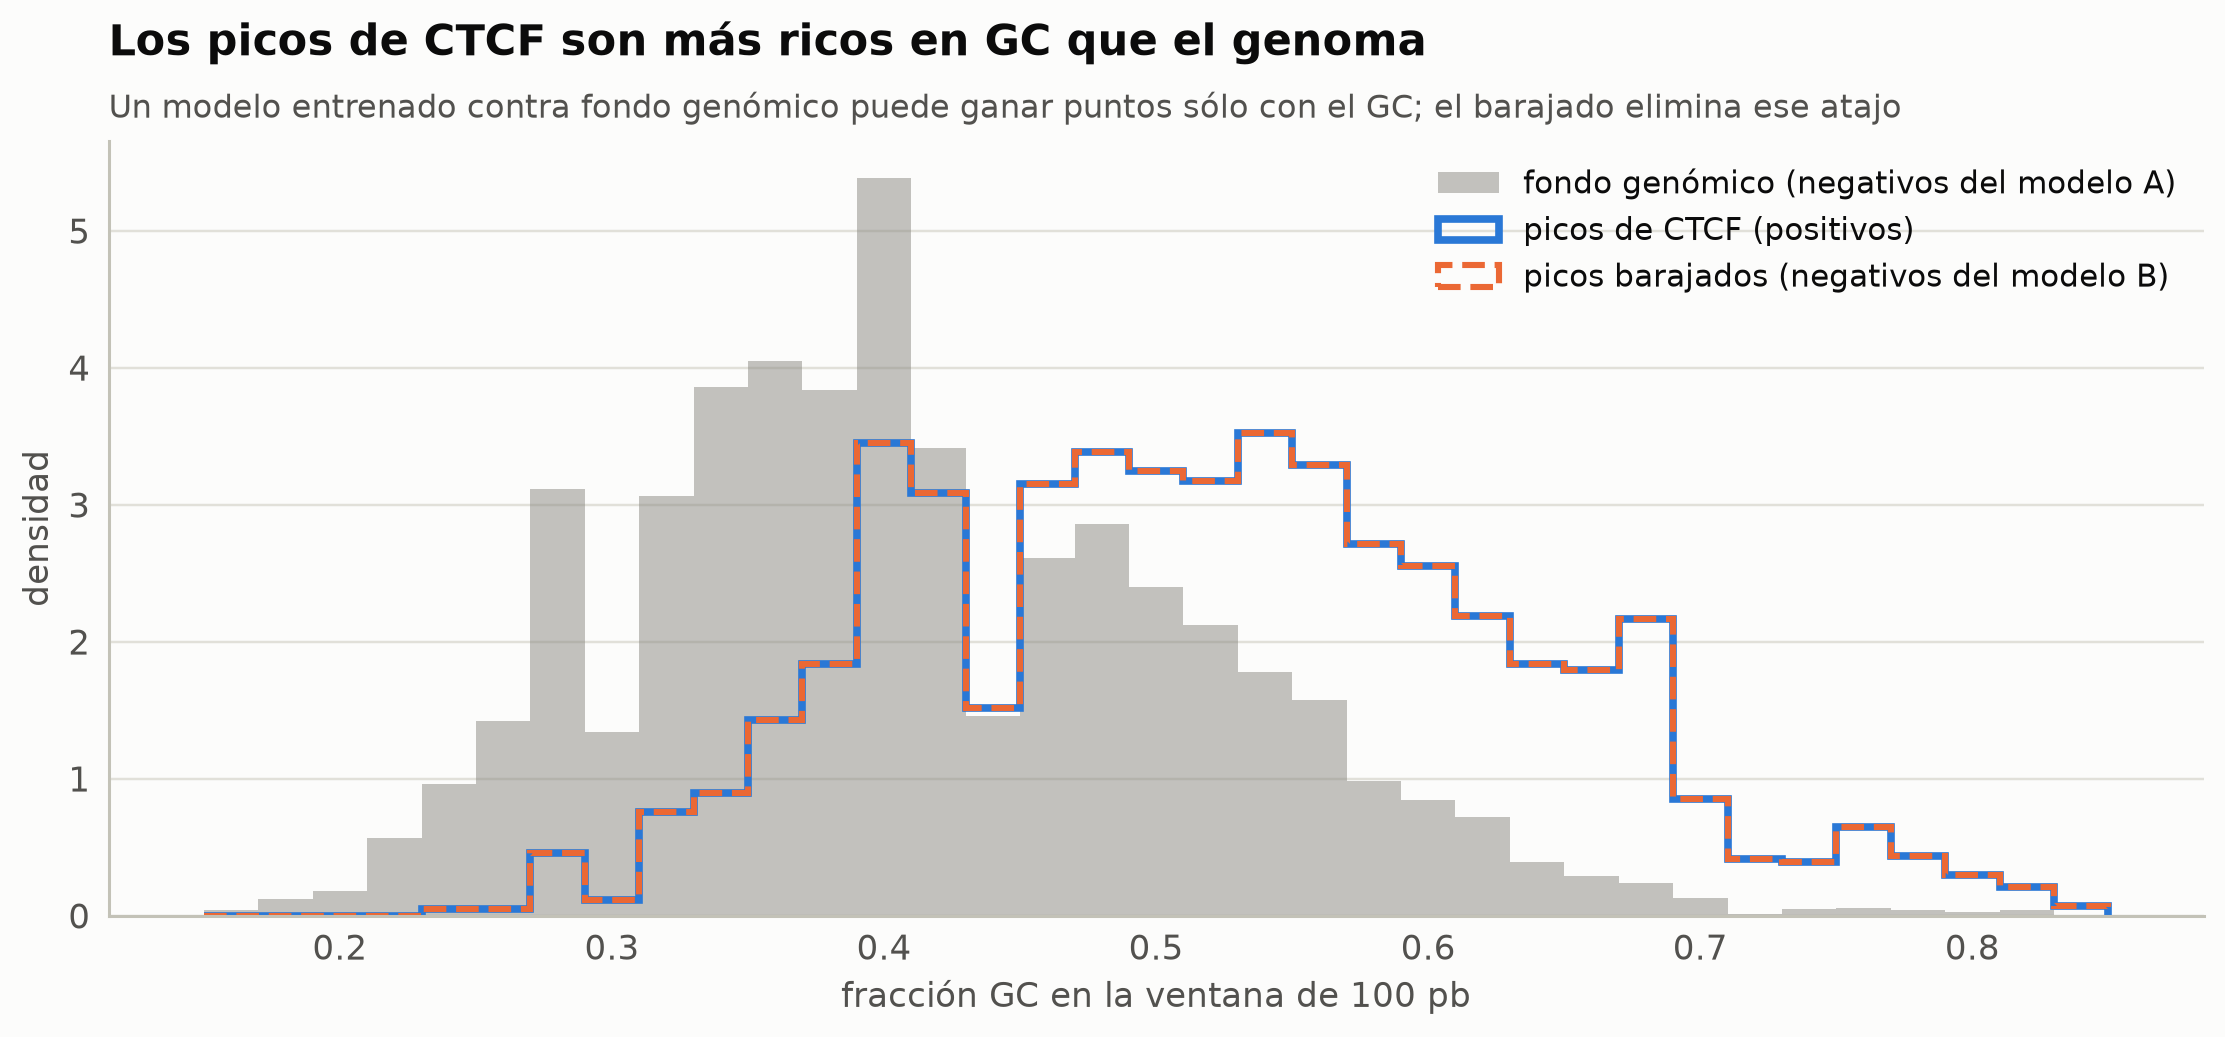

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.6))
bins = np.linspace(0.15, 0.85, 36)
ax.hist([gc(s) for s in bg_by["prueba"] + bg_by["entrenamiento"] + bg_by["validación"]], bins=bins, density=True,
        color=ec.MUTED, alpha=0.5, label="fondo genómico (negativos del modelo A)")
ax.hist([gc(s) for s in subset(pos_rows, "entrenamiento")], bins=bins, density=True, histtype="step", lw=2.5,
        color=ec.BLUE, label="picos de CTCF (positivos)")
ax.hist([gc(s) for s in subset(shuf_rows, "entrenamiento")], bins=bins, density=True, histtype="step", lw=2, ls="--",
        color=ec.ORANGE, label="picos barajados (negativos del modelo B)")
ax.set_xlabel("fracción GC en la ventana de 100 pb"); ax.set_ylabel("densidad")
ax.legend(loc="upper right", frameon=False)
ec.title(ax, "Los picos de CTCF son más ricos en GC que el genoma",
         "Un modelo entrenado contra fondo genómico puede ganar puntos sólo con el GC; el barajado elimina ese atajo")
plt.show()

> 🔎 **Qué observamos.** Los picos tienen de media unos 11 puntos más de GC que el fondo genómico; los picos barajados
> tienen, por construcción, **exactamente** el mismo GC que los picos. En la lección 17.1 vimos que el GC **solo** ya daba
> un AUROC de 0,76 contra el fondo: un atajo tentador para cualquier clasificador.

### 9.2 Entrenar los dos modelos

Usamos la misma arquitectura del libro, pero con filtros de **19 pb** (la longitud de MA0139.1) y un pequeño
**decaimiento de pesos** (`weight_decay`, regularización $L_2$, el $\lambda\,\Omega(\boldsymbol\theta)$ de la lección
17.1) porque aquí hay pocos datos. Cada modelo entrena 20 épocas en unos segundos en CPU.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué modelo tendrá **mejor** AUROC contra el fondo genómico? ¿Y cuál perderá más
> cuando lo evaluemos contra picos barajados?

In [25]:
def train_model(Xtr, ytr, Xva, yva, epochs=20, seed=0, width=19, nf=8):
    torch.manual_seed(seed)
    g = np.random.default_rng(seed)
    model = CNN(nf=nf, k=width)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-3)
    h = []
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.tensor(g.permutation(len(ytr)))
        for b in range(0, len(perm), 64):
            ib = perm[b:b + 64]
            opt.zero_grad(); lossf(model(Xtr[ib]), ytr[ib]).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            pv = model(Xva)
            h.append((ep, lossf(model(Xtr), ytr).item(), lossf(pv, yva).item(), roc_auc_score(yva.numpy(), pv.numpy())))
    return model, pd.DataFrame(h, columns=["epoca", "train", "val", "auroc_val"])

models_ctcf, hists_ctcf = {}, {}
t0 = time.perf_counter()
for name, ((Xtr, ytr), (Xva, yva)) in data.items():
    models_ctcf[name], hists_ctcf[name] = train_model(Xtr, ytr, Xva, yva)
    print(f"Modelo {name}: pérdida final entr./val. = {hists_ctcf[name].train.iloc[-1]:.3f} / "
          f"{hists_ctcf[name].val.iloc[-1]:.3f} · AUROC val = {hists_ctcf[name].auroc_val.iloc[-1]:.3f}")
print(f"({time.perf_counter() - t0:.0f} s para los dos modelos)")

rows, scores = [], {}
for name, model in models_ctcf.items():
    for tname, (X, y) in test_sets.items():
        with torch.no_grad():
            sc = model(X).numpy()
        scores[(name, tname)] = (y.numpy(), sc)
        rows.append(dict(modelo=name, negativos_de_prueba=tname, AUROC=roc_auc_score(y.numpy(), sc)))
for tname, (X, y) in test_sets.items():        # referencia: el GC como único "predictor"
    gcs = X[:, [1, 2], :].sum(1).mean(1).numpy()
    scores[("sólo GC", tname)] = (y.numpy(), gcs)
    rows.append(dict(modelo="sólo GC (referencia)", negativos_de_prueba=tname, AUROC=roc_auc_score(y.numpy(), gcs)))
auc_tab = pd.DataFrame(rows).pivot(index="modelo", columns="negativos_de_prueba", values="AUROC")
auc_tab.round(3)

Modelo A (fondo genómico): pérdida final entr./val. = 0.188 / 0.276 · AUROC val = 0.950


Modelo B (dinucleótidos barajados): pérdida final entr./val. = 0.267 / 0.370 · AUROC val = 0.908
(5 s para los dos modelos)


negativos_de_prueba,dinucleótidos barajados,fondo genómico
modelo,,
A (fondo genómico),0.861,0.955
B (dinucleótidos barajados),0.882,0.897
sólo GC (referencia),0.500,0.776


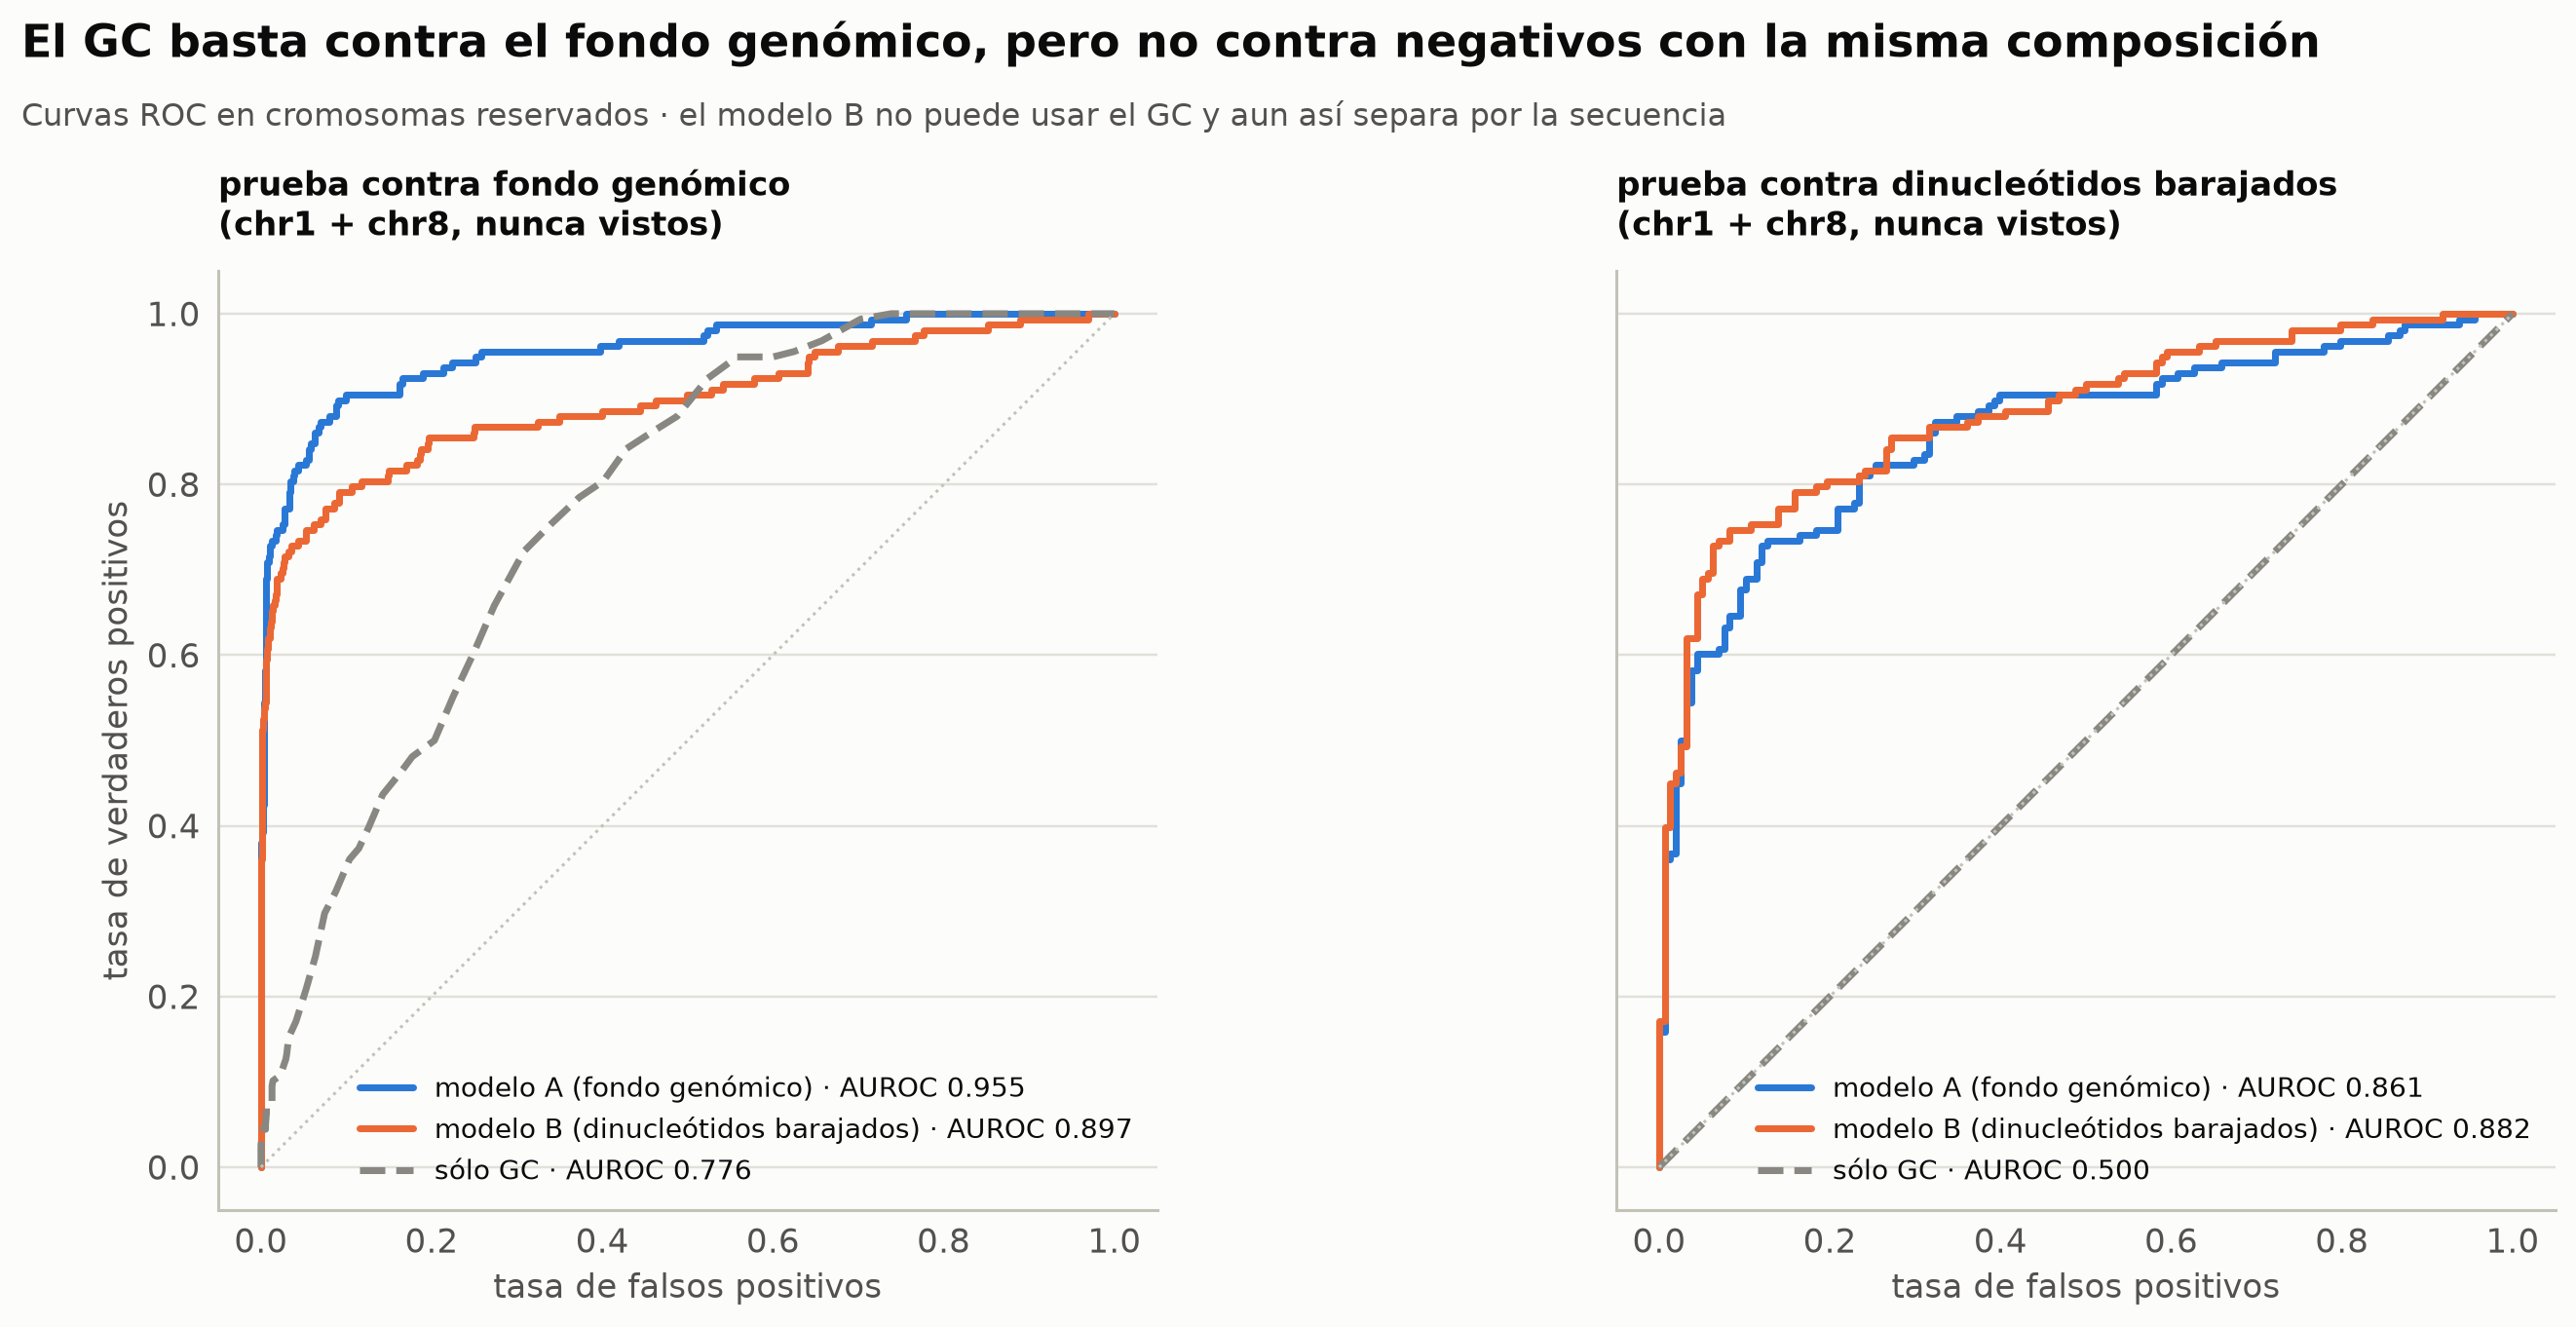

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True)
styles = {"A (fondo genómico)": (ec.BLUE, "-"), "B (dinucleótidos barajados)": (ec.ORANGE, "-"), "sólo GC": (ec.MUTED, "--")}
for ax, tname in zip(axes, test_sets):
    for name, (col, ls) in styles.items():
        y_, s_ = scores[(name, tname)]
        fpr, tpr, _ = roc_curve(y_, s_)
        lab = name if name == "sólo GC" else "modelo " + name
        ax.plot(fpr, tpr, color=col, ls=ls, lw=2.3, label=f"{lab} · AUROC {roc_auc_score(y_, s_):.3f}")
    ax.plot([0, 1], [0, 1], color=ec.BASELINE, lw=1, ls=":")
    ax.set_xlabel("tasa de falsos positivos"); ax.set_aspect("equal")
    ax.set_title(f"prueba contra {tname}\n(chr1 + chr8, nunca vistos)", fontsize=11, loc="left")
    ax.legend(loc="lower right", frameon=False, fontsize=9)
axes[0].set_ylabel("tasa de verdaderos positivos")
ec.fig_title(fig, "El GC basta contra el fondo genómico, pero no contra negativos con la misma composición",
             "Curvas ROC en cromosomas reservados · el modelo B no puede usar el GC y aun así separa por la secuencia")
plt.show()

> 🔎 **Qué observamos.** Contra el fondo genómico todo parece funcionar: incluso el GC **solo** alcanza un AUROC cercano a 0,78, y el
> modelo A supera al B. Pero cuando cambiamos los negativos de prueba por picos **barajados** (mismo GC), el GC cae al
> azar (0,5 por construcción) y el modelo A **pierde** varios puntos: parte de su "acierto" era el atajo del GC. El
> modelo B, entrenado ya contra negativos de igual composición, mantiene un rendimiento similar en ambas pruebas: lo que
> aprendió es **secuencia**. Como referencia sólo indicativa: el SVM con núcleo de espectro de la lección 17.1 alcanzaba
> un AUROC de 0,908 con $k=7$, pero con validación cruzada **aleatoria** de 5 bloques sobre 1 000 sitios frente a 1 000
> ventanas de fondo, mientras que aquí evaluamos en **cromosomas reservados** (chr1 y chr8: 158 sitios frente a 925
> fragmentos de fondo o a los sitios barajados). Una comparación más justa es la regresión logística de 6-mers de la
> 17.1 con partición **por cromosoma** (AUC 0,882). Una CNN de unos 600 parámetros llega a un nivel comparable y, sobre
> todo, es **interpretable** a través de sus filtros, como veremos ahora.

### 9.3 ¿Qué filtros aprendió? Comparación con JASPAR MA0139

Para cada filtro construimos su logo con las ventanas de máxima activación en los picos (la receta del apartado 6) y lo
comparamos con **MA0139.1** usando la similitud columna a columna de la lección 13.3 (suma de correlaciones de Pearson,
probando todos los desplazamientos y **las dos hebras**):

$$
S(\theta,\phi) \;=\; \max_{\text{hebra},\ \text{desplazamiento}}\ \sum_{k\in\text{solape}} \rho\bigl(\theta_{k,\cdot},\ \phi_{k+d,\cdot}\bigr),
$$

| Símbolo | Significado |
|---|---|
| $\theta,\ \phi$ | logo del filtro y matriz de JASPAR (W × 4, filas que suman 1) |
| $d$ | desplazamiento de una matriz respecto a la otra |
| $\rho$ | correlación de Pearson entre dos columnas (4 números); 1 si las preferencias coinciden |
| $S$ | similitud total: aproximadamente, "cuántas columnas coinciden bien" (máximo 19 aquí) |

In [27]:
ma = cached_json("jaspar_MA0139.1.json", "https://jaspar.elixir.no/api/v1/matrix/MA0139.1/?format=json")
cnt_ma = np.array([ma["pfm"][b] for b in BASES], float).T
theta_ma = (cnt_ma + 0.25) / (cnt_ma.sum(1, keepdims=True) + 1)
print(f"{ma['matrix_id']} · {ma['name']} · {int(cnt_ma[0].sum())} sitios · consenso {kmer(theta_ma)}")

rc_theta = lambda th: np.asarray(th)[::-1, ::-1]

def col_corr(a, b):
    a = a - a.mean(1, keepdims=True); b = b - b.mean(1, keepdims=True)
    den = np.sqrt((a ** 2).sum(1) * (b ** 2).sum(1))
    return np.where(den > 0, (a * b).sum(1) / np.where(den > 0, den, 1), 0.0)

def compare(th, ph, min_overlap=8):
    """Similitud tipo Tomtom (lección 13.3): mejor suma de correlaciones por columna sobre desplazamientos y hebras."""
    best = (-np.inf, 0, "+")
    for strand, P in (("+", ph), ("−", rc_theta(ph))):
        for d in range(-(len(P) - min_overlap), len(th) - min_overlap + 1):
            k = np.arange(max(0, d), min(len(th), d + len(P)))
            s = col_corr(th[k], P[k - d]).sum()
            if s > best[0]:
                best = (s, d, strand)
    return best

peak_centers = [s[200:300] for _, s in peaks]
X_centers = torch.tensor(np.stack([onehot(s) for s in peak_centers]))

def real_filter_logos(model, width=19):
    with torch.no_grad():
        act = torch.relu(model.conv(X_centers)).numpy()
    out = []
    for f in range(act.shape[1]):
        a = act[:, f, :]; thr = 0.5 * a.max(); cnt = np.ones((width, 4)) * 0.1; nw = 0
        for s, aa in zip(peak_centers, a):
            j = int(aa.argmax())
            if thr > 0 and aa[j] > thr:
                nw += 1
                for q, c in enumerate(s[j:j + width]):
                    cnt[q, BASES.index(c)] += 1
        out.append((cnt / cnt.sum(1, keepdims=True), nw))
    return out

filt_rows, logos_real = [], {}
for name, model in models_ctcf.items():
    logos_real[name] = real_filter_logos(model)
    w_out = model.fc.weight.detach().numpy()[0]
    for f, (pf, nw) in enumerate(logos_real[name]):
        S_, d_, st_ = compare(pf, theta_ma) if nw > 0 else (0.0, 0, "")
        filt_rows.append(dict(modelo=name[0], filtro=f, peso_salida=w_out[f], ventanas=nw, consenso=kmer(pf) if nw else "—",
                              S_vs_MA0139=S_, hebra=st_, desplazamiento=d_))
filt_tab = pd.DataFrame(filt_rows)
filt_tab.round(2)

MA0139.1 · CTCF · 913 sitios · consenso TGGCCACCAGGGGGCGCTA


,modelo,filtro,peso_salida,ventanas,consenso,S_vs_MA0139,hebra,desplazamiento
0,A,0,1.26,276,GCGCCACCTGGTGGCAGCA,14.12,+,0
1,A,1,1.41,268,AGCGCCCCCTAGTGGCCAG,17.71,−,-1
2,A,2,1.43,302,GCCACCTGGTGGCGCCATG,14.29,+,-2
3,A,3,1.48,107,GCGCCCACTAGAGGGCACT,14.69,+,1
4,A,4,-0.66,966,CGCGTGTAGCCGACATTAT,6.23,−,-6
5,A,5,1.32,250,ATTACCGCCAGCTGGCGGC,14.05,−,2
6,A,6,1.51,207,GCCACCAGGGGGCGCTGTT,16.53,+,-2
7,A,7,-0.74,931,GCCAAGAGTTTATCTACAC,4.00,−,-7
8,B,0,1.70,282,GCGCCCCCTAGTGGCCAGA,16.59,−,-2
9,B,1,0.93,431,ATTTTCCTTTATATTACAG,2.89,+,2


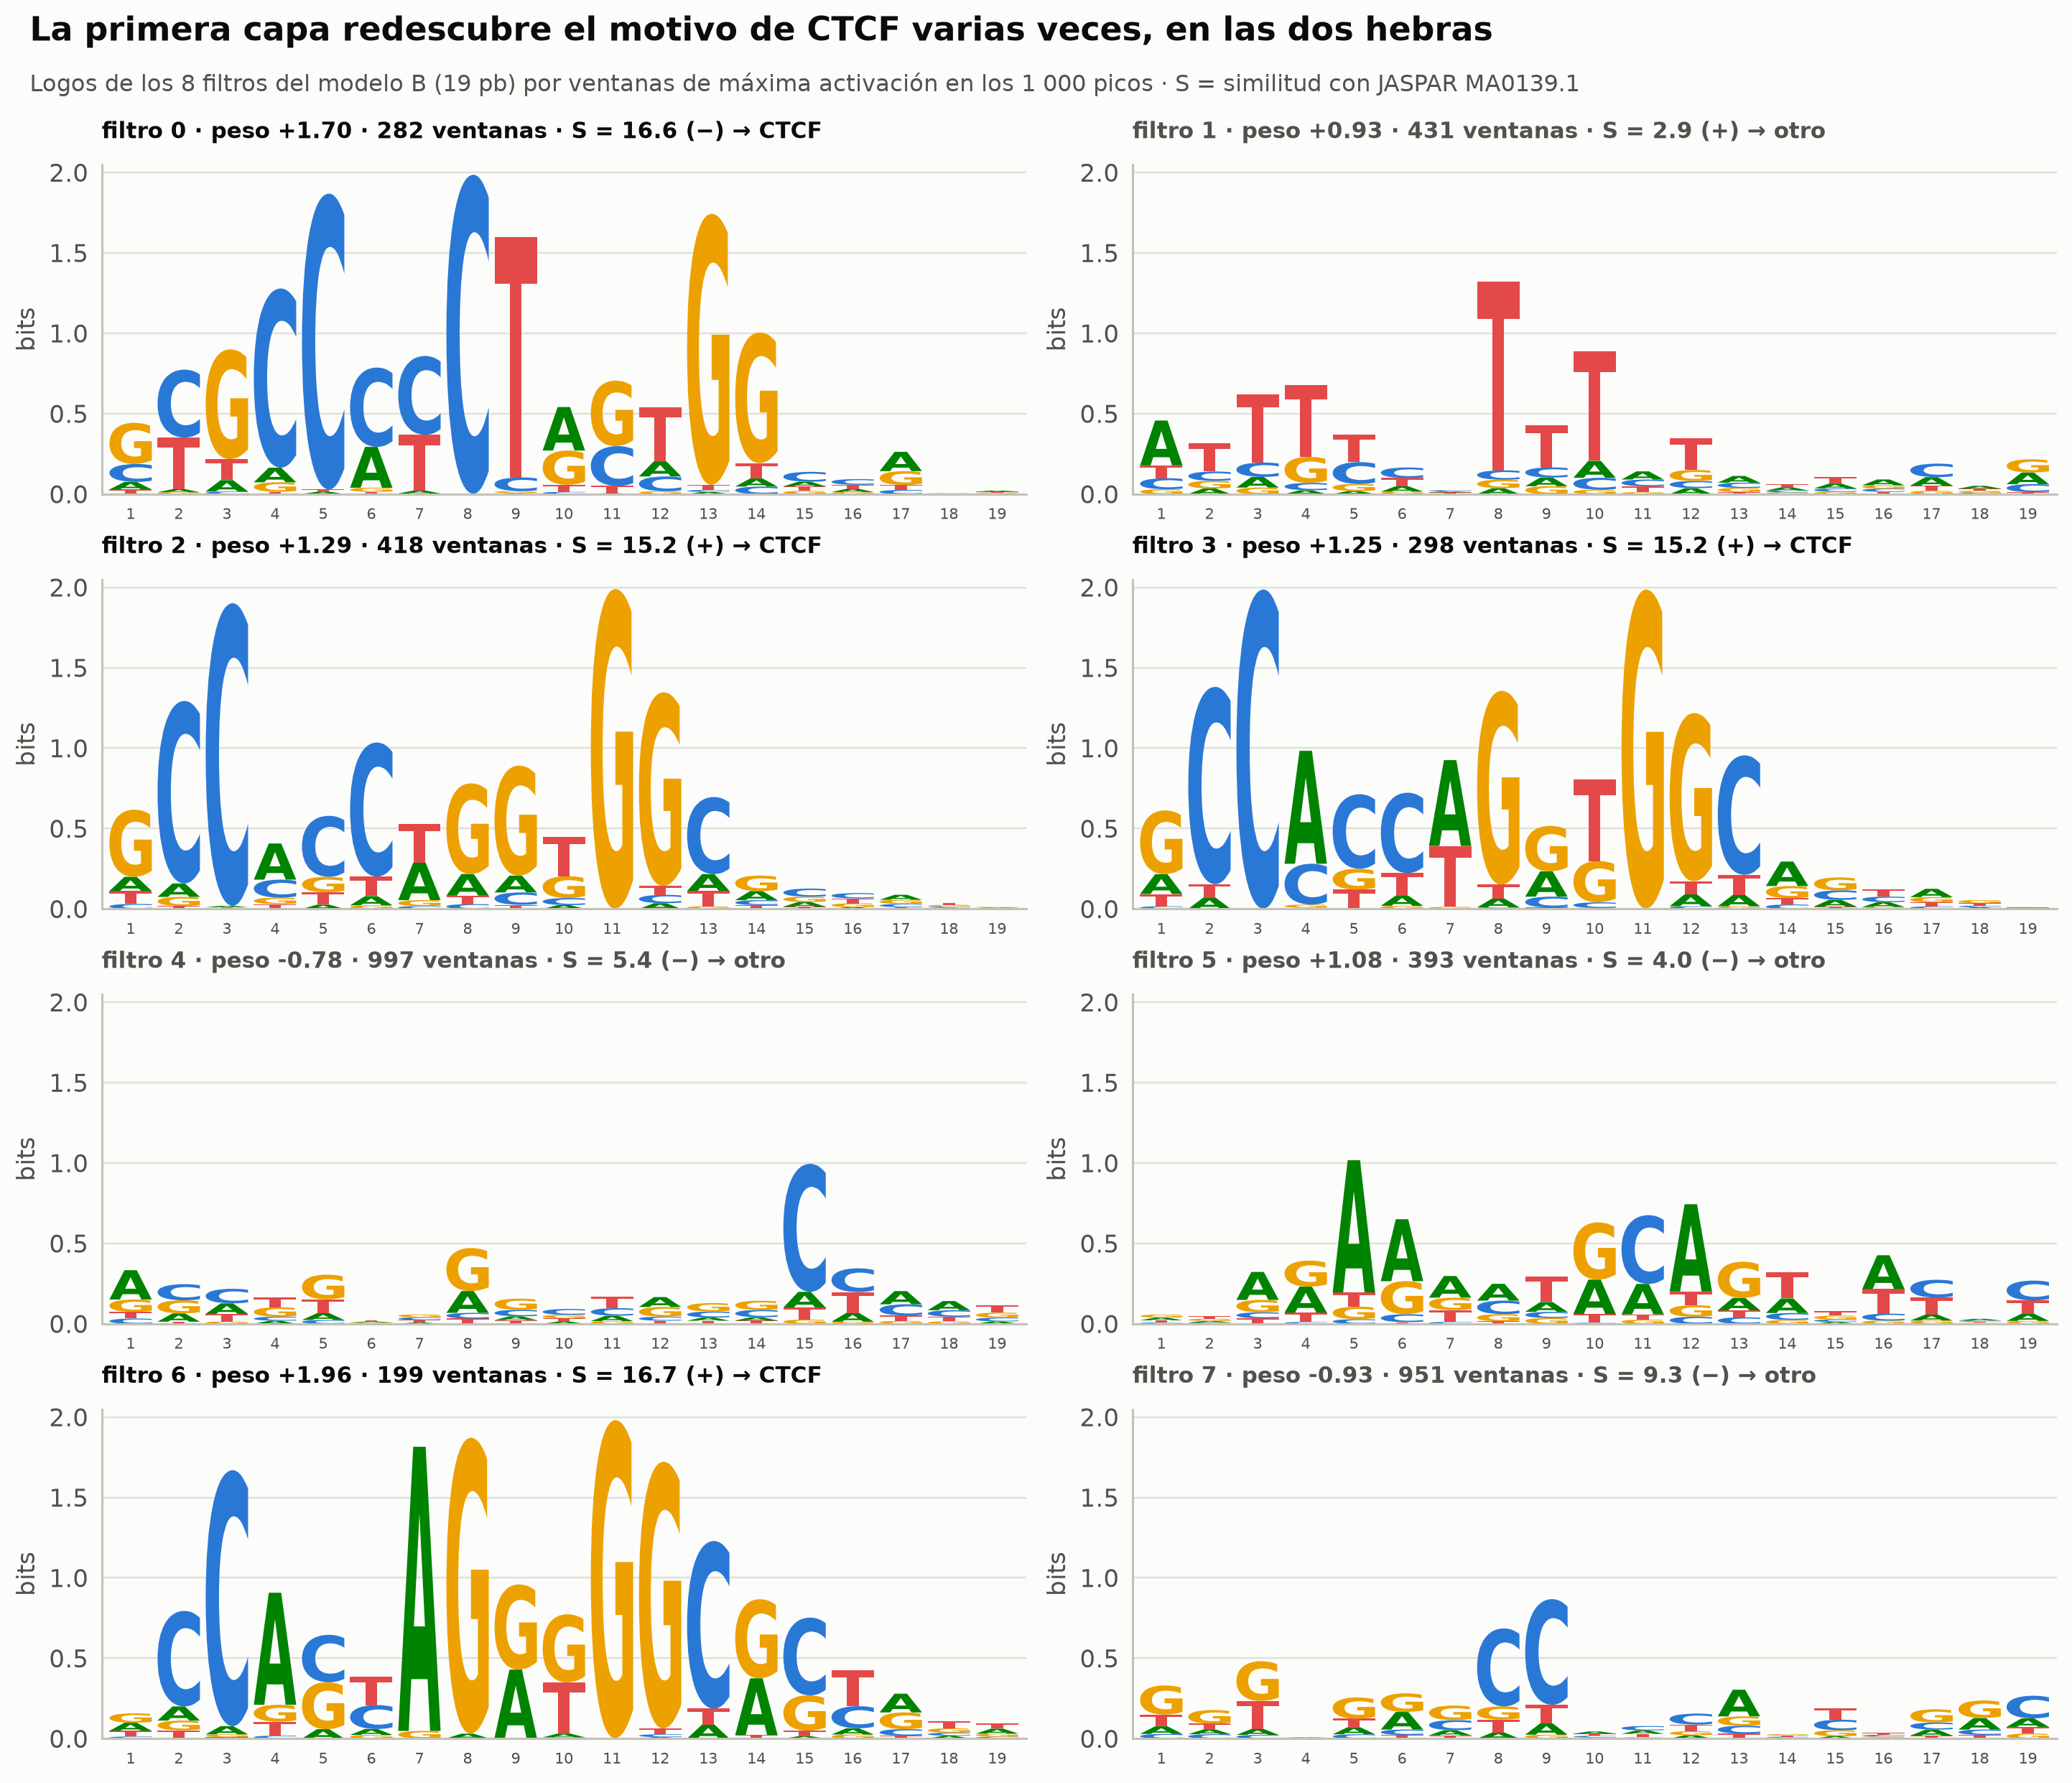

In [28]:
tabB = filt_tab[filt_tab.modelo == "B"].reset_index(drop=True)
fig, axes = plt.subplots(4, 2, figsize=(13, 10.5))
for ax, (_, r) in zip(axes.ravel(), tabB.iterrows()):
    pf, nw = logos_real["B (dinucleótidos barajados)"][int(r.filtro)]
    if nw == 0:
        ax.text(0.5, 0.5, f"filtro {int(r.filtro)}: inactivo (nunca supera el umbral)", ha="center", va="center",
                transform=ax.transAxes, color=ec.MUTED); ax.axis("off"); continue
    draw_logo(ax, pf, xlabel="")
    tag = "CTCF" if r.S_vs_MA0139 >= 12 else "otro"
    ax.set_title(f"filtro {int(r.filtro)} · peso {r.peso_salida:+.2f} · {nw} ventanas · S = {r.S_vs_MA0139:.1f} "
                 f"({r.hebra}) → {tag}", fontsize=10, loc="left", color=ec.INK if tag == "CTCF" else ec.INK_2)
    ax.tick_params(axis="x", labelsize=7)
ec.fig_title(fig, "La primera capa redescubre el motivo de CTCF varias veces, en las dos hebras",
             "Logos de los 8 filtros del modelo B (19 pb) por ventanas de máxima activación en los 1 000 picos · "
             "S = similitud con JASPAR MA0139.1")
plt.show()

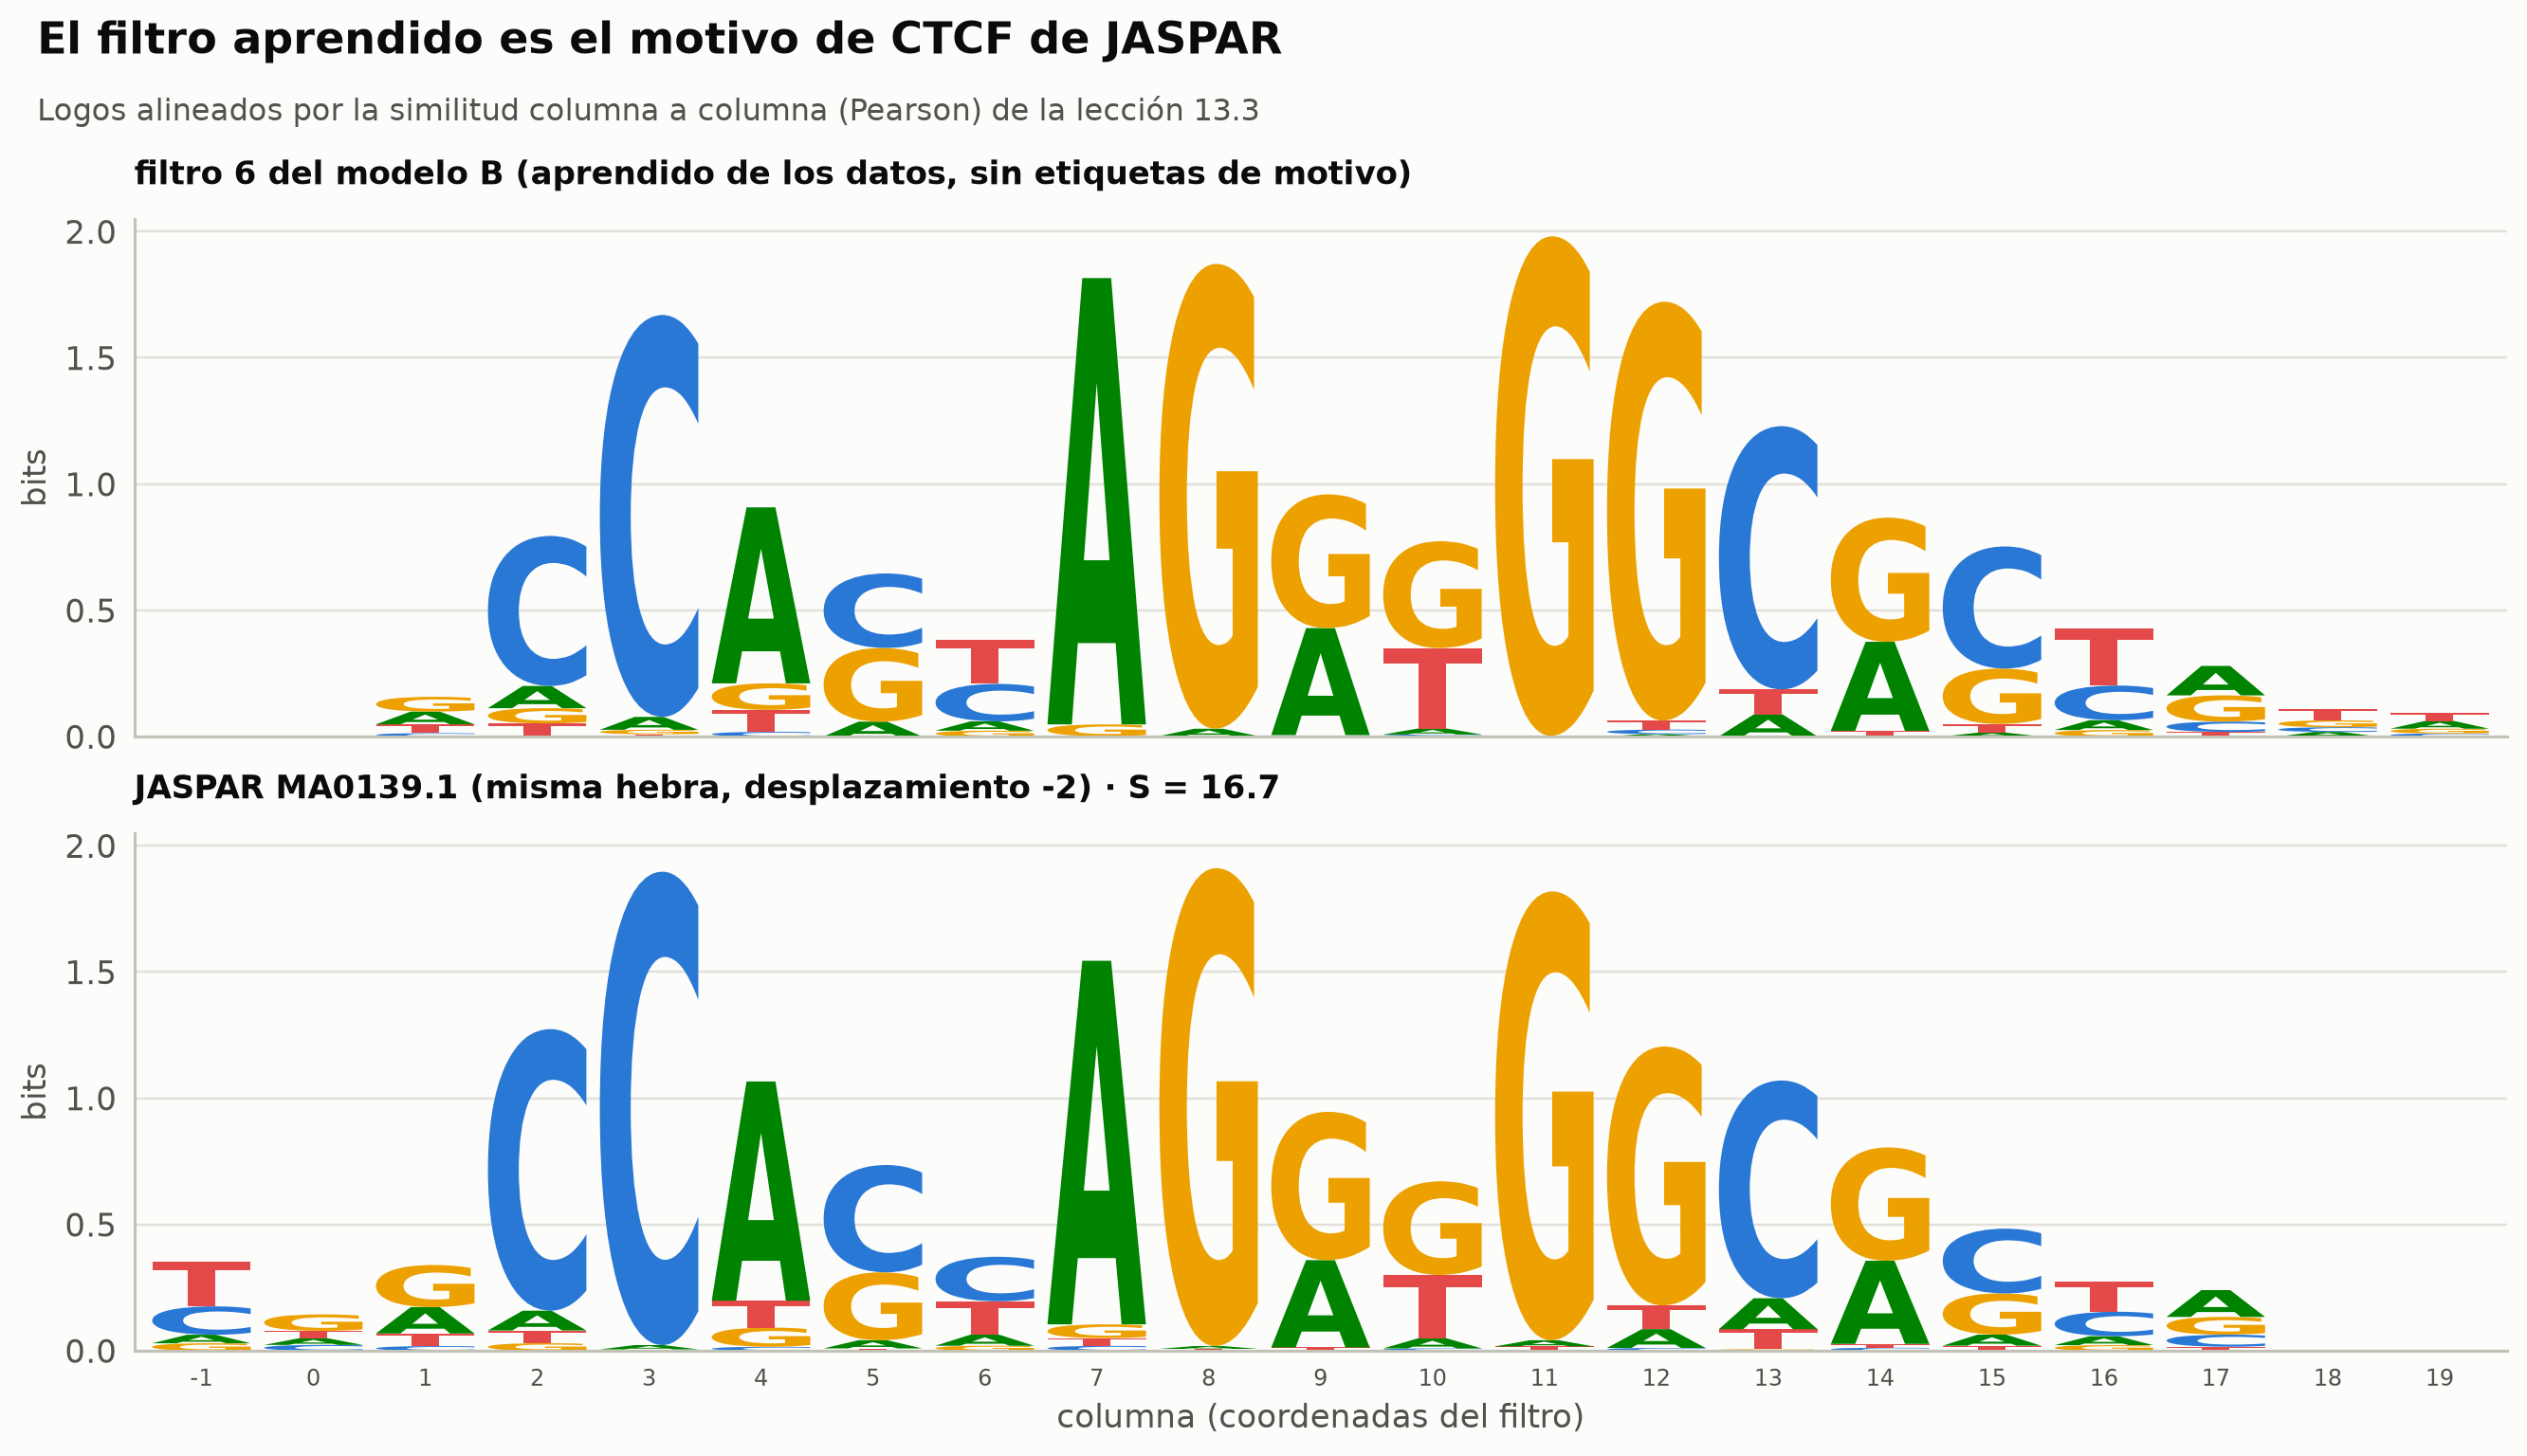

In [29]:
# El filtro más parecido a CTCF, alineado con MA0139.1 en su mejor hebra y desplazamiento
bestB = tabB.sort_values("S_vs_MA0139", ascending=False).iloc[0]
pf = logos_real["B (dinucleótidos barajados)"][int(bestB.filtro)][0]
S_, d_, st_ = compare(pf, theta_ma)
P = theta_ma if st_ == "+" else rc_theta(theta_ma)
lo, hi = min(0, d_), max(len(pf), d_ + len(P))
padm = lambda th, start: np.r_[np.full((start - lo, 4), 0.25), th, np.full((hi - start - len(th), 4), 0.25)]
fig, axes = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True)
draw_logo(axes[0], padm(pf, 0), xlabel="", first=lo + 1,
          title=f"filtro {int(bestB.filtro)} del modelo B (aprendido de los datos, sin etiquetas de motivo)")
draw_logo(axes[1], padm(P, d_), first=lo + 1, xlabel="columna (coordenadas del filtro)",
          title=f"JASPAR MA0139.1 ({'misma hebra' if st_ == '+' else 'reverso complementario'}, desplazamiento {d_:+d}) · S = {S_:.1f}")
for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
ec.fig_title(fig, "El filtro aprendido es el motivo de CTCF de JASPAR",
             "Logos alineados por la similitud columna a columna (Pearson) de la lección 13.3")
plt.show()

> 🔎 **Qué observamos.** Varios de los 8 filtros del modelo B son versiones del motivo de CTCF, unos en la hebra directa y
> otros en la complementaria (por eso el aumento con reverso complementario ayuda), con similitudes $S$ de 15 a 17 sobre
> un máximo de 19. El mejor, alineado con MA0139.1, reproduce el núcleo `CCAS…AGGGGGCG` que la lección 13.3 redescubrió
> con EM y Gibbs. Otros filtros, con $S$ bajo, capturan patrones ricos en A/T del entorno de los picos, y los de peso de
> salida **negativo** aprenden patrones típicos de los negativos barajados que **restan** evidencia. Ningún algoritmo de descubrimiento de motivos, ninguna
> alineación: sólo etiquetas "pico / no pico" y descenso de gradiente.

### 9.4 Saliencia y efecto de variantes en un pico real

Por último, aplicamos la saliencia y la mutagénesis *in silico* del apartado 8 a un pico real de la **prueba** (chr1 o
chr8), el de mayor puntuación del modelo B, y marcamos el mejor sitio de MA0139.1 encontrado por un escaneo clásico de
PWM. Es el uso de DeepSEA: estimar qué variantes de un paciente romperían un sitio de CTCF. Estas mutaciones importan en
clínica: se ha descrito que los sitios de unión de CTCF y cohesina acumulan mutaciones somáticas en varios tipos de
cáncer (Katainen et al., 2015), y romper una frontera de dominio puede activar un oncogén vecino: en los gliomas con
mutaciones de *IDH*, la hipermetilación de sitios de CTCF debilita una frontera y permite que un potenciador active
*PDGFRA* (Flavahan et al., 2016).

In [30]:
modelB = models_ctcf["B (dinucleótidos barajados)"]
Xt, yt = test_sets["dinucleótidos barajados"]
with torch.no_grad():
    sc_t = modelB(Xt).numpy()
k_best = int(np.argmax(np.where(yt.numpy() == 1, sc_t, -np.inf)))
seq_r = test_pos[k_best]
xr = Xt[k_best:k_best + 1].clone().requires_grad_(True)
modelB(xr).sum().backward()
sal_r = (xr.grad * xr).detach().numpy()[0].sum(0)

# escaneo clásico con la PWM de MA0139.1 (log-probabilidades frente a fondo uniforme) en las dos hebras
pwm = np.log2(theta_ma / 0.25)
def pwm_scan(s, M):
    Xo = onehot(s)
    return np.array([(M.T * Xo[:, i:i + len(M)]).sum() for i in range(len(s) - len(M) + 1)])
fw, rv = pwm_scan(seq_r, pwm), pwm_scan(seq_r, rc_theta(pwm))
best_i = int(np.argmax(np.maximum(fw, rv))); strand = "+" if fw[best_i] >= rv[best_i] else "−"
site = seq_r[best_i:best_i + 19]
print(f"pico de prueba con logit {sc_t[k_best]:.2f} · mejor sitio MA0139.1 en {best_i + 1}–{best_i + 19} "
      f"(hebra {strand}): {site} · puntuación {max(fw[best_i], rv[best_i]):.1f} bits")
frac_r = np.abs(sal_r[best_i:best_i + 19]).sum() / np.abs(sal_r).sum()
print(f"fracción de |s| dentro del sitio de CTCF: {frac_r:.2f} (el sitio es el 19 % de la secuencia)")

# ISM: Δ = f(alt) − f(ref) para las 300 variantes de un solo nucleótido
muts_r = [(p, b, seq_r[:p] + b + seq_r[p + 1:]) for p in range(100) for b in BASES if b != seq_r[p]]
with torch.no_grad():
    f0 = modelB(Xt[k_best:k_best + 1]).item()
    fa = modelB(torch.tensor(np.stack([onehot(m[2]) for m in muts_r]))).numpy()
ism_r = np.zeros((4, 100))
for (p, b, _), v in zip(muts_r, fa):
    ism_r[BASES.index(b), p] = v - f0
wp = np.unravel_index(ism_r.argmin(), ism_r.shape)
inside = best_i <= wp[1] < best_i + 19
print(f"variante más dañina: posición {wp[1] + 1} {seq_r[wp[1]]}>{BASES[wp[0]]} · Δ = {ism_r.min():.2f} "
      f"({'dentro' if inside else 'fuera'} del sitio de CTCF)")

pico de prueba con logit 8.14 · mejor sitio MA0139.1 en 51–69 (hebra +): ACTCCACCAGGGGGCGCTG · puntuación 19.9 bits
fracción de |s| dentro del sitio de CTCF: 0.59 (el sitio es el 19 % de la secuencia)
variante más dañina: posición 63 G>C · Δ = -4.37 (dentro del sitio de CTCF)


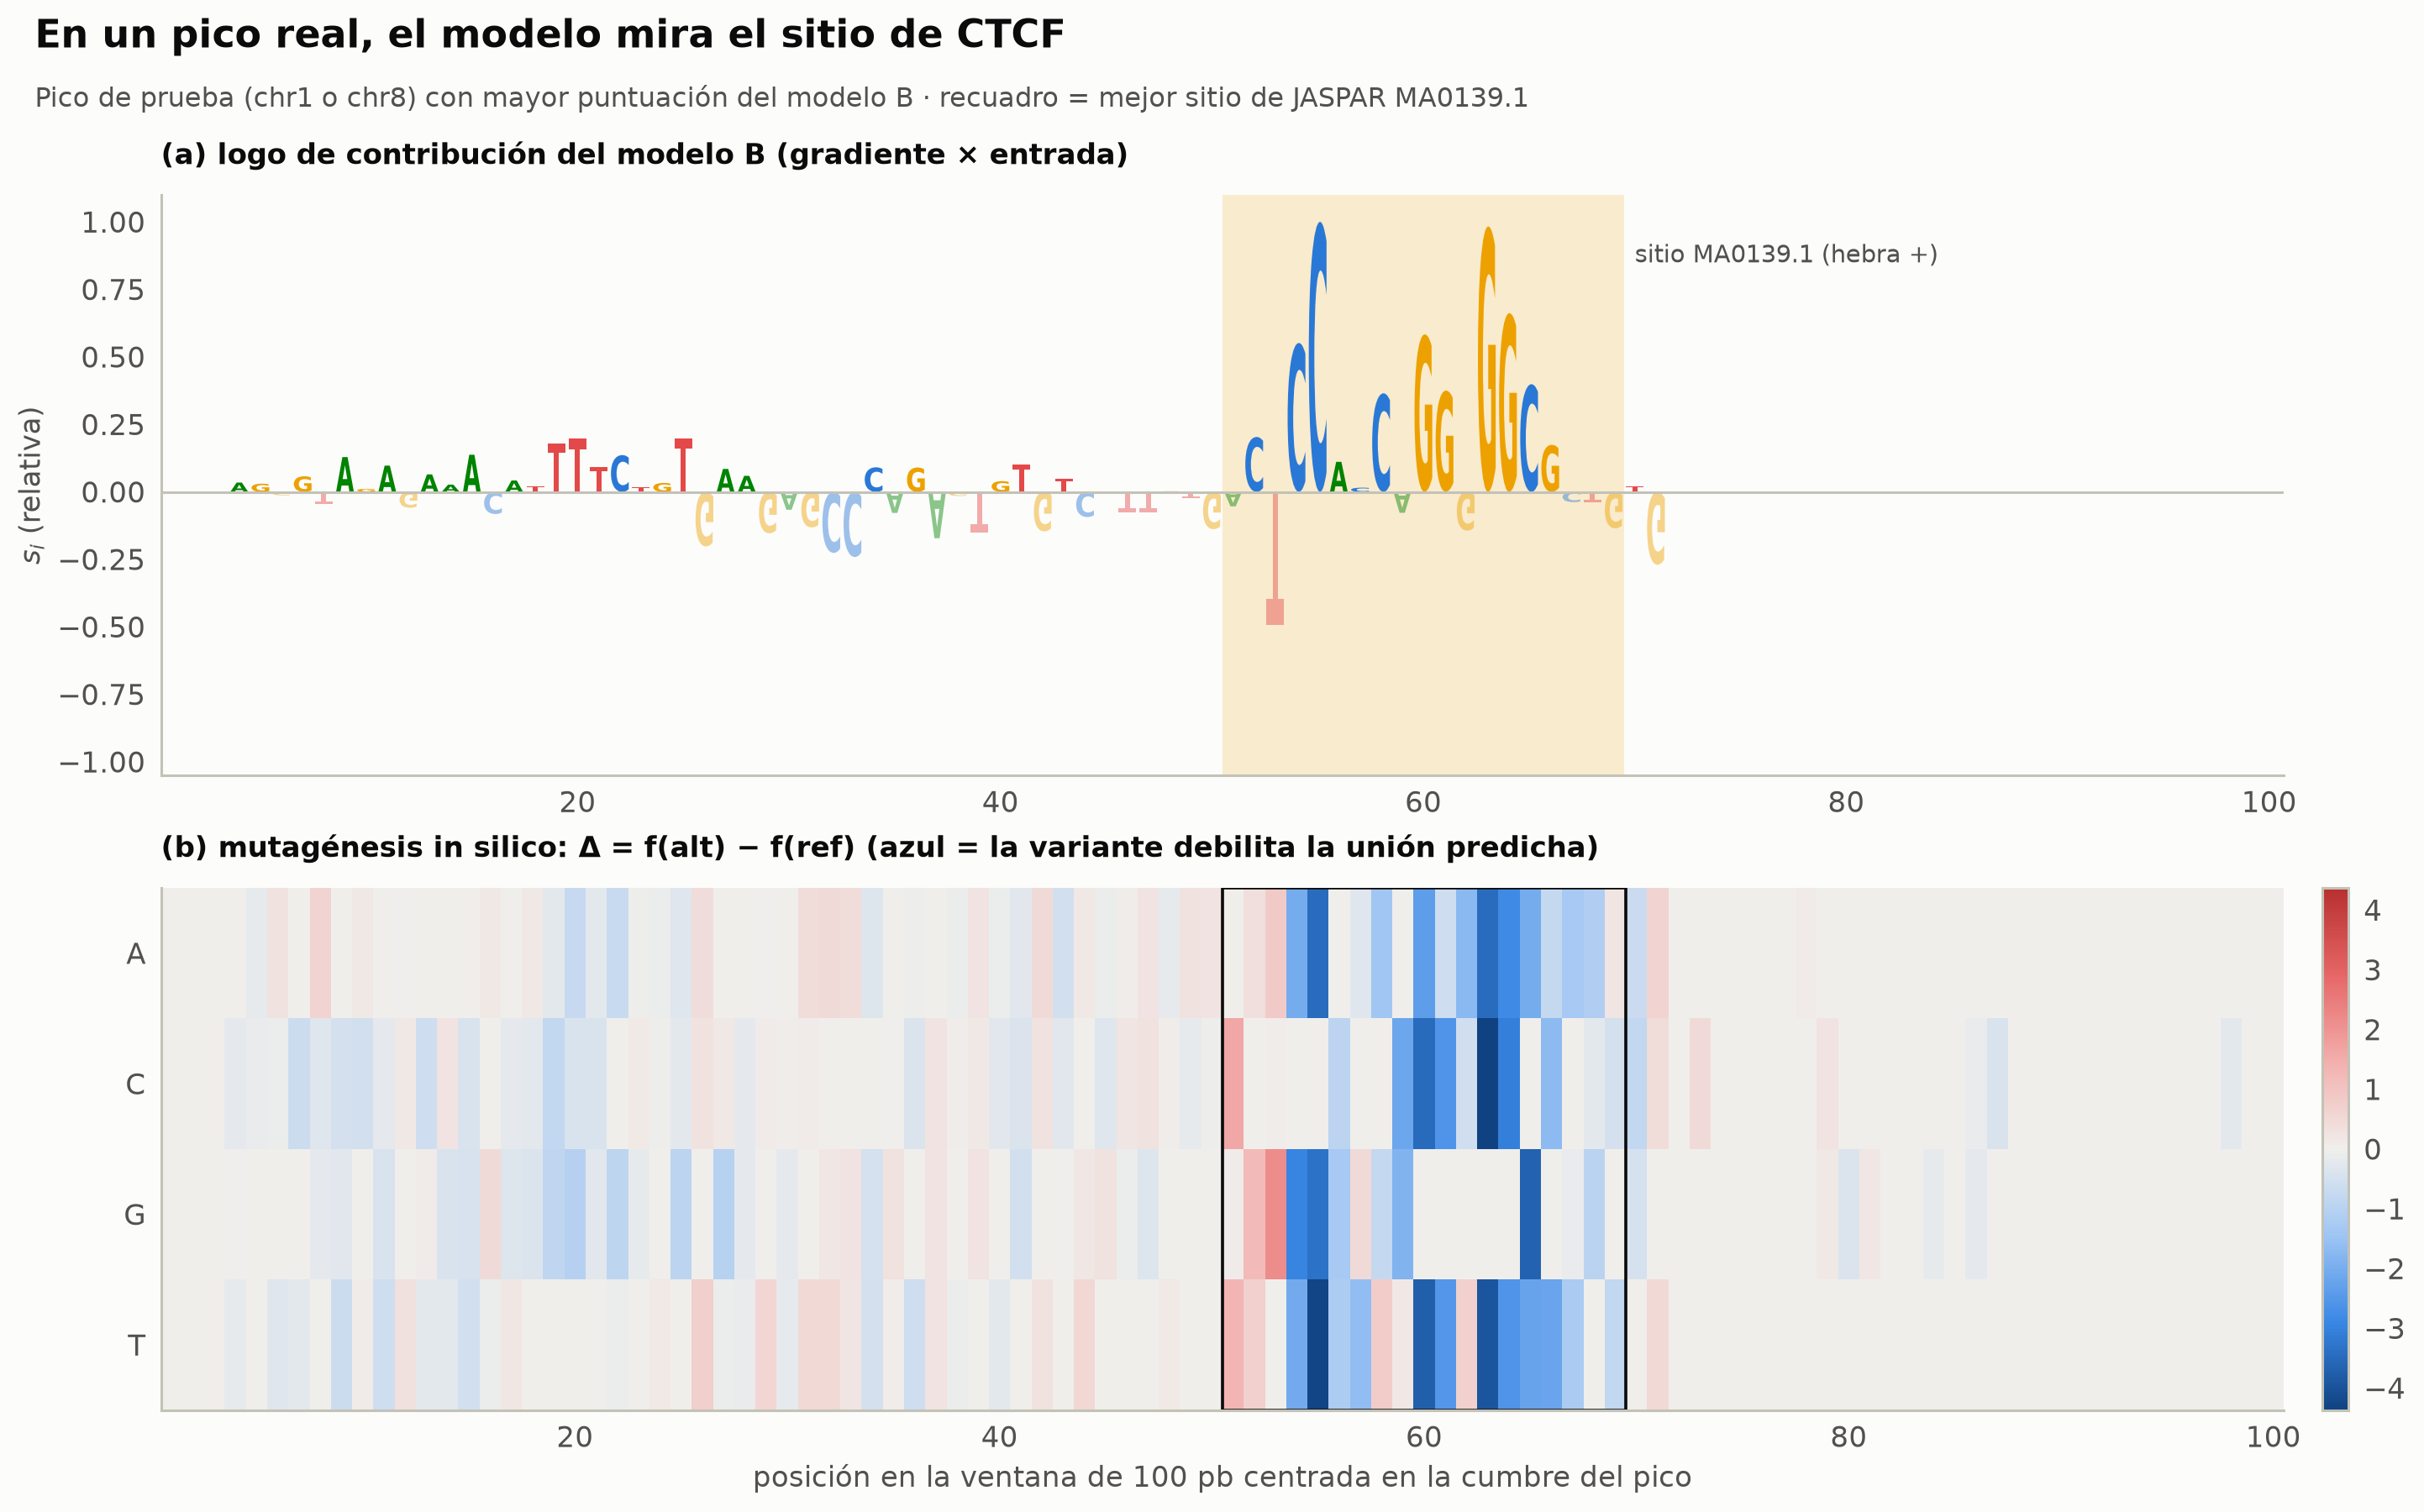

In [31]:
fig = plt.figure(figsize=(13, 7.4))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 0.9])
ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
vmax = np.abs(sal_r).max()
ax1.axvspan(best_i + 0.5, best_i + 19.5, color=ec.YELLOW, alpha=0.18, lw=0)
for k in range(100):
    c = seq_r[k]; v = sal_r[k] / vmax
    draw_letter(ax1, c, k + 1 - 0.42, 0, 0.84, v, ec.NUC_COLORS[c], alpha=1.0 if v > 0 else 0.45)
ax1.axhline(0, color=ec.BASELINE, lw=1)
ax1.text(best_i + 20, 0.85, f"sitio MA0139.1 (hebra {strand})", fontsize=9.5, color=ec.INK_2)
ax1.set_xlim(0.3, 100.7); ax1.set_ylim(-1.05, 1.1); ax1.set_ylabel("$s_i$ (relativa)"); ax1.grid(False)
ax1.set_title("(a) logo de contribución del modelo B (gradiente × entrada)", fontsize=11, loc="left")
vm = np.abs(ism_r).max()
im = ax2.imshow(ism_r, cmap=ec.CMAP_DIV, vmin=-vm, vmax=vm, aspect="auto", extent=(0.5, 100.5, 3.5, -0.5))
ax2.add_patch(Rectangle((best_i + 0.5, -0.5), 19, 4, fill=False, ec=ec.INK, lw=1.2))
ax2.set_yticks(range(4)); ax2.set_yticklabels(list(BASES)); ax2.grid(False)
ax2.set_xlabel("posición en la ventana de 100 pb centrada en la cumbre del pico")
ax2.set_title("(b) mutagénesis in silico: Δ = f(alt) − f(ref) (azul = la variante debilita la unión predicha)",
              fontsize=11, loc="left")
plt.colorbar(im, ax=ax2, fraction=0.03, pad=0.01)
ec.fig_title(fig, "En un pico real, el modelo mira el sitio de CTCF",
             f"Pico de prueba ({'chr1 o chr8'}) con mayor puntuación del modelo B · recuadro = mejor sitio de JASPAR MA0139.1")
plt.show()

> 🔎 **Qué observamos.** La contribución se concentra en el sitio que el escaneo clásico con MA0139.1 señala de forma
> independiente, y las variantes más dañinas (azul intenso) caen en las posiciones más informativas del motivo, las
> `G` del núcleo `…AGGGGGCG…` (o sus complementarias). Fuera del sitio casi nada importa. Esta es, en miniatura, la
> estrategia de DeepSEA y Basset para priorizar variantes no codificantes: $\Delta_t(v)$ grande y negativa dentro de un
> sitio de unión es una hipótesis concreta que se puede validar con un ensayo de reportero o con edición genómica.
>
> Observe también las posiciones con saliencia y $\Delta$ **exactamente cero** (a la derecha del sitio): el
> *max-pooling* sólo deja pasar el error por la ventana ganadora de cada filtro, así que las bases que no caen en
> ninguna ventana ganadora no influyen en absoluto en la salida. Es una propiedad de la arquitectura, no de la biología.

> ✅ **Compruebe su comprensión.** Si evaluáramos el modelo A **sólo** contra el fondo genómico, ¿qué conclusión
> equivocada podríamos sacar? *(Que es el mejor modelo, cuando parte de su ventaja es el contenido de GC de los picos: un
> atajo que no sirve para distinguir un sitio de CTCF de otra región rica en GC, como una isla CpG de un promotor.)*

## 10. 🏋️ Ejercicios

**Ejercicio 1 (el sesgo como umbral).** Con el filtro `TGA` del apartado 4.3 y sesgo $b=-3$, ¿qué activaciones produce
sobre `CGTGACTCATGCAAGT`? ¿Cuántas ventanas se encienden y por qué es un caso "frontera"? Compruébelo con `filter_track`.

**Ejercicio 2 (variantes en el sitio AP-1).** En la secuencia de prueba del apartado 8 (`s0`), use la matriz `ism` para
dar $\Delta$ de (a) cambiar la base degenerada del sitio (`G`→`C`), (b) cambiar la primera `T` del sitio por `C`.
Explique la diferencia con la PWM plantada.

**Ejercicio 3 (¿cuánto pesa el GC en el modelo A?).** Evalúe los dos modelos de CTCF sobre los fragmentos de **fondo**
de la prueba y calcule la correlación de Spearman entre su *logit* y el GC de cada fragmento. ¿Cuál depende más del GC?

**Ejercicio 4 (parada temprana).** Con la tabla `hist` del experimento del libro, ¿en qué época habría parado un
criterio de "mínima pérdida de validación"? ¿Y uno con paciencia de 5 épocas (parar si no mejora en 5 épocas
seguidas)? ¿Cuántas épocas de cómputo ahorra?

**Ejercicio 5 (escala de DeepSEA).** La primera capa de DeepSEA tiene 320 filtros de ancho 8 sobre 4 canales. ¿Cuántos
parámetros tiene esa capa? ¿Cuántas veces más que toda nuestra red de 369 parámetros? Y con $w=3$, ¿cuántas capas
dilatadas ($d_l=2^{l-1}$) harían falta para ver 1 kb?

In [32]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
h3 = filter_track(seq_fig, -3)
print("h con b = −3:", h3.tolist())
print("ventanas encendidas:", [(i + 1, seq_fig[i:i + 3], v) for i, v in enumerate(h3) if v > 0])
# Con b = −3, una ventana con una discrepancia suma 2 + 2 − 1 = 3 → ReLU(0) = 0: justo en el umbral.
# Sólo TGA (6 − 3 = 3) se enciende; las ventanas a una discrepancia quedan exactamente en 0 (frontera de la ReLU).

h con b = −3: [0.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
ventanas encendidas: [(3, 'TGA', np.float32(3.0))]


In [33]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
p_deg, p_first = at0 + 3, at0            # posiciones (0-based) de la S degenerada y de la primera T del sitio
print(f"sitio: {s0[at0:at0 + 7]} · base degenerada = {s0[p_deg]}")
print(f"(a) {s0[p_deg]}>C en la posición {p_deg + 1}: Δ = {ism[BASES.index('C'), p_deg]:+.2f}")
print(f"(b) T>C en la posición {p_first + 1}: Δ = {ism[BASES.index('C'), p_first]:+.2f}")
# La PWM plantada da 0,47 a C y a G en la posición degenerada: cambiar G por C no altera la probabilidad del sitio,
# y la red lo aprendió (Δ pequeño). En cambio, la T inicial tiene probabilidad 0,91 frente a 0,03 de C: la mutación
# destruye el sitio y el logit cae con fuerza (Δ ≈ −3 frente a Δ ≈ −0,3).

sitio: TGAGTCA · base degenerada = G
(a) G>C en la posición 40: Δ = -0.27
(b) T>C en la posición 37: Δ = -3.02


In [34]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
from scipy.stats import spearmanr
Xbg = torch.tensor(np.stack([onehot(s) for s in bg_by["prueba"]]))
gc_bg = np.array([gc(s) for s in bg_by["prueba"]])
for name, model in models_ctcf.items():
    with torch.no_grad():
        lg = model(Xbg).numpy()
    rho, p = spearmanr(lg, gc_bg)
    print(f"modelo {name}: Spearman(logit, GC) en {len(gc_bg)} fragmentos de fondo = {rho:.2f}")
# El modelo A, entrenado contra fondo pobre en GC, sube su puntuación con el GC mucho más que el B:
# ha incorporado el atajo de composición además del motivo.

modelo A (fondo genómico): Spearman(logit, GC) en 925 fragmentos de fondo = 0.59
modelo B (dinucleótidos barajados): Spearman(logit, GC) en 925 fragmentos de fondo = -0.24


In [35]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
best = int(hist.epoca[hist.val.idxmin()])
best_val, stop, wait = np.inf, None, 0
for e, v in zip(hist.epoca, hist.val):
    if v < best_val - 1e-4:
        best_val, wait = v, 0
    else:
        wait += 1
        if wait == 5:
            stop = int(e); break
print(f"mínima pérdida de validación en la época {best} ({hist.val.min():.3f})")
print(f"con paciencia 5 se para en la época {stop} → ahorra {40 - stop} de 40 épocas")

mínima pérdida de validación en la época 13 (0.389)
con paciencia 5 se para en la época 18 → ahorra 22 de 40 épocas


In [36]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
p_deepsea1 = 320 * (4 * 8 + 1)
print(f"primera capa de DeepSEA: 320 × (4·8 + 1) = {p_deepsea1} parámetros ≈ {p_deepsea1 / 369:.0f} veces nuestra red")
D = next(D for D in range(1, 30) if receptive_field(3, [2 ** (l - 1) for l in range(1, D + 1)]) >= 1000)
print(f"w = 3: hacen falta D = {D} capas dilatadas (R = {receptive_field(3, [2 ** (l - 1) for l in range(1, D + 1)])} pb)")

primera capa de DeepSEA: 320 × (4·8 + 1) = 10560 parámetros ≈ 29 veces nuestra red
w = 3: hacen falta D = 9 capas dilatadas (R = 1023 pb)


## 📌 Resumen

* Una **red multicapa** compone capas $\mathbf{a}^{(l)}=\varphi(W^{(l)}\mathbf{a}^{(l-1)}+\mathbf{b}^{(l)})$; sin la no
  linealidad $\varphi$ todo colapsa en una sola capa lineal.
* La **retropropagación** es la regla de la cadena aplicada hacia atrás:
  $\boldsymbol\delta^{(l)}=(W^{(l+1)\top}\boldsymbol\delta^{(l+1)})\odot\varphi'(\mathbf{z}^{(l)})$. Da **todos** los
  gradientes al coste de dos pases, frente a dos evaluaciones **por peso** de las diferencias finitas.
* Sobre ADN *one-hot*, un **filtro convolucional es una PWM** y su sesgo un umbral: $h_{k,i}=\mathrm{ReLU}(b_k+\sum_j W_{k,x_{i+j-1},j})$.
  El *max-pooling* $m_k=\max_i h_{k,i}$ da invariancia a la posición.
* La CNN de **369 parámetros** del libro alcanza AUROC 0,896 y exactitud 0,822 sobre datos simulados (el límite es el
  error de Bayes, no la red) y su filtro 4 **redescubre** `TGASTCA`, incluida la posición degenerada (0,67 bits).
* La **saliencia** (gradiente × entrada), la **mutagénesis *in silico*** y **DeepLIFT** abren la caja negra;
  $\Delta_t(v)=f_t(x^{\text{alt}})-f_t(x^{\text{ref}})$ puntúa variantes no codificantes (DeepSEA, Basset).
* El **campo receptivo** crece linealmente con la profundidad, o exponencialmente con dilatación
  ($R=1+(w-1)(2^D-1)$): de DeepBind (~100 pb) a Basenji (131 kb) y Enformer (~200 kb, con atención).
* Con datos **reales** de CTCF: particione **por cromosomas**, use negativos con la **misma composición** (barajado de
  dinucleótidos) para no premiar el atajo del GC, y compruebe que los filtros coinciden con **JASPAR MA0139**.

## 📚 Lecturas recomendadas

* LeCun, Y., Bengio, Y. y Hinton, G. (2015). Deep learning. *Nature* 521, 436–444. https://doi.org/10.1038/nature14539
* Eraslan, G., Avsec, Ž., Gagneur, J. y Theis, F. J. (2019). Deep learning: new computational modelling techniques for
  genomics. *Nature Reviews Genetics* 20, 389–403. https://doi.org/10.1038/s41576-019-0122-6
* Greener, J. G., Kandathil, S. M., Moffat, L. y Jones, D. T. (2022). A guide to machine learning for biologists.
  *Nature Reviews Molecular Cell Biology* 23, 40–55. https://doi.org/10.1038/s41580-021-00407-0
* Rosenblatt, F. (1958). The perceptron. *Psychological Review* 65, 386–408. https://doi.org/10.1037/h0042519
* Rumelhart, D. E., Hinton, G. E. y Williams, R. J. (1986). Learning representations by back-propagating errors.
  *Nature* 323, 533–536. https://doi.org/10.1038/323533a0
* Alipanahi, B., Delong, A., Weirauch, M. T. y Frey, B. J. (2015). Predicting the sequence specificities of DNA- and
  RNA-binding proteins by deep learning (DeepBind). *Nature Biotechnology* 33, 831–838. https://doi.org/10.1038/nbt.3300
* Zhou, J. y Troyanskaya, O. G. (2015). Predicting effects of noncoding variants with deep learning–based sequence
  model (DeepSEA). *Nature Methods* 12, 931–934. https://doi.org/10.1038/nmeth.3547
* Kelley, D. R., Snoek, J. y Rinn, J. L. (2016). Basset. *Genome Research* 26, 990–999. https://doi.org/10.1101/gr.200535.115
* Kelley, D. R. et al. (2018). Sequential regulatory activity prediction across chromosomes with convolutional neural
  networks (Basenji). *Genome Research* 28, 739–750. https://doi.org/10.1101/gr.227819.117
* Avsec, Ž. et al. (2021). Effective gene expression prediction from sequence by integrating long-range interactions
  (Enformer). *Nature Methods* 18, 1196–1203. https://doi.org/10.1038/s41592-021-01252-x
* Simonyan, K., Vedaldi, A. y Zisserman, A. (2013). Deep inside convolutional networks: visualising image
  classification models and saliency maps. arXiv:1312.6034. https://doi.org/10.48550/arXiv.1312.6034
* Shrikumar, A., Greenside, P. y Kundaje, A. (2017). Learning important features through propagating activation
  differences (DeepLIFT). arXiv:1704.02685. https://doi.org/10.48550/arXiv.1704.02685
* Shrikumar, A. et al. (2018). Technical note on TF-MoDISco. arXiv:1811.00416. https://doi.org/10.48550/arXiv.1811.00416
* Altschul, S. F. y Erickson, B. W. (1985). Significance of nucleotide sequence alignments: a method for random
  sequence permutation that preserves dinucleotide and codon usage. *Molecular Biology and Evolution* 2(6), 526–538.
  https://doi.org/10.1093/oxfordjournals.molbev.a040370
* Katainen, R. et al. (2015). CTCF/cohesin-binding sites are frequently mutated in cancer. *Nature Genetics* 47,
  818–821. https://doi.org/10.1038/ng.3335
* Rauluseviciute, I. et al. (2024). JASPAR 2024: 20th anniversary of the open-access database of transcription factor
  binding profiles. *Nucleic Acids Research* 52(D1), D174–D182. https://doi.org/10.1093/nar/gkad1059
* Flavahan, W. A. et al. (2016). Insulator dysfunction and oncogene activation in IDH mutant gliomas. *Nature* 529,
  110–114. https://doi.org/10.1038/nature16490
* ENCODE Project Consortium (2012). An integrated encyclopedia of DNA elements in the human genome. *Nature* 489,
  57–74. https://doi.org/10.1038/nature11247

> 🧭 **Siguiente lección.** En la 17.3 pasamos de las convoluciones a la **atención**, el mecanismo de Enformer, y lo
> usamos en modelos de lenguaje de proteínas (ESM-2) que aprenden sin etiquetas.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)